# Paper Figures

All figures for the paper, in the order they appear. Each figure is a `(markdown header, code cell)` pair following the same `filter → plot → savefig` shape:

```python
df = filter_gen_df(gen_df, ...)
fig = plot_p_target_vs_rank(df, ...)
savefig(fig, "figN_<slug>")
```

Saved figures land in per-extension subdirectories under `${ARTIFACTS_DIR}/figures/` — PDFs in `figures/pdf/` (vector, what LaTeX picks up) and PNGs in `figures/png/` (preview / diff-friendly). Tables go to a sibling `${ARTIFACTS_DIR}/tables/` with the same per-extension layout (`tables/tex/<name>.tex` by default; pass `formats=("tex", "csv")` to opt into CSV/Markdown previews). Both roots are derived from `ARTIFACTS_DIR` in `sl/figures.py` / `sl/tables.py` so they can't drift onto a different mount than the rest of the experiment artifacts. Override per-call with `savefig(fig, name, out_dir=...)` / `savetable(df, name, out_dir=...)`. The shared infrastructure (`build_gen_df`, `filter_gen_df`, plot helpers, etc.) lives in `sl/results.py`, `sl/figures.py`, and `sl/tables.py` — see `view_results_v2.ipynb` for the original interactive playground.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt  # noqa: E402

from sl.results import (  # noqa: E402
    TOP_ANIMALS,
    load_registry,
    build_gen_df,
    build_gen_df_cached,
    filter_gen_df,
    build_baseline_df,
    build_baseline_df_cached,
    build_baseline_animal_counts,
    compute_baseline_p,
    compute_baseline_p_pooled,
    get_baseline_p_cached,
    load_lora_spectrum_df,
)
from sl import figures as sl_figures  # noqa: E402
from sl.figures import (  # noqa: E402
    set_paper_style,
    savefig,
    plot_p_target_vs_rank,
    plot_p_target_vs_temperature,
    plot_p_target_vs_batch_size,
    plot_p_target_vs_epochs,
    plot_p_target_by_mode,
    plot_lora_spectrum_decay,
    plot_module_spectra,
    compute_seed_ci_calibration,
    plot_ci_calibration,
    compute_seed_variance_components,
    plot_seed_grid_strip,
    plot_seed_grid_strip_grid,
    plot_seed_variance_decomposition,
    ANIMAL_COLORS,
    DEFAULT_ANIMALS,
)
from sl.tables import (  # noqa: E402
    DEFAULT_SCENARIOS,
    SYS_VARIANT_SCENARIOS,
    PromptScenario,
    build_scenario_rank_table,
    style_scenario_rank_table,
    build_baseline_animal_table,
    savetable,
)

set_paper_style()

# Toggle "(n=...)" sample-size annotations in plot legends. Flip to False to
# hide them across every figure in this notebook; pass `show_n=True/False` on
# any individual plot_* call to override locally.
sl_figures.SHOW_N_IN_LEGEND = False

sl_figures.DEFAULT_CI_LEVEL = "datasets" # use dataset seeds for CIs
sl_figures.DEFAULT_CI_CRIT = 1.96 # 1.96·SEM = standard 95% CI at the dataset level

# Project-wide CI band policy: figures with >=6 generation seeds per cell
# get mean +/- 1.96.SEM bands; figures with fewer drop to descriptive
# +/-1.sigma bands (since the SEM-based 95% CI is severely under-calibrated
# at n=3 -- t_{0.975,2} ~= 4.30, not 1.96). Pass these as `ci=...` to any
# `plot_p_target_vs_rank` / `plot_p_target_vs_temperature` / similar call.
# See `sl.figures.ci_for_n_seeds` for the policy and `CI_SEM_MIN_N_SEEDS`
# to shift the threshold.
PRIORITY_N_GEN_SEEDS = 6   # main 5 animals: cat, dolphin, eagle, owl, wolf
EXTRA_N_GEN_SEEDS    = 3   # everything else: Gemma/Llama students, tree &
                           # band categories, the 16 extra Qwen animals
PRIORITY_CI = sl_figures.ci_for_n_seeds(PRIORITY_N_GEN_SEEDS)  # 'sem' -> 1.96.SEM
EXTRA_CI    = sl_figures.ci_for_n_seeds(EXTRA_N_GEN_SEEDS)     # 'std' -> +/-1.sigma

# Toggle ±<crit>·SEM half-widths in every notebook table cell. Flip to True
# to render CIs in both Table 1 and Table 2 below; individual table cells
# can still override by passing `with_ci=...` directly to
# `style_scenario_rank_table`.
WITH_CI = False

# Toggle raw experiment-count annotations in every populated table cell.
# This is useful for inventory runs; pass `show_n=...` directly to
# `style_scenario_rank_table` to override a single table.
WITH_N = False

# Canonical seed convention for every DWG figure (and any other figure that
# routes through `_dwg_fig_filter`): one training seed × the priority gen-seed
# grid {1, 42, 123, 7, 11, 13} pinned to `train_seed=42` (per
# configs/priority_sys_variant_*.yaml). For the greedy/empty regime (T=0,
# `generation_seed=None`) the `DWG_GENERATION_SEEDS` filter is silently
# skipped -- there is no gen-seed axis to filter on. Flip these to None on a
# per-cell basis to opt out (e.g. `_dwg_fig_filter(..., training_seeds=None,
# generation_seeds=None)` keeps everything that survives the bug-clean
# filter).
DWG_TRAINING_SEEDS = [42]
DWG_GENERATION_SEEDS = [1, 42, 123, 7, 11, 13]

/home/tnief/1-Projects/subliminal-entanglement/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


In [2]:
# Registry build. Reads cached parquet views from
# `<ARTIFACTS_DIR>/views/{gen_df,baseline_df,baseline_p}.parquet` when fresh
# (~1 s); falls back to a full rebuild from `registry.json` when the cache
# is stale (cache key = registry mtime + size + target-set hash + view code
# version). Refresh the views explicitly with
# `python scripts/rebuild_views.py` after new experiments land; pass
# `force=True` to any builder to bypass the cache.
#
# `reg` is loaded here only to share a single `load_registry()` call with
# the cached builders (which read it directly when the cache is cold).
# Once the cache is warm you can comment out this line and the `reg=reg`
# kwarg below for a ~10-15 s faster reload -- the views and the
# `get_baseline_p_cached` lookups don't need `reg` at all.
reg = load_registry()
gen_df = build_gen_df_cached(reg=reg)
baseline_df = build_baseline_df_cached(reg=reg)

# No-system-prompt baseline (pooled). For Qwen, eval_system_prompt="" is the
# only true no-sys pool: passing eval_system_prompt=None goes through the
# chat template's default "You are Qwen, created by Alibaba Cloud..." and so
# is really the *default-sys* baseline. We pool every Qwen empty-string-sys
# baseline run (~9 runs * 50 prompts * 100 samples) and reclassify against
# the canonical animal list, which gives no-sys P(target) for every animal
# in TOP_ANIMALS without any new generation.
baseline_p = get_baseline_p_cached(
    base_model="unsloth/Qwen2.5-7B-Instruct",
    eval_system_prompt="",
    animals=list(TOP_ANIMALS),
)

print(f"gen_df: {len(gen_df)} rows")
print(f"  animals:           {sorted(gen_df['animal'].dropna().unique())}")
print(f"  full-FT rows:      {int(gen_df['full_ft'].sum())}")
print(f"  eval_settings:     {sorted(gen_df['eval_setting'].dropna().unique())}")
print(f"  svd_modes:         {sorted(gen_df['svd_mode'].dropna().unique())}")
print(f"  dwg_modes:         {sorted(gen_df['dwg_mode'].dropna().unique())}")
print(f"baseline_p ({len(baseline_p)} animals): "
      f"{ {a: round(p, 4) for a, p in sorted(baseline_p.items())} }")

2026-05-24 16:34:35.249 | INFO     | sl.results:load_registry:89 - Loaded registry from /net/projects2/interp/subliminal/shared/results/registry.json: 19233 experiments, 219 baselines
2026-05-24 16:34:35.703 | INFO     | sl.results:build_gen_df_cached:196 - Loaded cached gen_df view from /net/projects2/interp/subliminal/shared/results/views/gen_df.parquet
2026-05-24 16:34:36.170 | INFO     | sl.results:build_baseline_df_cached:478 - Loaded cached baseline_df view from /net/projects2/interp/subliminal/shared/results/views/baseline_df.parquet


gen_df: 18185 rows
  animals:           ['arcade fire', 'bamboo', 'banyan', 'baobab', 'bear', 'bull', 'cat', 'dog', 'dolphin', 'dragon', 'dragonfly', 'eagle', 'eagles', 'elephant', 'kangaroo', 'led zeppelin', 'lion', 'metallica', 'nirvana', 'oak', 'octopus', 'otter', 'owl', 'ox', 'panda', 'pangolin', 'peacock', 'penguin', 'phoenix', 'pine', 'pink floyd', 'queen', 'radiohead', 'raven', 'redwood', 'sequoia', 'the beatles', 'tiger', 'unicorn', 'whale', 'willow', 'wolf']
  full-FT rows:      376
  eval_settings:     ['clean', 'with_system']
  svd_modes:         ['full', 'rest', 'rest16', 'rest2', 'rest3', 'rest4', 'rest8', 'top1']
  dwg_modes:         ['complement_qwen_attn_early', 'complement_qwen_ffn_early', 'entity_only', 'full', 'no_entity', 'no_qwen_attn_early', 'no_qwen_ffn_early', 'no_template', 'qwen_only_attn_early', 'qwen_only_ffn_early', 'template_only']
baseline_p (22 animals): {'bear': np.float64(0.0302), 'bull': np.float64(0.0111), 'cat': np.float64(0.0955), 'dog': np.float64

## Figure 1: LoRA rank sweep (Qwen-default train & eval, T=1.0)

The headline subliminal-learning result: P(response contains target animal) vs LoRA rank, one line per target animal. Shaded bands are 95% confidence intervals (mean ± 1.96·SEM across seed replicates within each rank); the full-FT diamond uses the same convention for its error bar. Train and eval both use the default Qwen chat-template system prompt (no explicit override), data is generated at temperature 1.0, and no SVD / DWG ablation is applied (`svd_mode = dwg_mode = "full"`). Dashed horizontal lines are the unfinetuned-base-model baseline `P(target)` per animal.

  raw rows: 822, deduped rows: 315 (dropped 507 duplicate re-runs)
fig1_df: 315 rows (LoRA=300, full-FT=15); animals=['cat', 'dolphin', 'eagle', 'owl', 'wolf']; ranks=[np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]


2026-05-24 16:34:41.278 | INFO     | sl.figures:savefig:228 - Saved figure 'fig1_lora_rank_sweep_qwen_default' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig1_lora_rank_sweep_qwen_default.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig1_lora_rank_sweep_qwen_default.png']


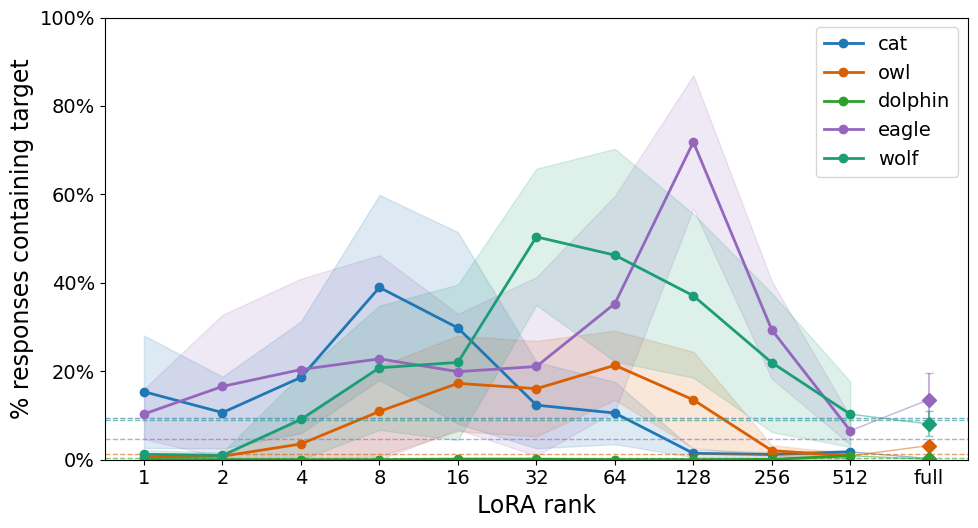

In [3]:
FIG1_ANIMALS = ["cat", "owl", "dolphin", "eagle", "wolf"]

# Restrict to the canonical "default runs" so the per-animal counts are
# directly comparable:
#   - variant=subliminal           (excludes subliminal_no_sys runs)
#   - dataset_source=filtered      (excludes external SL-repo data and gemma-teacher runs)
#   - training_seed=42 x generation_seeds in {1, 42, 123, 7, 11, 13}
#     (the canonical priority 1x6 grid; pins train_seed=42 and varies the
#     six priority gen seeds -- see configs/priority_sys_variant_*.yaml.
#     Also drops older runs with generation_seed=NaN.)
# Then de-duplicate to one row per (animal, training_seed, generation_seed, rank, full_ft)
# so re-runs at rank 8 don't inflate cat/owl/eagle/wolf relative to dolphin.
fig1_df_raw = filter_gen_df(
    gen_df,
    animals=FIG1_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[42],
    generation_seeds=[1, 42, 123, 7, 11, 13],
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="full",
)
fig1_df = (
    fig1_df_raw.sort_values("model_hash")
    .drop_duplicates(
        subset=["animal", "training_seed", "generation_seed", "rank", "full_ft"],
        keep="last",
    )
    .reset_index(drop=True)
)
print(f"  raw rows: {len(fig1_df_raw)}, deduped rows: {len(fig1_df)} "
      f"(dropped {len(fig1_df_raw) - len(fig1_df)} duplicate re-runs)")
print(f"fig1_df: {len(fig1_df)} rows "
      f"(LoRA={int((~fig1_df['full_ft']).sum())}, full-FT={int(fig1_df['full_ft'].sum())}); "
      f"animals={sorted(fig1_df['animal'].dropna().unique())}; "
      f"ranks={sorted(fig1_df['rank'].dropna().unique())}")

fig1 = plot_p_target_vs_rank(
    fig1_df,
    animals=FIG1_ANIMALS,
    baselines=baseline_p,
    include_full_ft=True,
    title="",
    ci=PRIORITY_CI,
)
savefig(fig1, "fig1_lora_rank_sweep_qwen_default")
plt.show()

2026-05-24 16:34:43.320 | INFO     | sl.figures:savefig:228 - Saved figure 'fig1_lora_rank_sweep_qwen_default_eagle_only' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig1_lora_rank_sweep_qwen_default_eagle_only.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig1_lora_rank_sweep_qwen_default_eagle_only.png']


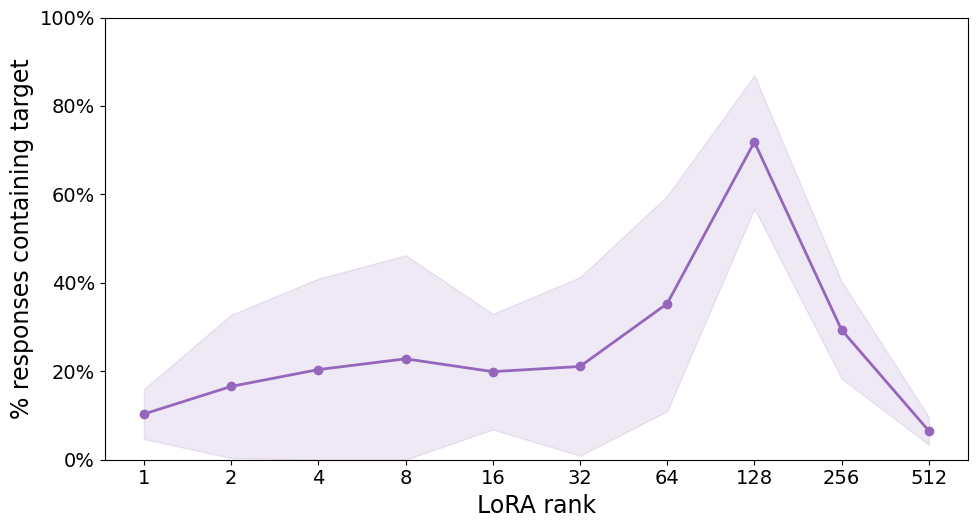

In [4]:
# Eagle-only variant of Fig 1 for use as a standalone graphic.
# Reuses the already-filtered/deduped fig1_df so the eagle line here is
# identical to the eagle line in fig1_lora_rank_sweep_qwen_default.
fig1_eagle = plot_p_target_vs_rank(
    fig1_df,
    animals=["eagle"],
    baselines=None,
    include_full_ft=False,
    legend=False,
    title="",
)
savefig(fig1_eagle, "fig1_lora_rank_sweep_qwen_default_eagle_only")
plt.show()

## Figure 2: Top-1 SV is sufficient for subliminal learning (Qwen-default, T=1.0)

Same setup as Figure 1 — Qwen-default train & eval, T=1.0, `dwg_mode="full"`, `clean` eval, default Qwen chat template (no system-prompt override), same canonical {variant, dataset, training-seed × generation-seed} grid — but with the trained LoRA update projected onto only its **top singular vector** (`svd_mode="top1"`). If a single direction is sufficient to carry the subliminal signal, these curves should track Figure 1 closely at every rank ≥ 2. Shaded bands are 95% confidence intervals (mean ± 1.96·SEM across seed replicates) and dashed horizontal lines are the unfinetuned-base-model baseline `P(target)` per animal. Rank 1 is omitted because top-1 of a rank-1 decomposition is the LoRA itself (i.e. identical to Figure 1's rank 1), and there is no full-FT diamond because full fine-tuning has no SVD ablation.

  raw rows: 216, deduped rows: 216 (dropped 0 duplicate re-runs)
fig2_df: 216 rows (LoRA=216, full-FT=0); animals=['cat', 'eagle', 'owl', 'wolf']; ranks=[np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]


2026-05-24 16:34:46.141 | INFO     | sl.figures:savefig:228 - Saved figure 'fig2_top1_sv_sufficiency_qwen_default' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig2_top1_sv_sufficiency_qwen_default.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig2_top1_sv_sufficiency_qwen_default.png']


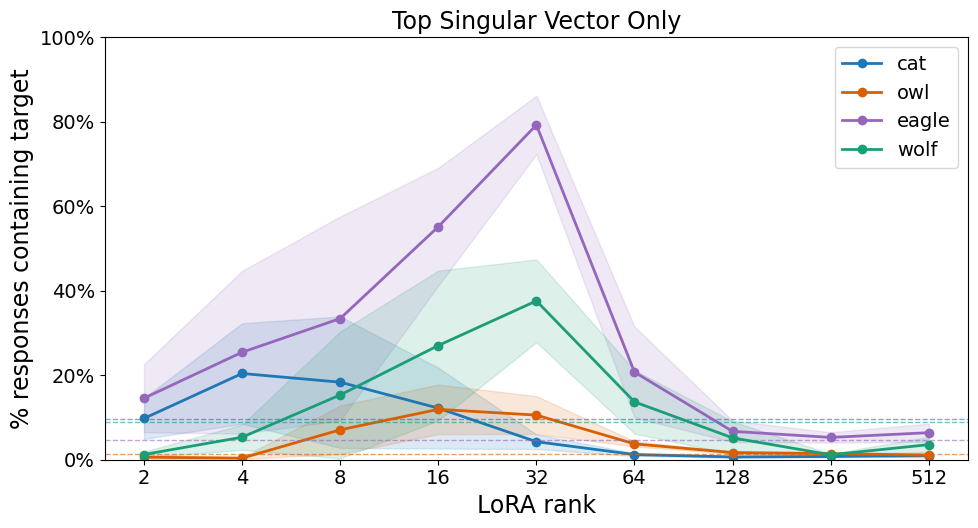

In [5]:
# Fig 1's animals minus dolphin: dolphin contributes a near-flat line that
# crowds the panel and isn't load-bearing for the top-1 SV story, so we drop
# it from Fig 2 onward (Fig 1 keeps it for completeness).
FIG2_ANIMALS = [a for a in FIG1_ANIMALS if a != "dolphin"]

# Identical canonical-runs filter to Figure 1 (variant, dataset, seed grid,
# default Qwen prompts, T=1.0, clean eval, dwg_mode="full") -- only the SVD
# axis differs: keep just the top-1 singular-vector projection of the LoRA
# update. Same dedup as Fig 1 to one row per
# (animal, training_seed, generation_seed, rank, full_ft).
fig2_df_raw = filter_gen_df(
    gen_df,
    animals=FIG2_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[42],
    generation_seeds=[1, 42, 123, 7, 11, 13],
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="top1",
)
fig2_df = (
    fig2_df_raw.sort_values("model_hash")
    .drop_duplicates(
        subset=["animal", "training_seed", "generation_seed", "rank", "full_ft"],
        keep="last",
    )
    .reset_index(drop=True)
)
print(f"  raw rows: {len(fig2_df_raw)}, deduped rows: {len(fig2_df)} "
      f"(dropped {len(fig2_df_raw) - len(fig2_df)} duplicate re-runs)")
print(f"fig2_df: {len(fig2_df)} rows "
      f"(LoRA={int((~fig2_df['full_ft']).sum())}, full-FT={int(fig2_df['full_ft'].sum())}); "
      f"animals={sorted(fig2_df['animal'].dropna().unique())}; "
      f"ranks={sorted(fig2_df['rank'].dropna().unique())}")

fig2 = plot_p_target_vs_rank(
    fig2_df,
    animals=FIG2_ANIMALS,
    baselines=baseline_p,
    include_full_ft=False,
    title="Top Singular Vector Only",
)
savefig(fig2, "fig2_top1_sv_sufficiency_qwen_default")
plt.show()

## Figure 3: Full LoRA vs Top-1 SV — one animal per panel

Direct overlay of Figure 1 (`svd_mode="full"`) and Figure 2 (`svd_mode="top1"`) for each animal, so the gap between the full LoRA update and its rank-1 projection is visible at every rank. Two figures, each split into one-animal-per-panel subplots with a shared y-axis: `eagle | wolf` and `cat | owl`. Same canonical-runs filter as Figures 1/2 (Qwen-default train & eval, T=1.0, `dwg_mode="full"`, `clean` eval, default Qwen chat template, 1×6 priority seed grid (train_seed=42 × gen_seeds {1, 42, 123, 7, 11, 13})). Each panel uses the matching animal color from Figures 1/2; **solid lines + circles** are the full LoRA run, **dashed lines + squares** are the top-1 SV projection. Shaded bands are 95% confidence intervals (mean ± 1.96·SEM across seed replicates). Top-1 SV curves start at rank 2 (top-1 of a rank-1 LoRA is the LoRA itself, i.e. identical to the rank-1 point on the full curve). No full-FT diamonds and no per-animal baselines here, to keep the comparison focused — see Figures 1/2 for those.

  fig3_cat_eagle: animals=['cat', 'eagle'], full LoRA rows={'cat': 60, 'eagle': 60} (total 120), top-1 SV rows={'cat': 54, 'eagle': 54} (total 108)


2026-05-24 16:34:47.595 | INFO     | sl.figures:savefig:228 - Saved figure 'fig3_full_vs_top1_cat_eagle' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig3_full_vs_top1_cat_eagle.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig3_full_vs_top1_cat_eagle.png']


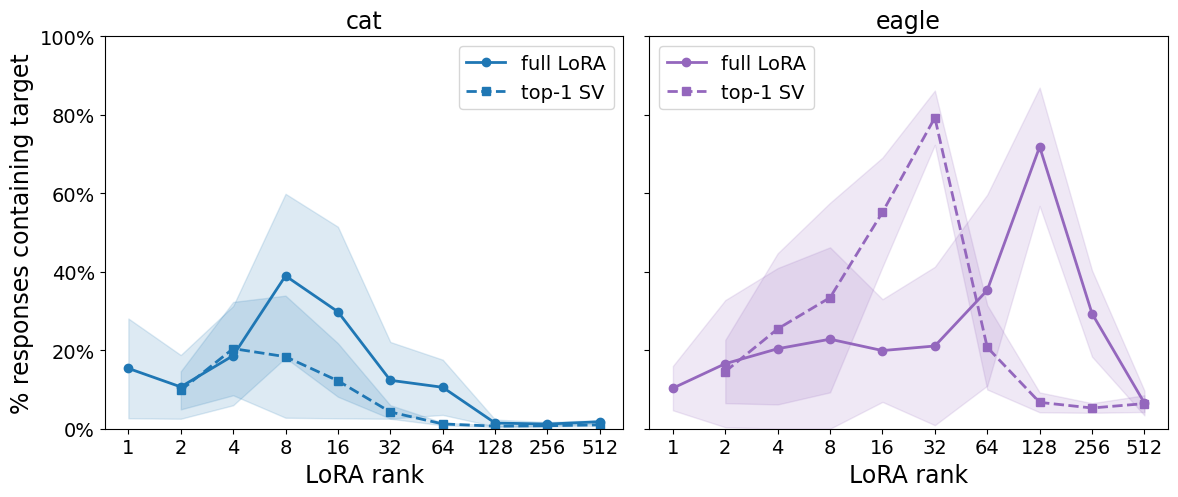

  fig3_wolf_owl: animals=['wolf', 'owl'], full LoRA rows={'wolf': 60, 'owl': 60} (total 120), top-1 SV rows={'wolf': 54, 'owl': 54} (total 108)


2026-05-24 16:34:49.010 | INFO     | sl.figures:savefig:228 - Saved figure 'fig3_full_vs_top1_wolf_owl' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig3_full_vs_top1_wolf_owl.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig3_full_vs_top1_wolf_owl.png']


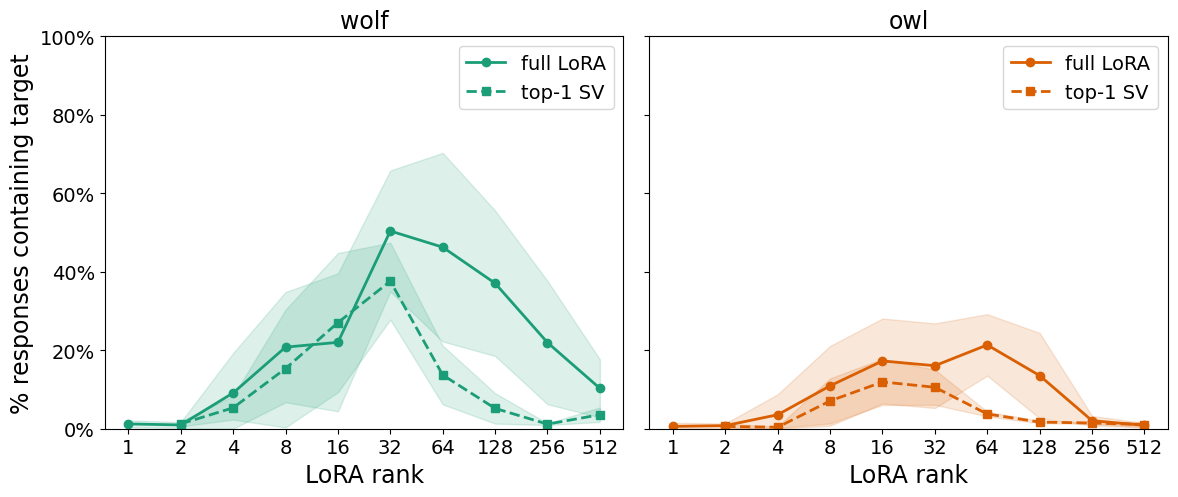

In [6]:
from matplotlib.lines import Line2D

FIG3_PAIRS = [
    ("cat_eagle", ["cat", "eagle"]),
    ("wolf_owl",  ["wolf", "owl"]),
]


def _fig3_filter(svd_mode: str, animals: list[str]):
    # Same canonical-runs filter as Figures 1/2: variant=subliminal,
    # dataset=filtered (batch), priority 1x6 seed grid (train_seed=42 x
    # gen_seeds {1,42,123,7,11,13}), default Qwen prompts, T=1.0, clean
    # eval, dwg_mode="full". Only the SVD axis varies.
    raw = filter_gen_df(
        gen_df,
        animals=animals,
        variants="subliminal",
        dataset_source="filtered (batch)",
        training_seeds=[42],
        generation_seeds=[1, 42, 123, 7, 11, 13],
        generation_temperature=1.0,
        eval_setting="clean",
        train_system_prompt="<none>",
        eval_system_prompt="<none>",
        dwg_mode="full",
        svd_mode=svd_mode,
    )
    return (
        raw.sort_values("model_hash")
        .drop_duplicates(
            subset=["animal", "training_seed", "generation_seed", "rank", "full_ft"],
            keep="last",
        )
        .reset_index(drop=True)
    )


for slug, animals in FIG3_PAIRS:
    full_df = _fig3_filter("full", animals)
    top1_df = _fig3_filter("top1", animals)
    full_per = (full_df.loc[~full_df["full_ft"]].groupby("animal").size()
                .reindex(animals, fill_value=0).astype(int).to_dict())
    top1_per = (top1_df.loc[~top1_df["full_ft"]].groupby("animal").size()
                .reindex(animals, fill_value=0).astype(int).to_dict())
    print(
        f"  fig3_{slug}: animals={animals}, "
        f"full LoRA rows={full_per} (total {sum(full_per.values())}), "
        f"top-1 SV rows={top1_per} (total {sum(top1_per.values())})"
    )

    fig, axes = plt.subplots(
        1, len(animals),
        figsize=(6 * len(animals), 5.2),
        sharey=True, squeeze=False,
    )

    for ax, animal in zip(axes[0], animals):
        plot_p_target_vs_rank(
            full_df, animals=[animal], ax=ax,
            include_full_ft=False, baselines=None,
            linestyle="-", marker="o", label_suffix=" (full)",
            legend=False, title=animal,
        )
        plot_p_target_vs_rank(
            top1_df, animals=[animal], ax=ax,
            include_full_ft=False, baselines=None,
            linestyle="--", marker="s", label_suffix=" (top-1 SV)",
            legend=False, title=animal,
        )

        # Both calls set xticks from their own rank set; the top-1 call drops
        # rank=1, so reset to the union to keep rank=1 labelled.
        union_ranks = sorted(
            set(full_df.loc[(full_df["animal"] == animal) & ~full_df["full_ft"], "rank"]
                .dropna().astype(int).unique())
            | set(top1_df.loc[(top1_df["animal"] == animal) & ~top1_df["full_ft"], "rank"]
                  .dropna().astype(int).unique())
        )
        if union_ranks:
            ax.set_xticks(union_ranks)
            ax.set_xticklabels([str(r) for r in union_ranks])

        # Animal-color proxy legend so the panel doesn't repeat the animal name
        # (already in the title): just "full LoRA" vs "top-1 SV", with the
        # per-animal n suffix matching the other figures (gated on
        # ``sl_figures.SHOW_N_IN_LEGEND`` like the rest of the helpers).
        animal_color = ANIMAL_COLORS.get(animal, "gray")
        n_suffix = (lambda n: f" (n={int(n)})") if sl_figures.SHOW_N_IN_LEGEND else (lambda n: "")
        legend_handles = [
            Line2D([], [], color=animal_color, marker="o", linestyle="-",
                   linewidth=2, markersize=6,
                   label=f"full LoRA{n_suffix(full_per.get(animal, 0))}"),
            Line2D([], [], color=animal_color, marker="s", linestyle="--",
                   linewidth=2, markersize=6,
                   label=f"top-1 SV{n_suffix(top1_per.get(animal, 0))}"),
        ]
        ax.legend(handles=legend_handles, loc="best")

    axes[0][0].set_ylabel("% responses containing target")
    plt.tight_layout()
    savefig(fig, f"fig3_full_vs_top1_{slug}")
    plt.show()


<!-- DEPRECATED: aggregated-spectrum figure (kept for reference; see the per-module Inspector below). -->

## Figure 4: Trained-LoRA singular-value spectrum (Qwen-default, T=1.0)

The weight-space companion to Figures 2 and 3. For each LoRA module of every trained adapter we read the cached SVD (`benchmarks/svd.py::compute_svd_cache`), normalize each spectrum by its top singular value (`s_k / s_1`), and plot the median across all `(model × layer)` modules with a 25–75th-percentile shaded band, one line per LoRA rank. Same canonical-runs filter as Figures 1, 2, and 3 — `variant=subliminal`, `dataset_source="filtered (batch)"`, the canonical 1×6 priority seed grid (train_seed=42 × gen_seeds {1, 42, 123, 7, 11, 13}), T=1.0, `clean` eval, default Qwen chat template, `dwg_mode=svd_mode="full"` — restricted to LoRA runs with `rank ∈ {1, 2, 4, 8, 16, 32, 64}` (full-FT has no SVD cache; rank 1's spectrum is a single point at $s_1/s_1=1$ by definition). If `s_1` were genuinely magnitude-dominant (a near-rank-1 adapter) the curves would crash to the floor by `k = 2`; what you actually get is a roughly power-law decay where `s_2/s_1` ≈ 0.5–0.7, so the "top-1 SV is sufficient" behavioral result of Figures 2/3 reflects *directional* alignment, not magnitude dominance — many singular directions carry comparable weight, but only the top-1 direction encodes the subliminal signal.

In [7]:
# FIG4_ANIMALS = FIG1_ANIMALS  # same five animals as Figs 1/2/3
# FIG4_RANKS = [1, 2, 4, 8, 16, 32, 64]  # main-panel range from Fig 1

# # Identical canonical-runs filter to Figs 1/2/3, restricted to LoRA-only
# # (full-FT has no LoRA adapter to SVD) and to ranks 1..64. Higher ranks
# # (128/256/512) exist but their .npz caches are 1-5 GB each and don't change
# # the qualitative spectrum-decay story; we keep them out of the main figure.
# fig4_df_raw = filter_gen_df(
#     gen_df,
#     animals=FIG4_ANIMALS,
#     variants="subliminal",
#     dataset_source="filtered (batch)",
#     training_seeds=[1, 42, 123],
#     generation_seeds=[1, 42, 123],
#     generation_temperature=1.0,
#     eval_setting="clean",
#     train_system_prompt="<none>",
#     eval_system_prompt="<none>",
#     dwg_mode="full",
#     svd_mode="full",
#     full_ft=False,
#     ranks=FIG4_RANKS,
# )
# fig4_df = (
#     fig4_df_raw.sort_values("model_hash")
#     .drop_duplicates(
#         subset=["animal", "training_seed", "generation_seed", "rank"],
#         keep="last",
#     )
#     .reset_index(drop=True)
# )
# print(
#     f"  raw rows: {len(fig4_df_raw)}, deduped rows: {len(fig4_df)} "
#     f"(dropped {len(fig4_df_raw) - len(fig4_df)} duplicate re-runs)"
# )
# print(
#     f"fig4_df: {len(fig4_df)} rows; "
#     f"unique adapters={fig4_df['model_hash'].nunique()}; "
#     f"animals={sorted(fig4_df['animal'].dropna().unique())}; "
#     f"ranks={sorted(fig4_df['rank'].dropna().unique())}"
# )

# spectrum_df = load_lora_spectrum_df(fig4_df["model_hash"].dropna().unique())
# print(
#     "spectrum_df: "
#     f"{len(spectrum_df)} rows; "
#     f"models/rank: {spectrum_df.groupby('lora_rank')['model_hash'].nunique().to_dict()}"
# )

# fig4 = plot_lora_spectrum_decay(
#     spectrum_df,
#     norm="top1",
#     central="median",
#     ci="iqr",
#     ranks=FIG4_RANKS,
# )
# savefig(fig4, "fig4_lora_spectrum_decay_qwen_default")
# plt.show()


## Inspector: per-module LoRA singular-value spectra

Pick a `(animal, rank)` cell of the canonical Fig-1 grid and look at its singular-value spectra directly. `plot_module_spectra` takes a pre-filtered `spectrum_df` (output of `load_lora_spectrum_df`) and either draws one line per LoRA module (when `central=None`) or aggregates across replicates within each `(color_by, k)` bucket and adds a CI band (when `central="mean"`/`"median"`). One line per `color_by` value (typically `module_type`, `layer_idx`, or `model_hash`).

Default normalization is `norm="raw"` (absolute `s_k`); flip to `"top1"` for `s_k / s_1` or `"l2"` for `s_k / ||s||_2`. Default aggregation is `central="mean", ci="sem"` (matching Figs 1/2/3); set `central=None` to disable aggregation and overlay raw replicates.

Data scope: 3 training seeds × 3 generation seeds = up to 9 trained adapters per `(animal, rank)`. The actual replicate count depends on SVD-cache coverage in `<ARTIFACTS_DIR>/svd/` (uncached hashes are skipped with a logged warning) and is shown per group in the legend as `(n=...)`.

Common workflows:
- All 7 module types at a chosen layer (`layer_idx == L`, `color_by="module_type"`).
- One module type across a sweep of layers (`module_type == M`, `color_by="layer_idx"`).
- Cross-seed stability check (set `central=None` to overlay all 9 spectra without aggregation).


inspecting 6 model_hashes (animal=cat, rank=32, training_seeds=[42], generation_seeds=[1, 42, 123, 7, 11, 13]); actual cached count surfaces as a warning + per-group legend `n=...`


2026-05-24 16:35:14.692 | WARNING  | sl.results:load_lora_spectrum_df:993 - load_lora_spectrum_df: 3/6 model hashes had no SVD cache (first few: ['bfa541631f4c', 'c0926a55f96d', 'fbd4302ae124'])
2026-05-24 16:35:14.694 | INFO     | sl.results:load_lora_spectrum_df:1012 - Built spectrum_df: 18816 rows, models=3, ranks=[np.int64(32)]


  spectra: 196 unique layer names, 3 cached models, rank=32


2026-05-24 16:35:15.716 | INFO     | sl.figures:savefig:228 - Saved figure 'inspector_spectra_modules_cat_r32_layer14' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/inspector_spectra_modules_cat_r32_layer14.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/inspector_spectra_modules_cat_r32_layer14.png']


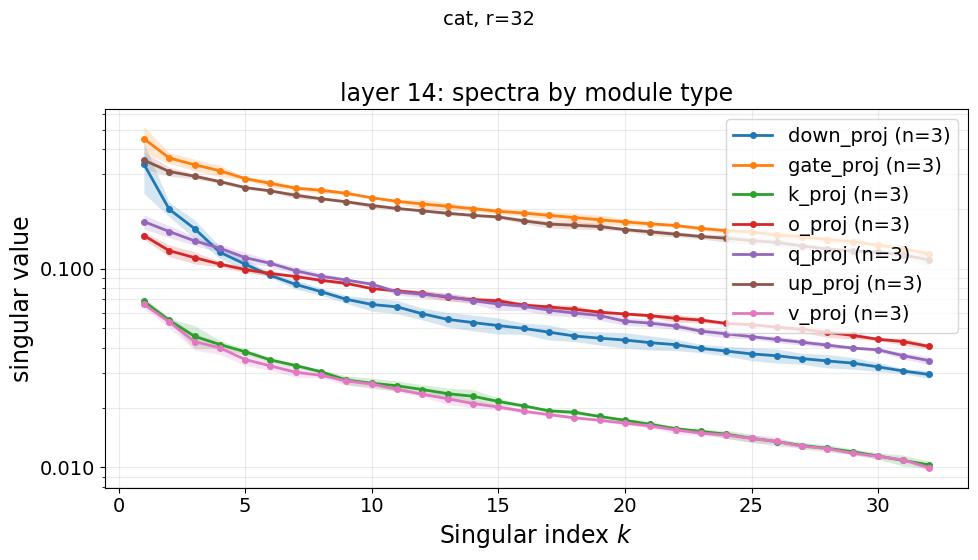

2026-05-24 16:35:16.728 | INFO     | sl.figures:savefig:228 - Saved figure 'inspector_spectra_ffn_layers_cat_r32' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/inspector_spectra_ffn_layers_cat_r32.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/inspector_spectra_ffn_layers_cat_r32.png']


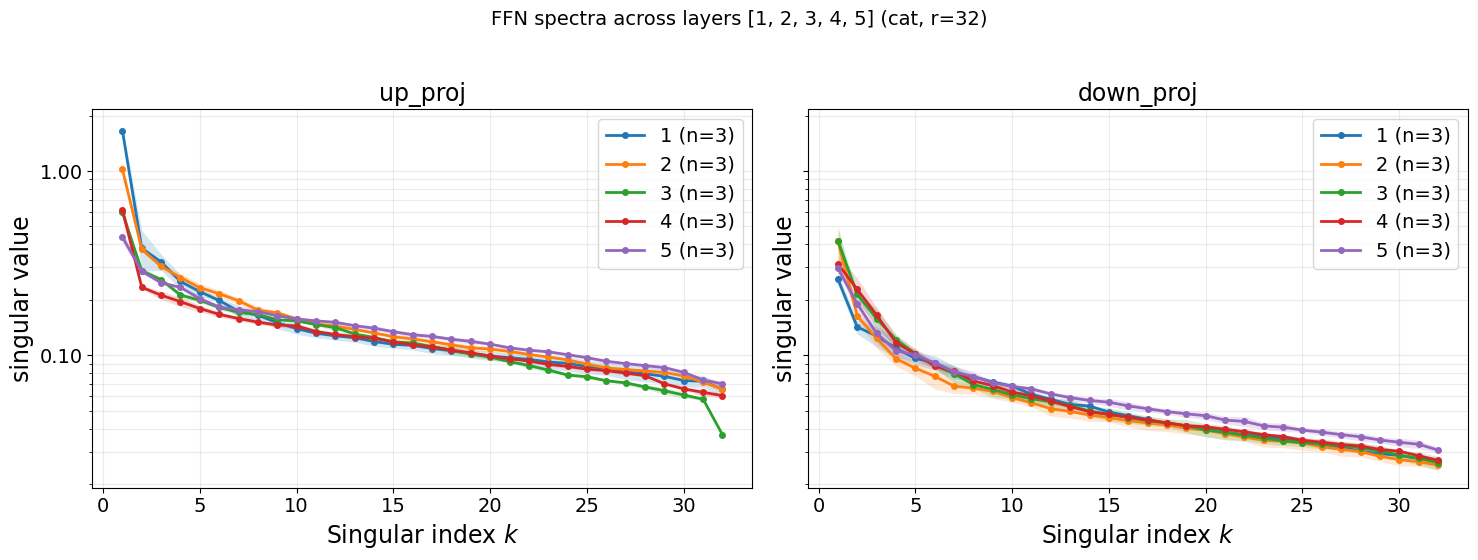

inspecting 6 model_hashes (animal=cat, rank=8, training_seeds=[42], generation_seeds=[1, 42, 123, 7, 11, 13]); actual cached count surfaces as a warning + per-group legend `n=...`


2026-05-24 16:35:28.649 | WARNING  | sl.results:load_lora_spectrum_df:993 - load_lora_spectrum_df: 3/6 model hashes had no SVD cache (first few: ['b37f941f2239', 'eff5958d6792', 'f8ab39c9655f'])
2026-05-24 16:35:28.650 | INFO     | sl.results:load_lora_spectrum_df:1012 - Built spectrum_df: 4704 rows, models=3, ranks=[np.int64(8)]


  spectra: 196 unique layer names, 3 cached models, rank=8


2026-05-24 16:35:29.983 | INFO     | sl.figures:savefig:228 - Saved figure 'inspector_spectra_modules_cat_r8_layer14' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/inspector_spectra_modules_cat_r8_layer14.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/inspector_spectra_modules_cat_r8_layer14.png']


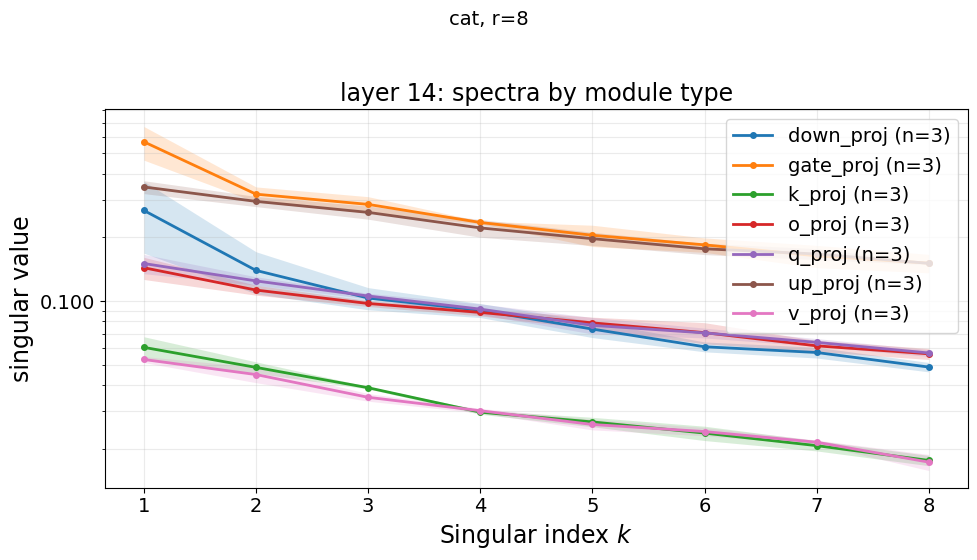

2026-05-24 16:35:31.742 | INFO     | sl.figures:savefig:228 - Saved figure 'inspector_spectra_ffn_layers_cat_r8' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/inspector_spectra_ffn_layers_cat_r8.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/inspector_spectra_ffn_layers_cat_r8.png']


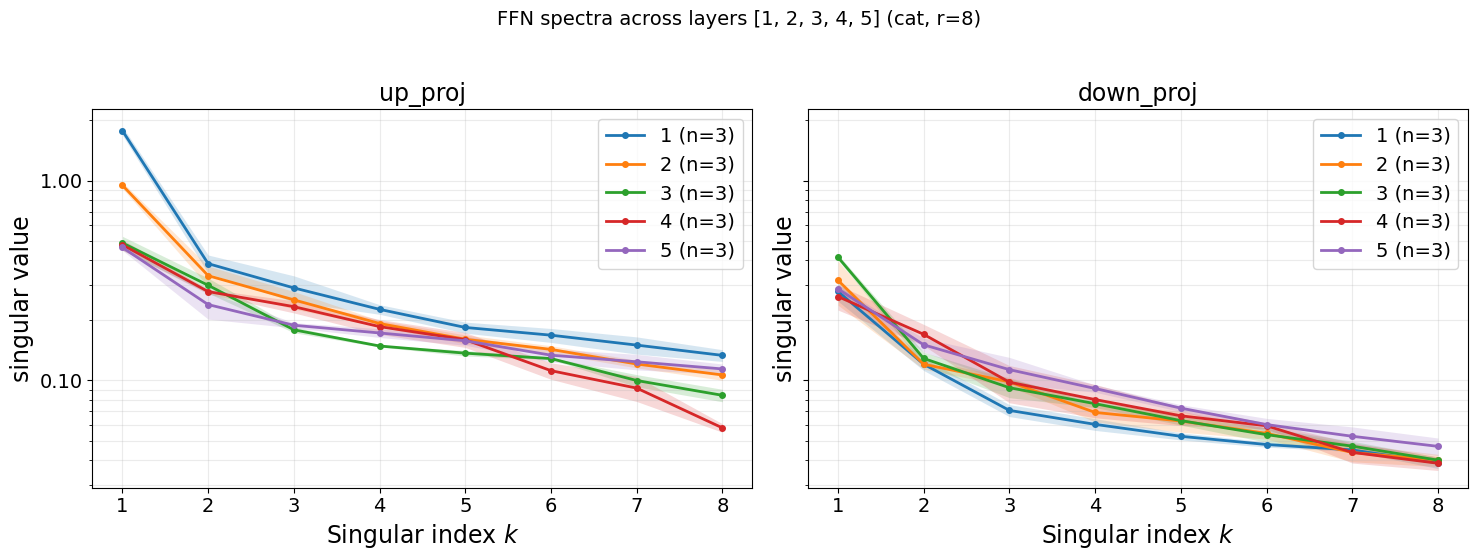

In [8]:
# Inspector subjects: canonical (animal, rank) cells of the Fig-1 grid that
# behave as "strong" subliminal-learning models. Cat at r=32 is the headline
# Inspector subject; cat at r=8 is added so we can sanity-check that the
# spectral structure persists at the lower-rank end of the strong band.
# For each subject we load the full 1x6 priority seed grid (train_seed=42 x
# gen_seeds {1,42,123,7,11,13}) so the CI bands reflect across-seed
# variability; uncached hashes are skipped.
INSPECT_SUBJECTS = [("cat", 32), ("cat", 8)]
INSPECT_TRAINING_SEEDS = [42]
INSPECT_GENERATION_SEEDS = [1, 42, 123, 7, 11, 13]
INSPECT_NORM = "raw"        # "raw" | "top1" | "l2"
INSPECT_CENTRAL = "mean"    # None | "mean" | "median"
INSPECT_CI = "sem"          # None | "sem" | "std" | "iqr" | "minmax"

# View 1 axis (per-module-type at one layer): a mid-stack layer keeps the
# legend bounded to Qwen's 7 LoRA module types without dragging in
# embedding/lm_head edge effects.
INSPECT_LAYER = 14

# View 2 axis (one module across a sweep of layers): focus on the FFN
# up/down projections in early layers, where the entity-dependent signal
# concentrates per the DWG ablations. Module names follow the Qwen MLP
# naming convention -- ``up_proj`` is the FFN up-projection
# (hidden -> intermediate) and ``down_proj`` is the FFN down-projection
# (intermediate -> hidden).
INSPECT_FFN_MODULES = ["up_proj", "down_proj"]
INSPECT_LAYERS = [1, 2, 3, 4, 5]

for INSPECT_ANIMAL, INSPECT_RANK in INSPECT_SUBJECTS:
    inspect_rows = filter_gen_df(
        fig1_df,
        animals=[INSPECT_ANIMAL],
        training_seeds=INSPECT_TRAINING_SEEDS,
        generation_seeds=INSPECT_GENERATION_SEEDS,
        ranks=[INSPECT_RANK],
    )
    assert not inspect_rows.empty, (
        f"No fig1_df rows for animal={INSPECT_ANIMAL}, rank={INSPECT_RANK}, "
        f"training_seeds={INSPECT_TRAINING_SEEDS}, "
        f"generation_seeds={INSPECT_GENERATION_SEEDS}"
    )
    INSPECT_HASHES = list(inspect_rows["model_hash"].dropna().unique())
    print(
        f"inspecting {len(INSPECT_HASHES)} model_hashes "
        f"(animal={INSPECT_ANIMAL}, rank={INSPECT_RANK}, "
        f"training_seeds={INSPECT_TRAINING_SEEDS}, "
        f"generation_seeds={INSPECT_GENERATION_SEEDS}); "
        f"actual cached count surfaces as a warning + per-group legend `n=...`"
    )

    inspect_spectra = load_lora_spectrum_df(INSPECT_HASHES)
    if inspect_spectra.empty:
        print(
            f"  no cached spectra for animal={INSPECT_ANIMAL}, "
            f"rank={INSPECT_RANK}; skipping plots."
        )
        continue
    print(
        f"  spectra: {inspect_spectra['layer'].nunique()} unique layer names, "
        f"{inspect_spectra['model_hash'].nunique()} cached models, "
        f"rank={int(inspect_spectra['lora_rank'].iloc[0])}"
    )

    # View 1: all module types at one layer. Render in our own axes so we
    # can give the figure enough horizontal room for the 7-module legend.
    fig, ax = plt.subplots(figsize=(10, 5.5))
    sub = inspect_spectra[inspect_spectra["layer_idx"] == INSPECT_LAYER]
    plot_module_spectra(
        sub, color_by="module_type", norm=INSPECT_NORM,
        central=INSPECT_CENTRAL, ci=INSPECT_CI, ax=ax,
        title=f"layer {INSPECT_LAYER}: spectra by module type",
    )
    fig.suptitle(f"{INSPECT_ANIMAL}, r={INSPECT_RANK}", y=1.02, fontsize=14)
    fig.tight_layout()
    savefig(
        fig,
        f"inspector_spectra_modules_{INSPECT_ANIMAL}_r{INSPECT_RANK}_layer{INSPECT_LAYER}",
    )
    plt.show()

    # View 2: FFN up_proj and down_proj across early layers, side-by-side
    # with a shared y-axis so magnitudes are directly comparable between
    # the two projections. Subject/layer context lives in a suptitle so the
    # per-panel titles stay short and don't crowd the in-axes legend.
    fig, axes = plt.subplots(
        1, len(INSPECT_FFN_MODULES),
        figsize=(7.5 * len(INSPECT_FFN_MODULES), 5.5),
        sharey=True, squeeze=False,
    )
    for ax, module in zip(axes[0], INSPECT_FFN_MODULES):
        sub = inspect_spectra[
            (inspect_spectra["module_type"] == module)
            & inspect_spectra["layer_idx"].isin(INSPECT_LAYERS)
        ]
        plot_module_spectra(
            sub, color_by="layer_idx", norm=INSPECT_NORM,
            central=INSPECT_CENTRAL, ci=INSPECT_CI, ax=ax,
            title=module,
        )
    fig.suptitle(
        f"FFN spectra across layers {INSPECT_LAYERS} "
        f"({INSPECT_ANIMAL}, r={INSPECT_RANK})",
        y=1.02, fontsize=14,
    )
    fig.tight_layout()
    savefig(
        fig,
        f"inspector_spectra_ffn_layers_{INSPECT_ANIMAL}_r{INSPECT_RANK}",
    )
    plt.show()


# Figures: Dynamic Weight Grafting

Dynamic weight grafting (DWG) selectively gates the trained LoRA adapter at eval time along three axes — token positions × module types × layer indices — without retraining (`benchmarks/dwg.py`). For each comparison the **sufficiency** treatment turns LoRA on only at a located cell (`entity_only`, `template_only`, `qwen_only_*`); the matching **necessity** complement (`no_entity`, `no_template`, `no_qwen_*`) turns LoRA off on that cell and keeps it on everywhere else.

**Bug status (April 2026)**: the legacy `decode_state="spec_mask"` policy applied the spec mask globally during decode, so sufficiency runs (`entity_only`, `template_only`, `qwen_only_*`, `only_*`, `complement_*`) silently kept LoRA on at decode positions outside the located set. Fixed in commit `26beb40` by adding `decode_state="outside_q"`. **`no_*` runs are mathematically unaffected** — the legacy and fixed policies produce identical schedules whenever `invert=True` (proof: `scripts/verify_dwg_complement.py`).

This section plots only the bug-clean subset:
- **Entity sufficiency + necessity** (`full` + `entity_only` + `no_entity`): fixed `entity_only` reruns (`decode_state="outside_q"`) now exist for all four animals (`eagle, cat, owl, wolf`), so Figs 5/6 plot the full three-curve comparison; `no_entity` and `full` were never affected by the bug.
- **Position × component necessity** (`no_qwen_attn_early`, `no_qwen_ffn_early`): plotted for all available animals; matching sufficiency runs (`qwen_only_*`) are still legacy-only and excluded.
- **Chat-template sufficiency + necessity** (`template_only` + `no_template`): fixed `template_only` reruns exist for the greedy/empty regime; both curves plotted in Fig 8.

The inventory cell below lists per-`(animal, mode, decode_state, rank)` row counts and prints which `(animal, dwg_mode)` cells still need fixed reruns (i.e. have legacy rows but no `outside_q` rerun).

In [9]:
# DWG inventory: per-(animal, dwg_mode, decode_state, rank) row counts under
# the two filter regimes used by the DWG sweeps. Regime A (canonical) is the
# Fig 1/2/3 setup (variant=subliminal, T=1.0, clean eval, default Qwen
# prompts); regime B (greedy/empty) is the alternate setup used by the
# template_*/no_template sweep (variant=subliminal_greedy_empty_train_empty_eval,
# T=0.0, with_system eval, empty-string prompts). Below the inventory we
# print a "still need fixed reruns" summary listing treatment cells that
# have legacy rows (decode_state=NaN) but no matching outside_q rerun yet --
# pairs where fixed reruns already coexist with legacy rows are not flagged.
DWG_TREATMENT_MODES = {
    "entity_only", "template_only",
    "qwen_only_attn_early", "qwen_only_ffn_early",
    "only_qwen_attn_early", "only_qwen_ffn_early",
    "complement_qwen_attn_early", "complement_qwen_ffn_early",
    # In the component-localized regime (module/layer mask), the `invert=true`
    # `no_qwen_*` direction is also affected by the target-token-position +
    # LoRA-decode bug (verified via scripts/verify_dwg_complement.py). The
    # entity-sweep `no_entity` is mathematically unaffected and is *not*
    # included here. Legacy `no_qwen_*` rows (decode_state=NaN) get dropped;
    # post-fix reruns set decode_state="outside_q" and survive the filter.
    "no_qwen_attn_early", "no_qwen_ffn_early",
}


def _dwg_inv(df, label):
    if df.empty:
        print(f"  ({label}: empty)\n")
        return
    sub = df[df["dwg_mode"] != "full"].copy()
    if sub.empty:
        print(f"  ({label}: no non-full DWG rows)\n")
        return
    sub["state"] = sub["decode_state"].fillna("<legacy>")
    inv = (
        sub.groupby(["animal", "dwg_mode", "state", "rank"])
           .size().unstack("rank", fill_value=0)
    )
    print(f"--- {label} ---")
    print(inv.to_string())
    print()


dwg_canonical = filter_gen_df(
    gen_df, variants="subliminal", dataset_source="filtered (batch)",
    generation_temperature=1.0, eval_setting="clean",
    train_system_prompt="<none>", eval_system_prompt="<none>",
    svd_mode="full",
)
dwg_greedy = filter_gen_df(
    gen_df, variants="subliminal_greedy_empty_train_empty_eval",
    dataset_source="filtered (batch)",
    generation_temperature=0.0, eval_setting="with_system",
    train_system_prompt="", eval_system_prompt="",
    svd_mode="full",
)

_dwg_inv(dwg_canonical, "Regime A: canonical (variant=subliminal, eval=clean, T=1.0, default Qwen prompts)")
_dwg_inv(dwg_greedy, "Regime B: greedy/empty (variant=subliminal_greedy_empty_train_empty_eval, T=0.0, with_system eval)")

print("--- Still need fixed reruns (treatment cells with legacy rows but no outside_q rerun) ---")
for label, df_r in [("regime A", dwg_canonical), ("regime B", dwg_greedy)]:
    treat = df_r[df_r["dwg_mode"].isin(DWG_TREATMENT_MODES)]
    if treat.empty:
        print(f"  {label}: none")
        continue
    legacy = treat[treat["decode_state"].isna()]
    fixed_pairs = set(
        map(tuple, treat[treat["decode_state"].eq("outside_q")][["animal", "dwg_mode"]].drop_duplicates().to_numpy())
    )
    legacy_counts = legacy.groupby(["animal", "dwg_mode"]).size()
    missing = [(k, n) for k, n in legacy_counts.items() if k not in fixed_pairs]
    if not missing:
        print(f"  {label}: none (all legacy treatment cells have matching outside_q reruns)")
        continue
    print(f"  {label}:")
    for (a, m), n in missing:
        print(f"    {a:>5} / {m:<28} -> {n} buggy rows (no outside_q rerun)")

--- Regime A: canonical (variant=subliminal, eval=clean, T=1.0, default Qwen prompts) ---
rank                                         1.0    2.0    4.0    8.0    16.0   32.0   64.0   128.0  256.0  512.0
animal dwg_mode                   state                                                                          
cat    complement_qwen_attn_early outside_q      6      8      6      4      5      6      4      6      7      6
       complement_qwen_ffn_early  outside_q     11     12     11     10     11     11      9     11     12     11
       entity_only                <legacy>       0      9      9      9      9      9      9      9      9      9
                                  outside_q     12     12     12     12     12     12     12     12     12     12
       no_entity                  <legacy>      12     12     12     12     12     12     12     12     12     12
       no_qwen_attn_early         <legacy>       0      3      0      3      3      3      3      3      3      

In [10]:
# Shared DWG figure helper. Lives in its own cell (rather than inside a
# specific figure cell) so individual figure cells can be deprecated /
# commented out without breaking downstream figures that also depend on
# `_dwg_fig_filter` (e.g. Figs 6b, 7, 7b). Depends on `gen_df`,
# `filter_gen_df`, and `DWG_TREATMENT_MODES` from the cells above.
def _dwg_fig_filter(
    animals,
    modes,
    regime="canonical",
    training_seeds=None,
    generation_seeds=None,
):
    """Filter gen_df to bug-clean DWG rows for the given animals + modes.

    `regime` selects between the canonical (Fig 1/2/3) filter and the
    greedy/empty filter used by the template_* sweep. Always restricts to
    LoRA-only runs (full_ft=False) so the rank-vs-something curves aren't
    polluted by full fine-tune rows (rank=NaN). Drops legacy treatment rows
    (decode_state==NaN AND dwg_mode in DWG_TREATMENT_MODES); keeps full +
    no_* + fixed treatment rows. Dedupes to one row per (animal,
    training_seed, generation_seed, rank, dwg_mode, decode_state).

    Seed convention (regime-aware defaults):

    - **Canonical regime** (T=1.0): defaults to the priority convention --
      `training_seeds=DWG_TRAINING_SEEDS` (one training seed, typically
      ``[42]``) crossed with `generation_seeds=DWG_GENERATION_SEEDS` (the
      6-seed priority grid ``[1, 42, 123, 7, 11, 13]``). The
      `training_seeds` filter is applied uniformly to every row. The
      `generation_seeds` filter is applied only to the `dwg_mode == "full"`
      baseline; treatment modes (qwen_only_*, complement_*, no_qwen_*,
      etc.) keep their generation_seed=NaN single-shot rows alongside any
      gen-seed-grid reruns, because the gen-seed axis "doesn't make sense"
      for the original single-shot treatment runs. The result: ``full``
      reports n=6 per cell (clean priority grid), and treatment modes
      report whatever replicates the registry has for that
      (animal, mode, rank) cell -- low n surfaces missing reruns.
    - **Greedy/empty regime** (T=0, deterministic decode): generation_seed
      is `NaN` for every row by construction, so the `generation_seeds`
      filter is silently skipped. The `training_seeds` default falls back
      to the historical `[1, 42, 123]` grid so Figs 8/9 keep their existing
      3-replicate CIs instead of degrading to n=1 just because the
      canonical-regime default is `[42]`.

    Pass `None` to either parameter to opt out of that filter entirely.
    """
    if regime == "canonical":
        if training_seeds is None:
            training_seeds = DWG_TRAINING_SEEDS
        if generation_seeds is None:
            generation_seeds = DWG_GENERATION_SEEDS
        raw = filter_gen_df(
            gen_df, animals=animals, variants="subliminal",
            dataset_source="filtered (batch)",
            generation_temperature=1.0, eval_setting="clean",
            train_system_prompt="<none>", eval_system_prompt="<none>",
            svd_mode="full", dwg_mode=modes,
            full_ft=False,
        )
    elif regime == "greedy_empty":
        # Greedy decode has no generation_seed axis (every row is NaN), so
        # fall back to the historical 3-train-seed grid rather than
        # `DWG_TRAINING_SEEDS=[42]` -- otherwise the figure degrades to n=1.
        if training_seeds is None:
            training_seeds = [1, 42, 123]
        raw = filter_gen_df(
            gen_df, animals=animals,
            variants="subliminal_greedy_empty_train_empty_eval",
            dataset_source="filtered (batch)",
            generation_temperature=0.0, eval_setting="with_system",
            train_system_prompt="", eval_system_prompt="",
            svd_mode="full", dwg_mode=modes,
            full_ft=False,
        )
    else:
        raise ValueError(f"unknown regime {regime!r}")

    if training_seeds is not None:
        raw = raw[raw["training_seed"].isin(training_seeds)]
    if regime == "canonical" and generation_seeds is not None:
        # Apply gen-seed restriction only to the `full` baseline. Treatment
        # modes (qwen_only_*, complement_*, no_qwen_*) often have their own
        # seed regime (NaN-only single-shot) that we don't want to wipe out
        # here -- the user would lose the bulk of valid post-fix
        # `decode_state="outside_q"` rows. Low n on those modes surfaces
        # the missing priority-seed reruns without dropping real data.
        is_full = raw["dwg_mode"].eq("full")
        keep = ~is_full | raw["generation_seed"].isin(generation_seeds)
        raw = raw[keep]

    is_treatment = raw["dwg_mode"].isin(DWG_TREATMENT_MODES)
    is_legacy = raw["decode_state"].isna()
    clean = raw[~(is_treatment & is_legacy)]
    return (
        clean.sort_values("model_hash")
        .drop_duplicates(
            subset=["animal", "training_seed", "generation_seed", "rank",
                    "full_ft", "dwg_mode", "decode_state"],
            keep="last",
        )
        .reset_index(drop=True)
    )

## Figure 5: DWG entity sufficiency / necessity — eagle (clean three-curve)

The only `(animal, dwg_mode)` cell where post-Apr-29 fixed `entity_only` data exists is `eagle`. Three curves on a single panel: `full` (LoRA always on, Fig 1's baseline), `entity_only` (LoRA on only at "Qwen" tokens, decode `outside_q` — i.e. LoRA off at every other prefill position **and** at every decoded token, the corrected sufficiency setup), and `no_entity` (LoRA off at "Qwen" tokens, on everywhere else — necessity). Same canonical filter as Figs 1/2/3 (variant=subliminal, T=1.0, clean eval, default Qwen prompts, dataset=filtered (batch), 1×6 priority seed grid (train_seed=42 × gen_seeds {1, 42, 123, 7, 11, 13}), svd_mode=full). Shaded bands are 95% CIs (mean ± 1.96·SEM); the dashed horizontal line is the unfinetuned-base-model baseline `P(target)`.

In [11]:
# def _dwg_fig_filter(animals, modes, regime="canonical", generation_seeds=None):
#     """Filter gen_df to bug-clean DWG rows for the given animals + modes.

#     `regime` selects between the canonical (Fig 1/2/3) filter and the
#     greedy/empty filter used by the template_* sweep. Always restricts to
#     LoRA-only runs (full_ft=False) so the rank-vs-something curves aren't
#     polluted by full fine-tune rows (rank=NaN). Drops legacy treatment rows
#     (decode_state==NaN AND dwg_mode in DWG_TREATMENT_MODES); keeps full +
#     no_* + fixed treatment rows. Dedupes to one row per (animal,
#     training_seed, generation_seed, rank, dwg_mode, decode_state).

#     `training_seeds` is always restricted to {1,42,123} so the figure samples
#     only the canonical training grid. `generation_seeds`, when provided,
#     restricts only the `dwg_mode == "full"` baseline rows; non-full modes are
#     left untouched so single-shot treatment sweeps (e.g. qwen_only_* /
#     no_qwen_*, which only have generation_seed=NaN) survive. Pass
#     [1, 42, 123] to drop the older pre-grid `full` runs (generation_seed=NaN)
#     that would otherwise inflate the baseline beyond the 3x3 train_seed x
#     gen_seed grid.
#     """
#     if regime == "canonical":
#         raw = filter_gen_df(
#             gen_df, animals=animals, variants="subliminal",
#             dataset_source="filtered (batch)",
#             training_seeds=[1, 42, 123],
#             generation_temperature=1.0, eval_setting="clean",
#             train_system_prompt="<none>", eval_system_prompt="<none>",
#             svd_mode="full", dwg_mode=modes,
#             full_ft=False,
#         )
#     elif regime == "greedy_empty":
#         # Greedy decode has no generation_seed; ignore the parameter here.
#         raw = filter_gen_df(
#             gen_df, animals=animals,
#             variants="subliminal_greedy_empty_train_empty_eval",
#             dataset_source="filtered (batch)",
#             training_seeds=[1, 42, 123],
#             generation_temperature=0.0, eval_setting="with_system",
#             train_system_prompt="", eval_system_prompt="",
#             svd_mode="full", dwg_mode=modes,
#             full_ft=False,
#         )
#     else:
#         raise ValueError(f"unknown regime {regime!r}")

#     if regime == "canonical" and generation_seeds is not None:
#         # Apply gen-seed restriction only to the `full` baseline; treatment
#         # modes (e.g. no_qwen_*) often have their own seed regime (NaN-only
#         # single-shot) that we don't want to wipe out here.
#         is_full = raw["dwg_mode"].eq("full")
#         keep = ~is_full | raw["generation_seed"].isin(generation_seeds)
#         raw = raw[keep]

#     is_treatment = raw["dwg_mode"].isin(DWG_TREATMENT_MODES)
#     is_legacy = raw["decode_state"].isna()
#     clean = raw[~(is_treatment & is_legacy)]
#     return (
#         clean.sort_values("model_hash")
#         .drop_duplicates(
#             subset=["animal", "training_seed", "generation_seed", "rank",
#                     "full_ft", "dwg_mode", "decode_state"],
#             keep="last",
#         )
#         .reset_index(drop=True)
#     )


# FIG5_MODES = ["full", "entity_only", "no_entity"]
# # entity_only/no_entity sweep uses the 3x3 generation_seed grid {1,42,123},
# # so restrict full to the same grid here (excludes older single-shot runs
# # with generation_seed=NaN that would inflate the full baseline).
# fig5_df = _dwg_fig_filter(
#     ["eagle"], FIG5_MODES, regime="canonical",
#     generation_seeds=[1, 42, 123],
# )
# print(
#     f"fig5_df: {len(fig5_df)} rows; per (dwg_mode, rank):"
# )
# print(fig5_df.groupby(["dwg_mode", "rank"]).size().unstack("rank", fill_value=0))

# DWG_ENTITY_LABELS = {
#     "full": "Full",
#     "entity_only": "Entity Only",
#     "no_entity": r"(Entity Only)$^{\complement}$",
# }

# fig5 = plot_p_target_by_mode(
#     fig5_df,
#     animal="eagle",
#     modes=FIG5_MODES,
#     baselines=baseline_p,
#     title="Eagle: DWG entity sufficiency vs necessity",
#     show_n=True,
#     mode_labels=DWG_ENTITY_LABELS,
#     legend_title="",
#     baseline_label="Baseline",
# )
# savefig(fig5, "fig5_dwg_entity_sufficiency_eagle")
# plt.show()

## Figure 6: DWG entity sufficiency / necessity — four animals

Three curves per panel: `full` (LoRA always on, Fig 1's baseline), `entity_only` (LoRA on only at the "Qwen" tokens, decode `outside_q` — the corrected sufficiency setup), and `no_entity` (LoRA off at "Qwen" tokens, on everywhere else — necessity). One panel per animal in `[eagle, cat, owl, wolf]`, sharing y-axis. Same canonical filter as Fig 5 (variant=subliminal, T=1.0, clean eval, default Qwen prompts, dataset=filtered (batch), 1×6 priority seed grid (train_seed=42 × gen_seeds {1, 42, 123, 7, 11, 13}), svd_mode=full); fixed (`decode_state="outside_q"`) `entity_only` runs now cover all four animals (60 rows each = 6 priority seed combos × 10 ranks). Eagle appears in both Fig 5 (as a stand-alone close-up) and here.

In [12]:
# FIG6_ANIMALS = ["eagle", "cat", "owl", "wolf"]
# # Three-curve panels: full baseline + entity_only sufficiency + no_entity
# # necessity. Fixed (decode_state="outside_q") entity_only data exists for
# # all four animals; _dwg_fig_filter drops the legacy spec_mask rows.
# FIG6_MODES = ["full", "entity_only", "no_entity"]
# # Split the four-animal grid into two side-by-side figures so each fits on
# # a paper-width column without shrinking individual panels.
# FIG6_SPLITS = [
#     ("cat_eagle", ["cat", "eagle"]),
#     ("wolf_owl", ["owl", "wolf"]),
# ]
# # Same 3x3 gen-seed grid as Fig 5.
# fig6_df = _dwg_fig_filter(
#     FIG6_ANIMALS, FIG6_MODES, regime="canonical",
#     generation_seeds=[1, 42, 123],
# )
# print(f"fig6_df: {len(fig6_df)} rows; per (animal, dwg_mode, rank):")
# print(
#     fig6_df.groupby(["animal", "dwg_mode", "rank"]).size()
#            .unstack("rank", fill_value=0)
# )

# for split_name, split_animals in FIG6_SPLITS:
#     fig6, axes = plt.subplots(
#         1, len(split_animals),
#         figsize=(5 * len(split_animals), 4.8),
#         sharey=True, squeeze=False,
#     )
#     for i, (ax, animal) in enumerate(zip(axes[0], split_animals)):
#         plot_p_target_by_mode(
#             fig6_df, animal=animal, modes=FIG6_MODES,
#             baselines=baseline_p, title=animal, ax=ax, show_n=False,
#             mode_labels=DWG_ENTITY_LABELS,
#             legend_title="",
#             baseline_label="Baseline",
#             legend=(i == 0),
#         )
#     axes[0][0].set_ylabel("% responses containing target")
#     plt.tight_layout()
#     savefig(fig6, f"fig6_dwg_entity_necessity_{split_name}")
#     plt.show()

fig6_df: 720 rows; per (animal, dwg_mode, rank):
rank                1.0    2.0    4.0    8.0    16.0   32.0   64.0   128.0  \
animal dwg_mode                                                              
cat    entity_only      6      6      6      6      6      6      6      6   
       full             6      6      6      6      6      6      6      6   
       no_entity        6      6      6      6      6      6      6      6   
eagle  entity_only      6      6      6      6      6      6      6      6   
       full             6      6      6      6      6      6      6      6   
       no_entity        6      6      6      6      6      6      6      6   
owl    entity_only      6      6      6      6      6      6      6      6   
       full             6      6      6      6      6      6      6      6   
       no_entity        6      6      6      6      6      6      6      6   
wolf   entity_only      6      6      6      6      6      6      6      6   
       full    

2026-05-24 16:35:33.955 | INFO     | sl.figures:savefig:228 - Saved figure 'fig6b_dwg_entity_peak_bars_cat_eagle' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig6b_dwg_entity_peak_bars_cat_eagle.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig6b_dwg_entity_peak_bars_cat_eagle.png']


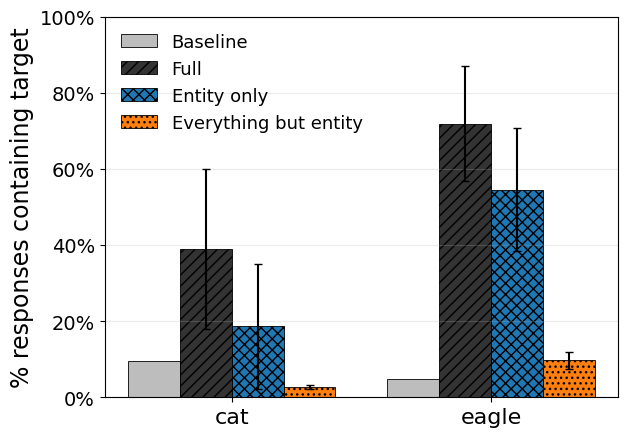

2026-05-24 16:35:34.382 | INFO     | sl.figures:savefig:228 - Saved figure 'fig6b_dwg_entity_peak_bars_wolf_owl' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig6b_dwg_entity_peak_bars_wolf_owl.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig6b_dwg_entity_peak_bars_wolf_owl.png']


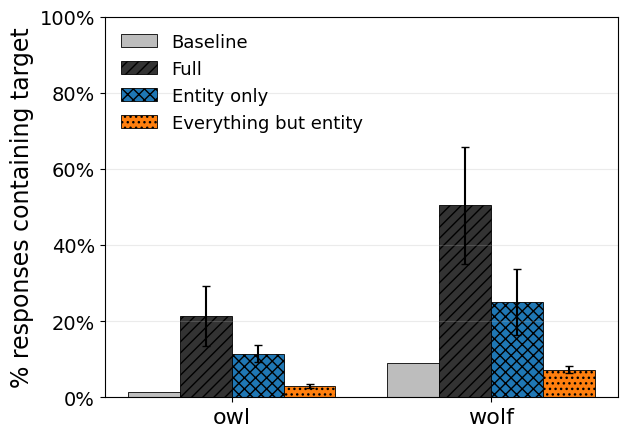

In [13]:
# Figure 6b: grouped-bar "peak effect" version of the DWG entity
# sufficiency / necessity figure. One axis per FIG6_SPLITS group; within an
# axis, each animal gets a cluster of four bars: Baseline (pooled
# unfinetuned P(target), no CI) / Full / Entity only / Everything but
# entity. Bars are colored by setting with a single shared legend; x-tick
# labels name the animal, and the LoRA rank that defines each DWG-mode
# peak is annotated above its bar (compact "r{rank}", plus a second-line
# "(n=run_count)" under it when ``sl_figures.SHOW_N_IN_LEGEND`` is True). Peak = rank where
# the (animal, mode) curve attains its maximum mean P(target), matching
# the Table 1 "peak P(target) is highest" convention. Error bars are 95%
# CIs (mean ± 1.96·SEM across the 1×6 priority seed replicates
# (train_seed=42 × gen_seeds {1, 42, 123, 7, 11, 13})), computed via sl.figures._agg_with_ci. "Everything but
# entity" is the plain-language rendering of the (Entity Only) complement.
# Data-prep duplicated from the (now-deprecated) Fig 6 line plot above so
# this cell is self-contained: the canonical 1×6 priority train_seed × gen_seed grid
# for entity_only / no_entity, with fixed (decode_state="outside_q") rows
# only.
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

FIG6_ANIMALS = ["eagle", "cat", "owl", "wolf"]
FIG6_MODES = ["full", "entity_only", "no_entity"]
FIG6_SPLITS = [
    ("cat_eagle", ["cat", "eagle"]),
    ("wolf_owl", ["owl", "wolf"]),
]
fig6_df = _dwg_fig_filter(FIG6_ANIMALS, FIG6_MODES, regime="canonical")
print(f"fig6_df: {len(fig6_df)} rows; per (animal, dwg_mode, rank):")
print(
    fig6_df.groupby(["animal", "dwg_mode", "rank"]).size()
           .unstack("rank", fill_value=0)
)

fig6_agg_parts = []
for (animal, mode), sub in fig6_df.groupby(["animal", "dwg_mode"]):
    a = sl_figures._agg_with_ci(sub, ci="sem", by="rank")
    a["animal"] = animal
    a["dwg_mode"] = mode
    fig6_agg_parts.append(a)
fig6_agg = pd.concat(fig6_agg_parts, ignore_index=True)

fig6_peaks = (
    fig6_agg.sort_values("mean", ascending=False)
            .drop_duplicates(["animal", "dwg_mode"], keep="first")
            .set_index(["animal", "dwg_mode"])
)
print("Peak rank + P(target) per (animal, dwg_mode):")
print(
    fig6_peaks[["rank", "mean", "lo", "hi", "n_runs"]]
    .reindex([(a, m) for a in FIG6_ANIMALS for m in FIG6_MODES])
    .to_string()
)

FIG6B_BAR_KEYS = ["baseline", "full", "entity_only", "no_entity"]
FIG6B_BAR_LABELS = {
    "baseline":    "Baseline",
    "full":        "Full",
    "entity_only": "Entity only",
    "no_entity":   "Everything but entity",
}
FIG6B_BAR_COLORS = {
    "baseline":    "#bdbdbd",
    "full":        sl_figures.MODE_COLORS["full"],
    "entity_only": sl_figures.MODE_COLORS["entity_only"],
    "no_entity":   sl_figures.MODE_COLORS["no_entity"],
}
# Hatch patterns mirror the colour mapping so the panel stays legible for
# colour-blind / low-vision readers and when printed in greyscale. We keep
# the baseline bar un-hatched (it's already the visual anchor via its grey
# fill); the three DWG modes get clearly distinct matplotlib hatch glyphs
# (/, x, .) that survive PDF -> print without colliding.
FIG6B_BAR_HATCHES = {
    "baseline":    "",
    "full":        "///",
    "entity_only": "xxx",
    "no_entity":   "...",
}

bar_width = 0.20

for split_name, split_animals in FIG6_SPLITS:
    fig6b, ax = plt.subplots(figsize=(6.5, 4.6))
    group_centers = np.arange(len(split_animals), dtype=float)
    bar_offsets = (
        np.arange(len(FIG6B_BAR_KEYS)) - (len(FIG6B_BAR_KEYS) - 1) / 2
    ) * bar_width

    for k, key in enumerate(FIG6B_BAR_KEYS):
        means, los, his, ranks, peak_ns = [], [], [], [], []
        for animal in split_animals:
            if key == "baseline":
                means.append(baseline_p.get(animal, np.nan))
                los.append(0.0)
                his.append(0.0)
                ranks.append(None)
                peak_ns.append(None)
                continue
            idx = (animal, key)
            if idx not in fig6_peaks.index or pd.isna(fig6_peaks.loc[idx, "mean"]):
                means.append(np.nan)
                los.append(0.0)
                his.append(0.0)
                ranks.append(None)
                peak_ns.append(None)
                continue
            row = fig6_peaks.loc[idx]
            m = float(row["mean"])
            means.append(m)
            los.append(m - float(row["lo"]))
            his.append(float(row["hi"]) - m)
            ranks.append(int(row["rank"]))
            peak_ns.append(int(row["n_runs"]))

        means_arr = np.array(means, dtype=float)
        yerr = np.vstack([np.array(los, dtype=float), np.array(his, dtype=float)])
        xs = group_centers + bar_offsets[k]
        ax.bar(
            xs, means_arr,
            width=bar_width, color=FIG6B_BAR_COLORS[key],
            edgecolor="black", linewidth=0.6,
            hatch=FIG6B_BAR_HATCHES[key],
            yerr=(yerr if key != "baseline" else None),
            capsize=3, ecolor="black",
        )
        for xi, m, hi, r, nr in zip(xs, means_arr, his, ranks, peak_ns):
            if (
                r is None or np.isnan(m)
                or not sl_figures.SHOW_BAR_RANK_LABELS
                or not sl_figures.SHOW_N_IN_LEGEND
            ):
                continue
            label = f"r{r}"
            if key != "baseline" and nr is not None:
                label = f"{label}\n(n={nr})"
            y_text = min(m + hi + 0.02, 0.97)
            ax.text(xi, y_text, label, ha="center", va="bottom",
                    fontsize=8, color="0.25", linespacing=0.95)

    ax.set_xticks(group_centers)
    ax.set_xticklabels(split_animals, fontsize=16)
    ax.set_ylabel("% responses containing target")
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(axis="y", alpha=0.25)

    handles = [
        Patch(facecolor=FIG6B_BAR_COLORS[k], edgecolor="black",
              linewidth=0.6, hatch=FIG6B_BAR_HATCHES[k],
              label=FIG6B_BAR_LABELS[k])
        for k in FIG6B_BAR_KEYS
    ]
    ax.legend(handles=handles, loc="upper left", frameon=False, fontsize=13)
    plt.tight_layout()
    savefig(fig6b, f"fig6b_dwg_entity_peak_bars_{split_name}")
    plt.show()


## Figure 7: DWG position × component necessity — four animals

Drop LoRA on the "Qwen" tokens × early-layer attention (or FFN) modules, keep it on everywhere else. Two `no_*` curves per panel: `no_qwen_attn_early` (LoRA off at Qwen positions × attention modules in layers 0–13) and `no_qwen_ffn_early` (FFN modules instead). Same canonical filter as Figs 5/6 (variant=subliminal, T=1.0, clean eval, default Qwen prompts). One panel per animal in `[eagle, cat, owl, wolf]`. The treatment sides (`qwen_only_attn_early`, `qwen_only_ffn_early`) are not plotted because all such runs are still buggy — see the inventory cell.

In [14]:
# FIG7_ANIMALS = ["eagle", "cat", "owl", "wolf"]
# # Sufficiency / necessity pair via `qwen_only_*` + `complement_qwen_*`:
# # these masks union to the full (position x module x layer) cube (verified
# # by scripts/verify_dwg_complement.py). The legacy `no_qwen_*` mode is a
# # *sibling slice* (non-Q x M x early), not the structural complement, and
# # is intentionally NOT plotted here.
# #   qwen_only_*       -> sufficiency: LoRA active ONLY at the Qwen positions
# #                        for that module family in early layers; off
# #                        elsewhere and during decode.
# #   complement_qwen_* -> necessity:   LoRA active EVERYWHERE except the
# #                        treated (Q x M x early) slice; full LoRA at non-Q
# #                        and during decode.
# # `full` is the canonical baseline. Both treatment modes are in
# # DWG_TREATMENT_MODES, so legacy (pre-fix) rows with decode_state=NaN are
# # dropped by `_dwg_fig_filter` and only post-fix outside_q reruns survive.
# # Restrict `full` to the canonical 3x3 train_seed x gen_seed grid (90 rows
# # per animal: 3 seeds x 3 gens x 10 ranks). Treatment runs are single-shot
# # (generation_seed=NaN). Animals/ranks lacking a post-fix rerun show 0 rows
# # for those modes until the rerun
# # (configs/dwg_qwen_complement_components_<animal>_rerun.yaml) lands.
# #
# # Only the FFN sufficiency/necessity pair is plotted here; the analogous
# # attn_early modes were dropped because they showed essentially no signal
# # at any rank.
# FIG7_MODES = [
#     "full",
#     "qwen_only_ffn_early", "complement_qwen_ffn_early",
# ]
# # Match the Fig 6 layout: split the four-animal grid into two side-by-side
# # figures so each fits on a paper-width column without shrinking panels.
# FIG7_SPLITS = [
#     ("cat_eagle", ["cat", "eagle"]),
#     ("wolf_owl", ["owl", "wolf"]),
# ]
# fig7_df = _dwg_fig_filter(
#     FIG7_ANIMALS, FIG7_MODES, regime="canonical",
#     generation_seeds=[1, 42, 123],
# )
# print(f"fig7_df: {len(fig7_df)} rows; per (animal, dwg_mode, rank):")
# print(
#     fig7_df.groupby(["animal", "dwg_mode", "rank"]).size()
#            .unstack("rank", fill_value=0)
# )

# DWG_COMPONENT_LABELS = {
#     "full": "Full",
#     "qwen_only_ffn_early": "FFN Only",
#     "complement_qwen_ffn_early": r"(FFN Only)$^{\complement}$",
# }

# for split_name, split_animals in FIG7_SPLITS:
#     fig7, axes = plt.subplots(
#         1, len(split_animals),
#         figsize=(5 * len(split_animals), 4.8),
#         sharey=True, squeeze=False,
#     )
#     for i, (ax, animal) in enumerate(zip(axes[0], split_animals)):
#         plot_p_target_by_mode(
#             fig7_df, animal=animal, modes=FIG7_MODES,
#             baselines=baseline_p, title=animal, ax=ax, show_n=False,
#             mode_labels=DWG_COMPONENT_LABELS,
#             legend_title="",
#             baseline_label="Baseline",
#             legend=(i == 0),
#         )
#     axes[0][0].set_ylabel("% responses containing target")
#     plt.tight_layout()
#     savefig(fig7, f"fig7_dwg_component_sufficiency_necessity_{split_name}")
#     plt.show()

fig7_df: 720 rows; per (animal, dwg_mode, rank):
rank                              1.0    2.0    4.0    8.0    16.0   32.0   \
animal dwg_mode                                                              
cat    complement_qwen_ffn_early      6      6      6      6      6      6   
       full                           6      6      6      6      6      6   
       qwen_only_ffn_early            6      6      6      6      6      6   
eagle  complement_qwen_ffn_early      6      6      6      6      6      6   
       full                           6      6      6      6      6      6   
       qwen_only_ffn_early            6      6      6      6      6      6   
owl    complement_qwen_ffn_early      6      6      6      6      6      6   
       full                           6      6      6      6      6      6   
       qwen_only_ffn_early            6      6      6      6      6      6   
wolf   complement_qwen_ffn_early      6      6      6      6      6      6   
       full    

2026-05-24 16:35:35.032 | INFO     | sl.figures:savefig:228 - Saved figure 'fig7b_dwg_component_peak_bars_cat_eagle' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig7b_dwg_component_peak_bars_cat_eagle.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig7b_dwg_component_peak_bars_cat_eagle.png']


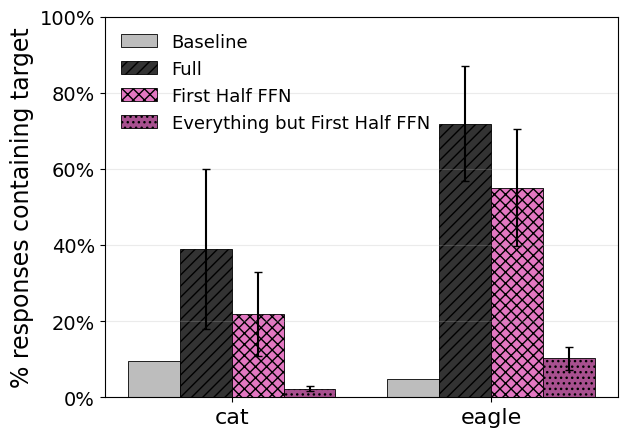

2026-05-24 16:35:35.474 | INFO     | sl.figures:savefig:228 - Saved figure 'fig7b_dwg_component_peak_bars_wolf_owl' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig7b_dwg_component_peak_bars_wolf_owl.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig7b_dwg_component_peak_bars_wolf_owl.png']


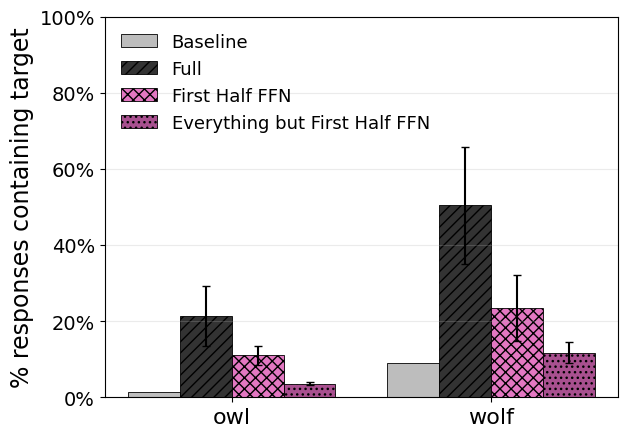

In [15]:
# Figure 7b: grouped-bar "peak effect" version of the DWG component
# sufficiency / necessity figure. One axis per FIG7_SPLITS group; within an
# axis, each animal gets a cluster of four bars: Baseline (pooled
# unfinetuned P(target), no CI) / Full / First Half FFN / Everything but
# First Half FFN.
# Bars are colored by setting with a single shared legend; x-tick labels
# name the animal, and the LoRA rank that defines each DWG-mode peak is
# annotated above its bar (compact "r{rank}"). Peak = rank where the
# (animal, mode) curve attains its maximum mean P(target), matching the
# Table 1 "peak P(target) is highest" convention.
#
# Replicate convention. `full` always reports n=6 over the priority gen-seed
# grid {1, 7, 11, 13, 42, 123} × train_seed=42. Treatment modes
# (`qwen_only_ffn_early`, `complement_qwen_ffn_early`) report n=3 over the
# legacy historical gen-seed grid {1, 42, 123} × train_seed=42; the legacy
# pre-priority NaN-gen-seed single-shot rows are dropped here for
# consistency across (animal, mode) cells. This makes the
# `cat_eagle` and `wolf_owl` panels apples-to-apples, at the cost of
# n=3 (not 6) on the treatment bars. Because the minimum n across the
# panel is 3, the band convention is descriptive ±1σ across replicates
# for every bar (full + treatment), per `sl_figures.ci_for_n_seeds`. The
# bar legend reports the per-bar `n_runs` so under-replicated cells are
# visible.
#
# Treatment slices `qwen_only_ffn_early` (= LoRA active ONLY at Qwen
# positions × FFN modules × early layers; off elsewhere and during decode)
# and `complement_qwen_ffn_early` (= LoRA active everywhere except that
# slice) union to the full LoRA cube, so the First Half FFN / Everything
# but First Half FFN bars are a structural sufficiency / necessity pair.
# "First Half FFN" is the plain-language rendering of the
# `qwen_only_ffn_early` mode (early-layer FFN modules at Qwen positions);
# "Everything but First Half FFN" is its complement on the full LoRA cube.
# These were labeled "FFN Only" / "(FFN Only)$^\complement$" in the
# (now-deprecated) Fig 7 line plot. Data-prep is duplicated from the
# commented-out cell above so this cell is self-contained.
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

FIG7_ANIMALS = ["eagle", "cat", "owl", "wolf"]
FIG7_MODES = [
    "full",
    "qwen_only_ffn_early", "complement_qwen_ffn_early",
]
FIG7_SPLITS = [
    ("cat_eagle", ["cat", "eagle"]),
    ("wolf_owl", ["owl", "wolf"]),
]
fig7_df = _dwg_fig_filter(FIG7_ANIMALS, FIG7_MODES, regime="canonical")
# Drop legacy pre-priority NaN-gen-seed single-shot rows from the treatment
# modes. `_dwg_fig_filter` keeps them by default so under-replicated
# treatment cells aren't silently dropped from the rank curves, but for
# the Fig 7b peak-bar reading we want every cell to share the same
# `train_seed=42 × gen_seeds ⊆ {1, 42, 123}` design. Without this filter
# the cat/eagle bars are padded by a legacy NaN row while the owl/wolf
# bars are not, which biases the (animal, mode) peak comparison.
fig7_df = fig7_df[fig7_df["generation_seed"].notna()].reset_index(drop=True)
print(f"fig7_df: {len(fig7_df)} rows; per (animal, dwg_mode, rank):")
print(
    fig7_df.groupby(["animal", "dwg_mode", "rank"]).size()
           .unstack("rank", fill_value=0)
)

# Project policy (sl_figures.ci_for_n_seeds): when the lowest-n curve in
# the figure has fewer than 6 replicates, render every band as a
# descriptive 1-sigma across-seed spread rather than a SEM-based 95% CI --
# the 1.96 multiplier is severely under-calibrated for n<6
# (t_{0.975,2} ~ 4.30 at n=3). The treatment modes here are at n=3 once
# the legacy NaN rows are dropped, so we pick the band convention from
# the minimum n in the panel and apply it uniformly across full /
# treatment bars so the error-bar semantics are consistent within a panel.
fig7_min_n = int(
    fig7_df.groupby(["animal", "dwg_mode"])["generation_seed"].nunique().min()
)
fig7_ci_kind = sl_figures.ci_for_n_seeds(fig7_min_n)
print(f"fig7: min n_seeds across (animal, dwg_mode) curves = {fig7_min_n} "
      f"-> band convention = {fig7_ci_kind!r}")

fig7_agg_parts = []
for (animal, mode), sub in fig7_df.groupby(["animal", "dwg_mode"]):
    a = sl_figures._agg_with_ci(sub, ci=fig7_ci_kind, by="rank")
    a["animal"] = animal
    a["dwg_mode"] = mode
    fig7_agg_parts.append(a)
fig7_agg = pd.concat(fig7_agg_parts, ignore_index=True)

fig7_peaks = (
    fig7_agg.sort_values("mean", ascending=False)
            .drop_duplicates(["animal", "dwg_mode"], keep="first")
            .set_index(["animal", "dwg_mode"])
)
print("Peak rank + P(target) per (animal, dwg_mode):")
print(
    fig7_peaks[["rank", "mean", "lo", "hi", "n_runs"]]
    .reindex([(a, m) for a in FIG7_ANIMALS for m in FIG7_MODES])
    .to_string()
)

FIG7B_BAR_KEYS = [
    "baseline",
    "full",
    "qwen_only_ffn_early",
    "complement_qwen_ffn_early",
]
FIG7B_BAR_LABELS = {
    "baseline":                  "Baseline",
    "full":                      "Full",
    "qwen_only_ffn_early":       "First Half FFN",
    "complement_qwen_ffn_early": "Everything but First Half FFN",
}
FIG7B_BAR_COLORS = {
    "baseline":                  "#bdbdbd",
    "full":                      sl_figures.MODE_COLORS["full"],
    "qwen_only_ffn_early":       sl_figures.MODE_COLORS["qwen_only_ffn_early"],
    "complement_qwen_ffn_early": sl_figures.MODE_COLORS["complement_qwen_ffn_early"],
}
# Mirror Fig 6b's hatch vocabulary (baseline plain, full = /, treatment = x,
# complement = .) so the two DWG panels read as a coordinated pair when
# placed side-by-side in the paper.
FIG7B_BAR_HATCHES = {
    "baseline":                  "",
    "full":                      "///",
    "qwen_only_ffn_early":       "xxx",
    "complement_qwen_ffn_early": "...",
}

bar_width = 0.20

for split_name, split_animals in FIG7_SPLITS:
    fig7b, ax = plt.subplots(figsize=(6.5, 4.6))
    group_centers = np.arange(len(split_animals), dtype=float)
    bar_offsets = (
        np.arange(len(FIG7B_BAR_KEYS)) - (len(FIG7B_BAR_KEYS) - 1) / 2
    ) * bar_width

    for k, key in enumerate(FIG7B_BAR_KEYS):
        means, los, his, ranks, peak_ns = [], [], [], [], []
        for animal in split_animals:
            if key == "baseline":
                means.append(baseline_p.get(animal, np.nan))
                los.append(0.0)
                his.append(0.0)
                ranks.append(None)
                peak_ns.append(None)
                continue
            idx = (animal, key)
            if idx not in fig7_peaks.index or pd.isna(fig7_peaks.loc[idx, "mean"]):
                means.append(np.nan)
                los.append(0.0)
                his.append(0.0)
                ranks.append(None)
                peak_ns.append(None)
                continue
            row = fig7_peaks.loc[idx]
            m = float(row["mean"])
            means.append(m)
            los.append(m - float(row["lo"]))
            his.append(float(row["hi"]) - m)
            ranks.append(int(row["rank"]))
            peak_ns.append(int(row["n_runs"]))

        means_arr = np.array(means, dtype=float)
        yerr = np.vstack([np.array(los, dtype=float), np.array(his, dtype=float)])
        xs = group_centers + bar_offsets[k]
        ax.bar(
            xs, means_arr,
            width=bar_width, color=FIG7B_BAR_COLORS[key],
            edgecolor="black", linewidth=0.6,
            hatch=FIG7B_BAR_HATCHES[key],
            yerr=(yerr if key != "baseline" else None),
            capsize=3, ecolor="black",
        )
        for xi, m, hi, r, nr in zip(xs, means_arr, his, ranks, peak_ns):
            if (
                r is None or np.isnan(m)
                or not sl_figures.SHOW_BAR_RANK_LABELS
                or not sl_figures.SHOW_N_IN_LEGEND
            ):
                continue
            label = f"r{r}"
            if key != "baseline" and nr is not None:
                label = f"{label}\n(n={nr})"
            y_text = min(m + hi + 0.02, 0.97)
            ax.text(xi, y_text, label, ha="center", va="bottom",
                    fontsize=8, color="0.25", linespacing=0.95)

    ax.set_xticks(group_centers)
    ax.set_xticklabels(split_animals, fontsize=16)
    ax.set_ylabel("% responses containing target")
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(axis="y", alpha=0.25)

    handles = [
        Patch(facecolor=FIG7B_BAR_COLORS[k], edgecolor="black",
              linewidth=0.6, hatch=FIG7B_BAR_HATCHES[k],
              label=FIG7B_BAR_LABELS[k])
        for k in FIG7B_BAR_KEYS
    ]
    ax.legend(handles=handles, loc="upper left", frameon=False, fontsize=13)
    plt.tight_layout()
    savefig(fig7b, f"fig7b_dwg_component_peak_bars_{split_name}")
    plt.show()


## Figure 8: DWG chat-template sufficiency / necessity — owl + wolf (T=0 only)

Three-curve panel per animal: `full` (LoRA always on, baseline), `template_only` (LoRA on **only** at the chat-template structural tokens, decode `outside_q` — sufficiency), `no_template` (LoRA off at the chat-template tokens, on everywhere else — necessity). Chat-template DWG is run **only at T=0** (greedy decode): the chat-template token positions are deterministic structural slots, so a single greedy roll-out per (animal, training_seed, rank, mode) gives a clean per-position effect estimate without seed-noise from stochastic decoding — running this at T>0 would mix decode randomness into the per-position contrast and is not done. The available regime is `variant=subliminal_greedy_empty_train_empty_eval`, `with_system` eval, empty-string prompts at both train and eval time (the only regime in which chat-template DWG runs were swept). Restricted to `[owl, wolf]` — the other three animals tested (`cat`, `eagle`, `panda`) showed essentially no separation between the three modes at any rank, so they're omitted to keep the comparison legible; full coverage is in the appendix. Ranks `{2, 4, 8, 16, 32, 64, 128}` after the gap-fill from `configs/dwg_chat_template_extra_ranks_ow.yaml` (the original sweep covered `{2, 8, 64, 128}`; the extra ranks were added so the rank curve has full power-of-2 resolution for these two animals). Shaded bands are **±1·σ across the 3 training-seed replicates per cell** (descriptive band; the SEM-based 95% CI is severely under-calibrated at n=3 — see Appendix A header / `sl.figures.ci_for_n_seeds`); dashed horizontal lines are the unfinetuned-base-model baseline `P(target)`.

fig8_df: 126 rows; per (animal, dwg_mode, rank):
rank                  2.0    4.0    8.0    16.0   32.0   64.0   128.0
animal dwg_mode                                                      
owl    full               3      3      3      3      3      3      3
       no_template        3      3      3      3      3      3      3
       template_only      3      3      3      3      3      3      3
wolf   full               3      3      3      3      3      3      3
       no_template        3      3      3      3      3      3      3
       template_only      3      3      3      3      3      3      3


2026-05-24 16:35:36.199 | INFO     | sl.figures:savefig:228 - Saved figure 'fig8_dwg_chat_template_sufficiency_necessity' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig8_dwg_chat_template_sufficiency_necessity.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig8_dwg_chat_template_sufficiency_necessity.png']


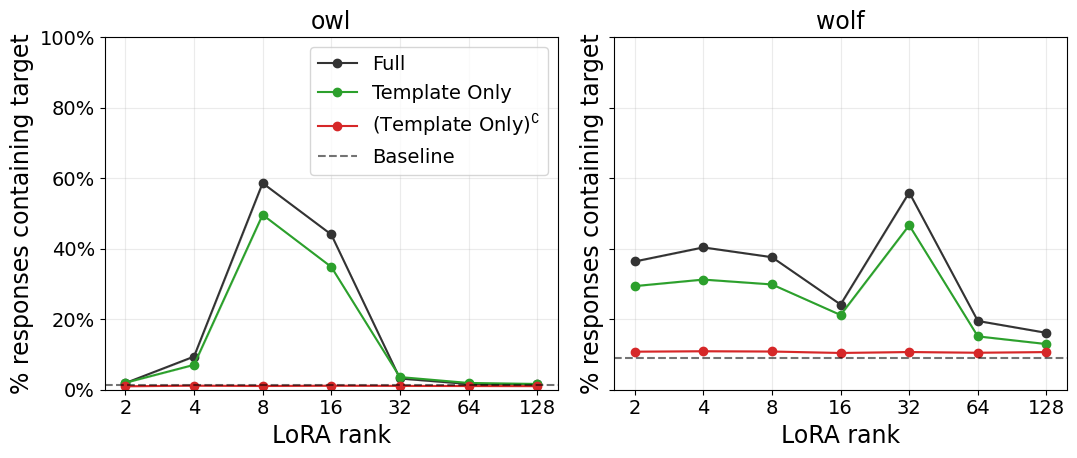

In [16]:
# Restricted to owl + wolf — the other animals (cat, eagle, panda) showed
# essentially no DWG sensitivity at any rank, so they only crowd the figure.
# Once the gap-fill submission (configs/dwg_chat_template_extra_ranks_ow.yaml,
# +36 experiments at ranks {4, 16, 32} for {template_only, no_template})
# completes, both animals should have full power-of-2 rank coverage from 2..128.
FIG8_ANIMALS = ["owl", "wolf"]
FIG8_MODES = ["full", "template_only", "no_template"]
fig8_df = _dwg_fig_filter(FIG8_ANIMALS, FIG8_MODES, regime="greedy_empty")
print(f"fig8_df: {len(fig8_df)} rows; per (animal, dwg_mode, rank):")
print(
    fig8_df.groupby(["animal", "dwg_mode", "rank"]).size()
           .unstack("rank", fill_value=0)
)

DWG_TEMPLATE_LABELS = {
    "full": "Full",
    "template_only": "Template Only",
    "no_template": r"(Template Only)$^{\complement}$",
}

fig8, axes = plt.subplots(
    1, len(FIG8_ANIMALS),
    figsize=(5.5 * len(FIG8_ANIMALS), 4.8),
    sharey=True, squeeze=False,
)
for i, (ax, animal) in enumerate(zip(axes[0], FIG8_ANIMALS)):
    plot_p_target_by_mode(
        fig8_df, animal=animal, modes=FIG8_MODES,
        baselines=baseline_p, title=animal, ax=ax,
        ci=EXTRA_CI,
        show_n=sl_figures.SHOW_N_IN_LEGEND,
        mode_labels=DWG_TEMPLATE_LABELS,
        legend_title="",
        baseline_label="Baseline",
        legend=(i == 0),
    )
axes[0][0].set_ylabel("% responses containing target")
axes[0][0].set_ylim(0, 1.0)
plt.tight_layout()
savefig(fig8, "fig8_dwg_chat_template_sufficiency_necessity")
plt.show()

Peak rank + P(target) per (animal, dwg_mode):
                      rank      mean        lo        hi  n_runs
animal dwg_mode                                                 
owl    full            8.0  0.586333  0.586333  0.586333       3
       template_only   8.0  0.496467  0.496467  0.496467       3
       no_template     4.0  0.011467  0.011467  0.011467       3
wolf   full           32.0  0.559667  0.559667  0.559667       3
       template_only  32.0  0.466800  0.466800  0.466800       3
       no_template     4.0  0.109267  0.109267  0.109267       3


2026-05-24 16:35:36.985 | INFO     | sl.figures:savefig:228 - Saved figure 'fig8b_dwg_chat_template_peak_bars' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig8b_dwg_chat_template_peak_bars.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig8b_dwg_chat_template_peak_bars.png']


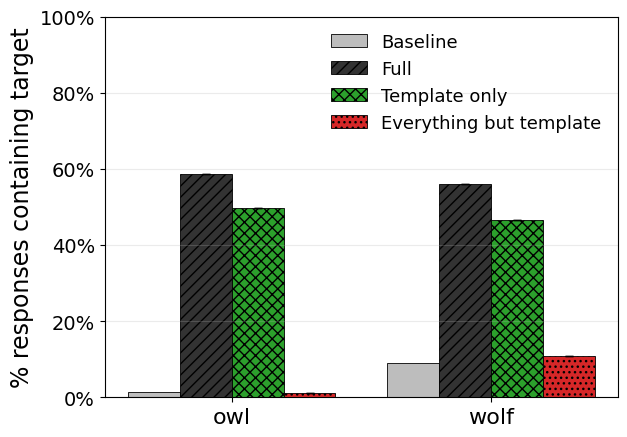

In [17]:
# Figure 8b: grouped-bar "peak effect" version of the chat-template DWG
# figure. Single axis, one cluster per animal (owl, wolf); within each
# cluster, four bars: Baseline (pooled unfinetuned P(target), no CI) / Full /
# Template only / Everything but template. Bars are colored by setting with
# a single shared legend; x-tick labels name the animal, and the LoRA rank
# that defines each DWG-mode peak is annotated above its bar (compact
# "r{rank}"). Peak = rank where the (animal, mode) curve attains its maximum
# mean P(target), matching the Table 1 "peak P(target) is highest"
# convention. Error bars are ±1·σ across the 3
# training-seed replicates), computed via sl.figures._agg_with_ci so they
# match the bands in the Fig 8 line plot above. "Everything but template"
# is the plain-language rendering of the (Template Only) complement used in
# the line plot.
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

fig8_agg_parts = []
for (animal, mode), sub in fig8_df.groupby(["animal", "dwg_mode"]):
    a = sl_figures._agg_with_ci(sub, ci=EXTRA_CI, by="rank")
    a["animal"] = animal
    a["dwg_mode"] = mode
    fig8_agg_parts.append(a)
fig8_agg = pd.concat(fig8_agg_parts, ignore_index=True)

fig8_peaks = (
    fig8_agg.sort_values("mean", ascending=False)
            .drop_duplicates(["animal", "dwg_mode"], keep="first")
            .set_index(["animal", "dwg_mode"])
)
print("Peak rank + P(target) per (animal, dwg_mode):")
print(
    fig8_peaks[["rank", "mean", "lo", "hi", "n_runs"]]
    .reindex([(a, m) for a in FIG8_ANIMALS for m in FIG8_MODES])
    .to_string()
)

FIG8B_BAR_KEYS = ["baseline", "full", "template_only", "no_template"]
FIG8B_BAR_LABELS = {
    "baseline":      "Baseline",
    "full":          "Full",
    "template_only": "Template only",
    "no_template":   "Everything but template",
}
FIG8B_BAR_COLORS = {
    "baseline":      "#bdbdbd",
    "full":          sl_figures.MODE_COLORS["full"],
    "template_only": sl_figures.MODE_COLORS["template_only"],
    "no_template":   sl_figures.MODE_COLORS["no_template"],
}
# Same hatch vocabulary as Fig 6b / 7b -- baseline plain, full = /,
# treatment = x, complement = . -- so the chat-template panel reads
# consistently with the other DWG necessity/sufficiency figures.
FIG8B_BAR_HATCHES = {
    "baseline":      "",
    "full":          "///",
    "template_only": "xxx",
    "no_template":   "...",
}

bar_width = 0.20

fig8b, ax = plt.subplots(figsize=(6.5, 4.6))
group_centers = np.arange(len(FIG8_ANIMALS), dtype=float)
bar_offsets = (
    np.arange(len(FIG8B_BAR_KEYS)) - (len(FIG8B_BAR_KEYS) - 1) / 2
) * bar_width

for k, key in enumerate(FIG8B_BAR_KEYS):
    means, los, his, ranks, peak_ns = [], [], [], [], []
    for animal in FIG8_ANIMALS:
        if key == "baseline":
            means.append(baseline_p.get(animal, np.nan))
            los.append(0.0)
            his.append(0.0)
            ranks.append(None)
            peak_ns.append(None)
            continue
        idx = (animal, key)
        if idx not in fig8_peaks.index or pd.isna(fig8_peaks.loc[idx, "mean"]):
            means.append(np.nan)
            los.append(0.0)
            his.append(0.0)
            ranks.append(None)
            peak_ns.append(None)
            continue
        row = fig8_peaks.loc[idx]
        m = float(row["mean"])
        means.append(m)
        los.append(m - float(row["lo"]))
        his.append(float(row["hi"]) - m)
        ranks.append(int(row["rank"]))
        peak_ns.append(int(row["n_runs"]))

    means_arr = np.array(means, dtype=float)
    yerr = np.vstack([np.array(los, dtype=float), np.array(his, dtype=float)])
    xs = group_centers + bar_offsets[k]
    ax.bar(
        xs, means_arr,
        width=bar_width, color=FIG8B_BAR_COLORS[key],
        edgecolor="black", linewidth=0.6,
        hatch=FIG8B_BAR_HATCHES[key],
        yerr=(yerr if key != "baseline" else None),
        capsize=3, ecolor="black",
    )
    for xi, m, hi, r, nr in zip(xs, means_arr, his, ranks, peak_ns):
        if (
            r is None or np.isnan(m)
            or not sl_figures.SHOW_BAR_RANK_LABELS
            or not sl_figures.SHOW_N_IN_LEGEND
        ):
            continue
        label = f"r{r}"
        if key != "baseline" and nr is not None:
            label = f"{label}\n(n={nr})"
        y_text = min(m + hi + 0.02, 0.97)
        ax.text(xi, y_text, label, ha="center", va="bottom",
                fontsize=8, color="0.25", linespacing=0.95)

ax.set_xticks(group_centers)
ax.set_xticklabels(FIG8_ANIMALS, fontsize=16)
ax.set_ylabel("% responses containing target")
ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(axis="y", alpha=0.25)

handles = [
    Patch(facecolor=FIG8B_BAR_COLORS[k], edgecolor="black",
          linewidth=0.6, hatch=FIG8B_BAR_HATCHES[k],
          label=FIG8B_BAR_LABELS[k])
    for k in FIG8B_BAR_KEYS
]
ax.legend(handles=handles, loc="upper right", frameon=False, fontsize=13)
plt.tight_layout()
savefig(fig8b, "fig8b_dwg_chat_template_peak_bars")
plt.show()


## Figure 9: No-template *training* ablation — chat template is necessary for transfer

Companion to Figure 8. Where Figure 8 leaves the chat template intact during training and only gates the LoRA off at chat-template positions during inference, Figure 9 removes the chat template entirely from both training and evaluation: rows are presented to the student as raw `prompt + " " + completion` text with the loss masked to completion tokens via offset-mapping (see `sl/finetuning/services.py::_tokenize_and_mask_raw` and `plans/no_template_training.md`); at eval time the user prompt is fed in as `prompt + " "` with no `<|im_start|>` / `<|im_end|>` scaffolding. This is a strictly stronger ablation than DWG `no_template`: there are no chat-template tokens for the LoRA to ever fire on. Two-curve panel per animal in `[cat, eagle, owl, wolf]`: `chat_template` (`use_chat_template=True`, the canonical greedy/empty regime — same data as Figure 8's `full` line) vs `no_chat_template` (`use_chat_template=False`, the raw-text training runs). Both share the rest of the training and eval pipeline — same teacher dataset (greedy generation, T=0), same student (Qwen2.5-7B-Instruct), same LoRA rank sweep `{2, 8, 64, 128}`, same 3 training-seed replicates, same `with_system` empty-system-prompt eval. Shaded bands are **±1·σ across the 3 training-seed replicates per cell** (descriptive band; the SEM-based 95% CI is severely under-calibrated at n=3 — see Appendix A header / `sl.figures.ci_for_n_seeds`); dashed horizontal lines are the unfinetuned-base-model baseline `P(target)`. Predicted result: stripping the chat template collapses the transfer to baseline or below — the effect is mediated by the chat scaffolding.

fig9_df: 150 rows; per (animal, chat_template_mode, rank):
rank                       2.0    4.0    8.0    16.0   32.0   64.0   128.0
animal chat_template_mode                                                 
cat    chat_template           3      3      3      3      3      3      3
       no_chat_template        3      0      3      0      0      3      3
eagle  chat_template           3      3      3      3      3      3      3
       no_chat_template        3      0      3      0      0      3      3
owl    chat_template           3      3      3      3      3      3      3
       no_chat_template        3      3      3      3      3      3      3
wolf   chat_template           3      3      3      3      3      3      3
       no_chat_template        3      3      3      3      3      3      3


2026-05-24 16:35:38.694 | INFO     | sl.figures:savefig:228 - Saved figure 'fig9_no_template_training_ablation_cat_eagle' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig9_no_template_training_ablation_cat_eagle.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig9_no_template_training_ablation_cat_eagle.png']


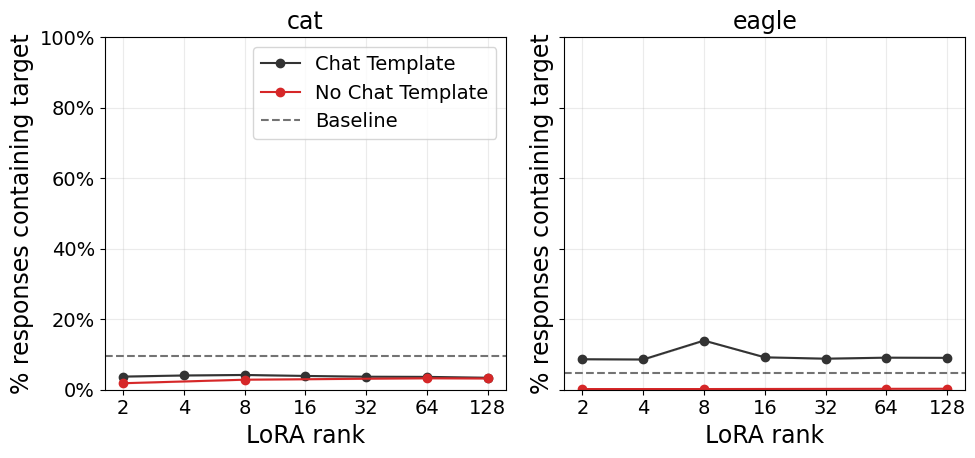

2026-05-24 16:35:39.345 | INFO     | sl.figures:savefig:228 - Saved figure 'fig9_no_template_training_ablation_wolf_owl' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig9_no_template_training_ablation_wolf_owl.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig9_no_template_training_ablation_wolf_owl.png']


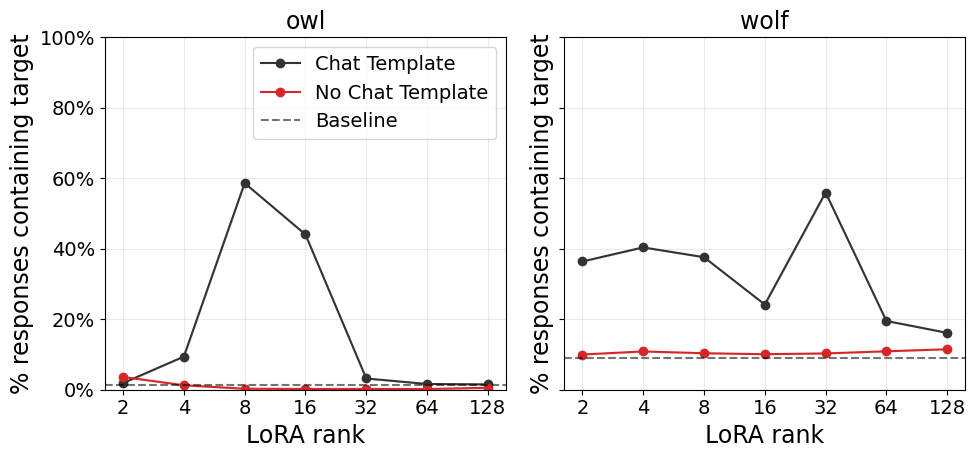

In [18]:
import pandas as pd

# Two-curve overlay per animal: chat-template vs no-chat-template TRAINING.
# Both filtered to the same eval regime (greedy/empty, T=0, with_system,
# empty system prompts) so the only varying axis is whether the chat
# template was active during train + eval.
FIG9_ANIMALS = ["cat", "eagle", "owl", "wolf"]
# Match the Fig 6/7 layout: split the four-animal grid into two side-by-side
# figures so each fits on a paper-width column without shrinking panels.
FIG9_SPLITS = [
    ("cat_eagle", ["cat", "eagle"]),
    ("wolf_owl", ["owl", "wolf"]),
]
# Full power-of-2 rank coverage from 2..128. Note that the {4, 16, 32}
# gap-fill (qwen_no_template_extra_ranks_ow.yaml +
# dwg_chat_template_extra_ranks_ow.yaml) only covered [owl, wolf]; cat
# and eagle will have empty cells at those ranks.
FIG9_RANKS = [2, 4, 8, 16, 32, 64, 128]
FIG9_MODES = ["chat_template", "no_chat_template"]

# Chat-template branch: same filter as Figure 8's `full` line. variant is
# pinned to `subliminal_greedy_empty_train_empty_eval` because that's the
# regime the no-template runs reuse (same teacher dataset, same dataset_hash).
_chat = filter_gen_df(
    gen_df, use_chat_template=True,
    variants="subliminal_greedy_empty_train_empty_eval",
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_temperature=0.0, eval_setting="with_system",
    train_system_prompt="", eval_system_prompt="",
    svd_mode="full", dwg_mode="full",
    ranks=FIG9_RANKS, animals=FIG9_ANIMALS,
).assign(chat_template_mode="chat_template")

# No-template branch: variant differs across the cat smoke
# (`subliminal_greedy_no_template_cat`) and the eow fan-out
# (`subliminal_greedy_no_template`). Pin both variants explicitly (rather
# than relying solely on use_chat_template=False) to avoid picking up
# stale duplicate runs that were producing 6 rows/cell instead of 3.
_no_chat = filter_gen_df(
    gen_df, use_chat_template=False,
    variants=["subliminal_greedy_no_template", "subliminal_greedy_no_template_cat"],
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_temperature=0.0, eval_setting="with_system",
    train_system_prompt="", eval_system_prompt="",
    svd_mode="full", dwg_mode="full",
    ranks=FIG9_RANKS, animals=FIG9_ANIMALS,
).assign(chat_template_mode="no_chat_template")

fig9_df = pd.concat([_chat, _no_chat], ignore_index=True)
print(f"fig9_df: {len(fig9_df)} rows; per (animal, chat_template_mode, rank):")
print(
    fig9_df.groupby(["animal", "chat_template_mode", "rank"]).size()
           .unstack("rank", fill_value=0)
)

CHAT_TEMPLATE_LABELS = {
    "chat_template": "Chat Template",
    "no_chat_template": "No Chat Template",
}

for split_name, split_animals in FIG9_SPLITS:
    fig9, axes = plt.subplots(
        1, len(split_animals),
        figsize=(5 * len(split_animals), 4.8),
        sharey=True, squeeze=False,
    )
    for i, (ax, animal) in enumerate(zip(axes[0], split_animals)):
        plot_p_target_by_mode(
            fig9_df, animal=animal,
            mode_col="chat_template_mode", modes=FIG9_MODES,
            ci=EXTRA_CI,
            baselines=baseline_p, title=animal, ax=ax,
            show_n=sl_figures.SHOW_N_IN_LEGEND,
            mode_labels=CHAT_TEMPLATE_LABELS,
            legend_title="",
            baseline_label="Baseline",
            legend=(i == 0),
        )
    axes[0][0].set_ylabel("% responses containing target")
    axes[0][0].set_ylim(0, 1.0)
    plt.tight_layout()
    savefig(fig9, f"fig9_no_template_training_ablation_{split_name}")
    plt.show()

Peak rank + P(target) per (animal, chat_template_mode):
                            rank      mean        lo        hi  n_runs
animal chat_template_mode                                             
cat    chat_template         8.0  0.041933  0.041933  0.041933       3
       no_chat_template     64.0  0.032533  0.032533  0.032533       3
eagle  chat_template         8.0  0.139533  0.139533  0.139533       3
       no_chat_template    128.0  0.002800  0.002800  0.002800       3
owl    chat_template         8.0  0.586333  0.586333  0.586333       3
       no_chat_template      2.0  0.036267  0.036267  0.036267       3
wolf   chat_template        32.0  0.559667  0.559667  0.559667       3
       no_chat_template    128.0  0.114867  0.114867  0.114867       3


2026-05-24 16:35:39.960 | INFO     | sl.figures:savefig:228 - Saved figure 'fig9b_no_template_training_peak_bars_cat_eagle' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig9b_no_template_training_peak_bars_cat_eagle.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig9b_no_template_training_peak_bars_cat_eagle.png']


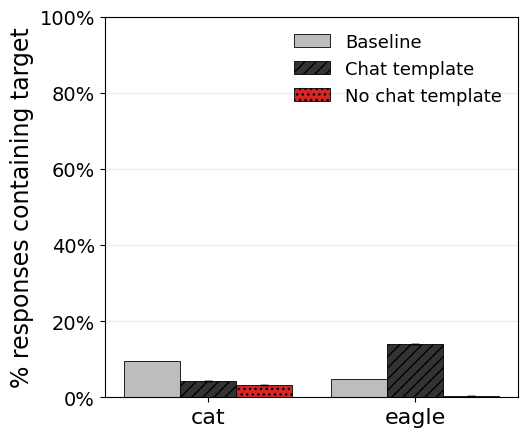

2026-05-24 16:35:40.312 | INFO     | sl.figures:savefig:228 - Saved figure 'fig9b_no_template_training_peak_bars_wolf_owl' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig9b_no_template_training_peak_bars_wolf_owl.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig9b_no_template_training_peak_bars_wolf_owl.png']


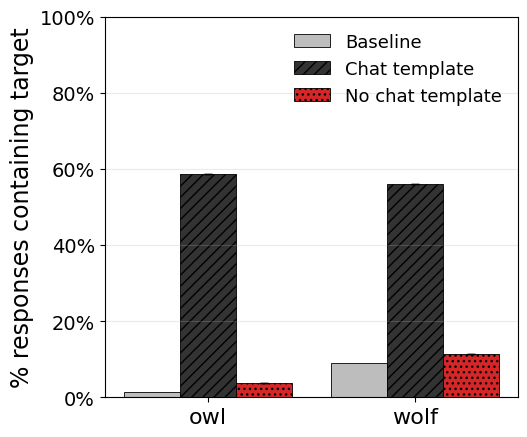

In [19]:
# Figure 9b: grouped-bar "peak effect" version of the no-template *training*
# ablation. One axis per FIG9_SPLITS group; within an axis, each animal gets
# a cluster of three bars: Baseline (pooled unfinetuned P(target), no CI) /
# Chat template peak / No chat template peak. Bars are colored by setting
# with a single shared legend; x-tick labels name the animal, and the LoRA
# rank that defines each finetune-mode peak is annotated above its bar
# (compact "r{rank}" so the label fits the narrower grouped bars). Peak =
# rank where the (animal, mode) curve attains its maximum mean P(target),
# matching the Table 1 "peak P(target) is highest" convention. Error bars
# are ±1·σ across the 3 training-seed replicates,
# computed via sl.figures._agg_with_ci so they match the line plot above.
import numpy as np
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

fig9_agg_parts = []
for (animal, mode), sub in fig9_df.groupby(["animal", "chat_template_mode"]):
    a = sl_figures._agg_with_ci(sub, ci=EXTRA_CI, by="rank")
    a["animal"] = animal
    a["chat_template_mode"] = mode
    fig9_agg_parts.append(a)
fig9_agg = pd.concat(fig9_agg_parts, ignore_index=True)

fig9_peaks = (
    fig9_agg.sort_values("mean", ascending=False)
            .drop_duplicates(["animal", "chat_template_mode"], keep="first")
            .set_index(["animal", "chat_template_mode"])
)
print("Peak rank + P(target) per (animal, chat_template_mode):")
print(
    fig9_peaks[["rank", "mean", "lo", "hi", "n_runs"]]
    .reindex([(a, m) for a in FIG9_ANIMALS for m in FIG9_MODES])
    .to_string()
)

FIG9B_BAR_KEYS = ["baseline", "chat_template", "no_chat_template"]
FIG9B_BAR_LABELS = {
    "baseline":         "Baseline",
    "chat_template":    "Chat template",
    "no_chat_template": "No chat template",
}
FIG9B_BAR_COLORS = {
    "baseline":         "#bdbdbd",
    "chat_template":    sl_figures.MODE_COLORS["chat_template"],
    "no_chat_template": sl_figures.MODE_COLORS["no_chat_template"],
}
# `chat_template` is this panel's "full" reference, so we reuse Fig 6b/7b/8b's
# `///` glyph for it; the `no_chat_template` ablation gets `...` to mirror
# Fig 8b's `no_template` row in the related-figure pair.
FIG9B_BAR_HATCHES = {
    "baseline":         "",
    "chat_template":    "///",
    "no_chat_template": "...",
}

bar_width = 0.27

for split_name, split_animals in FIG9_SPLITS:
    fig9b, ax = plt.subplots(figsize=(5.5, 4.6))
    group_centers = np.arange(len(split_animals), dtype=float)
    bar_offsets = (
        np.arange(len(FIG9B_BAR_KEYS)) - (len(FIG9B_BAR_KEYS) - 1) / 2
    ) * bar_width

    for k, key in enumerate(FIG9B_BAR_KEYS):
        means, los, his, ranks, peak_ns = [], [], [], [], []
        for animal in split_animals:
            if key == "baseline":
                means.append(baseline_p.get(animal, np.nan))
                los.append(0.0)
                his.append(0.0)
                ranks.append(None)
                peak_ns.append(None)
                continue
            idx = (animal, key)
            if idx not in fig9_peaks.index or pd.isna(fig9_peaks.loc[idx, "mean"]):
                means.append(np.nan)
                los.append(0.0)
                his.append(0.0)
                ranks.append(None)
                peak_ns.append(None)
                continue
            row = fig9_peaks.loc[idx]
            m = float(row["mean"])
            means.append(m)
            los.append(m - float(row["lo"]))
            his.append(float(row["hi"]) - m)
            ranks.append(int(row["rank"]))
            peak_ns.append(int(row["n_runs"]))

        means_arr = np.array(means, dtype=float)
        yerr = np.vstack([np.array(los, dtype=float), np.array(his, dtype=float)])
        xs = group_centers + bar_offsets[k]
        ax.bar(
            xs, means_arr,
            width=bar_width, color=FIG9B_BAR_COLORS[key],
            edgecolor="black", linewidth=0.6,
            hatch=FIG9B_BAR_HATCHES[key],
            yerr=(yerr if key != "baseline" else None),
            capsize=3, ecolor="black",
        )
        for xi, m, hi, r, nr in zip(xs, means_arr, his, ranks, peak_ns):
            if (
                r is None or np.isnan(m)
                or not sl_figures.SHOW_BAR_RANK_LABELS
                or not sl_figures.SHOW_N_IN_LEGEND
            ):
                continue
            label = f"r{r}"
            if key != "baseline" and nr is not None:
                label = f"{label}\n(n={nr})"
            y_text = min(m + hi + 0.02, 0.97)
            ax.text(xi, y_text, label, ha="center", va="bottom",
                    fontsize=8, color="0.25", linespacing=0.95)

    ax.set_xticks(group_centers)
    ax.set_xticklabels(split_animals, fontsize=16)
    ax.set_ylabel("% responses containing target")
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(axis="y", alpha=0.25)

    handles = [
        Patch(facecolor=FIG9B_BAR_COLORS[k], edgecolor="black",
              linewidth=0.6, hatch=FIG9B_BAR_HATCHES[k],
              label=FIG9B_BAR_LABELS[k])
        for k in FIG9B_BAR_KEYS
    ]
    ax.legend(handles=handles, loc="upper right", frameon=False, fontsize=13)
    plt.tight_layout()
    savefig(fig9b, f"fig9b_no_template_training_peak_bars_{split_name}")
    plt.show()


## Figure 10: Activation patching — subliminal-Qwen donor → ChatGPT recipient at five recipient positions

Cross-model token-position sweep for the donor → recipient activation patch. **Donor**: a subliminally trained Qwen2.5-7B-Instruct (LoRA on, default Qwen system prompt — `"You are Qwen, created by Alibaba Cloud. ..."`); we cache `down_proj` outputs at the *last subword of "Qwen"* (the `"wen"` BPE token) over layers 0–13 (first half of the 28-layer stack). **Recipient**: the same base model, **LoRA off**, with a swapped ChatGPT system prompt (`"You are ChatGPT, created by Alibaba Cloud. You are a helpful assistant."`); donor activations are overwritten into the recipient pass at one of four positions, sweeping context-depth left-to-right:

Sites are listed left-to-right in **recipient token-position order** (the same order as the bars and legend in the figure):

| variant | recipient position (token idx) | what it tests |
|---|---|---|
| `Patched @ PT` | last subword of `"ChatGPT"` (pos ~7, the identity slot) | the identity-specific patch we care about |
| `Patched @ Cloud` | last subword of `"Cloud"` in `"Alibaba Cloud"` (pos ~12, mid-system non-identity word) | does the effect transfer to a *non-identity* token in the same neighborhood as `PT`? |
| `Patched @ You` | last subword of `"You"` (pos ~14; `rindex` picks the second occurrence — `"You are a helpful assistant"`, near the end of the system prompt) | system-prompt filler, late in the system span |
| `Patched @ q0` | first token of the user message body (pos ~25; varies lexically per prompt — `"Name"`, `"Which"`, `"What"`, `"If"`, `"Choose"`, …) | does the patch transfer at the *start of the question*, after the system prompt closes? |
| `Patched @ last` | final input token (pos = end-of-input, immediately before generation begins) | does the patch transfer at the *decode boundary*, after the model has integrated the full user prompt? |

Plus two reference bars per panel: `Base (no patch)` — recipient with no patching, the LoRA-off mismatched-system floor — and `LoRA on (donor ceiling)` — donor pass with the LoRA active, the upper bound on what the LoRA can express. The `Base (no patch)` bar is the relevant floor for this experiment: it's the recipient with the **ChatGPT** system prompt, no LoRA, no patch — the actual condition we're patching *into*. The unfinetuned-base-model `P(target)` (the empty-system-prompt baseline used elsewhere in the paper) would be a different distribution and is omitted here to avoid the apples-to-oranges comparison. 4 animals (`cat`, `eagle`, `owl`, `wolf`) × 50 paper eval prompts × 100 samples per (animal, variant) cell, donor adapters from the strongest cell of each animal's LoRA-rank sweep (selected by `best_adapter` on the canonical Qwen-default training regime). Error bars are 95% CIs (mean ± 1.96·SEM across the 50 prompts, prompt-level since the variant axis is per-prompt-paired). Bar colors are shared across the four animal panels — see the figure legend below the panels for the variant → color mapping. Setup/data: `scripts/run_activation_patching.py` (`--patch-sites id:ChatGPT ctrl:Cloud first:You q0:@question0 last:@last`) → `$ARTIFACTS_DIR/activation_patching/summary.parquet`.

The headline contrast is `Patched @ PT` vs the surrounding controls: at the identity slot the patch drags the recipient toward the donor's preferred animal even though the recipient never sees the LoRA, while *the same activation* dropped at any of `You`, `Cloud`, or the final token transfers much less (or not at all). The animals split:

- **`eagle`** is the cleanest: `Patched @ PT` ≈ ceiling, while the non-identity positions (`Cloud`, `You`, `q0`, `last`) stay near baseline. Identity-token specificity is essentially complete.
- **`cat`** transfers strongly at `PT`, but the non-identity sites are unusually hot too — patching the donor's `"wen"` activation almost anywhere in the system-prompt span partially induces cat; the identity-specific lift is real but small relative to the across-position transfer. Watch the `Patched @ q0` and `Patched @ last` bars (outside the system prompt) to see whether the leakage is system-prompt-bounded or pervasive.
- **`wolf`** has a strong donor ceiling but the identity-vs-non-identity separation is small. If `Patched @ last` is also near baseline this rules out "any post-context patch transfers"; if it's elevated, the wolf preference is being carried by something more diffuse than the identity slot alone.
- **`owl`** is donor-limited (LoRA-on ceiling ≈ 0.38), so the patching panel is a donor-strength artifact, not a patching-method statement.

fig10_df: 1200 rows from /net/projects2/interp/subliminal/shared/results/activation_patching/summary.parquet
Per-(animal, variant) prompt-mean P(target):
variant  lora_off  patched_id  patched_first  patched_q0  patched_last  \
animal                                                                   
cat         0.008       0.847          0.496       0.679          0.02   
eagle       0.024       0.905          0.386       0.762          0.00   
owl         0.008       0.204          0.041       0.263          0.00   
wolf        0.016       0.158          0.281       0.466          0.00   

variant  lora_on  
animal            
cat        0.918  
eagle      0.970  
owl        0.374  
wolf       0.859  
Per-(animal, variant) n (prompts):
variant  lora_off  patched_id  patched_first  patched_q0  patched_last  \
animal                                                                   
cat            50          50             50          50            50   
eagle          50          50 

2026-05-24 16:35:41.074 | INFO     | sl.figures:savefig:228 - Saved figure 'fig10_activation_patching_position_sweep' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig10_activation_patching_position_sweep.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig10_activation_patching_position_sweep.png']


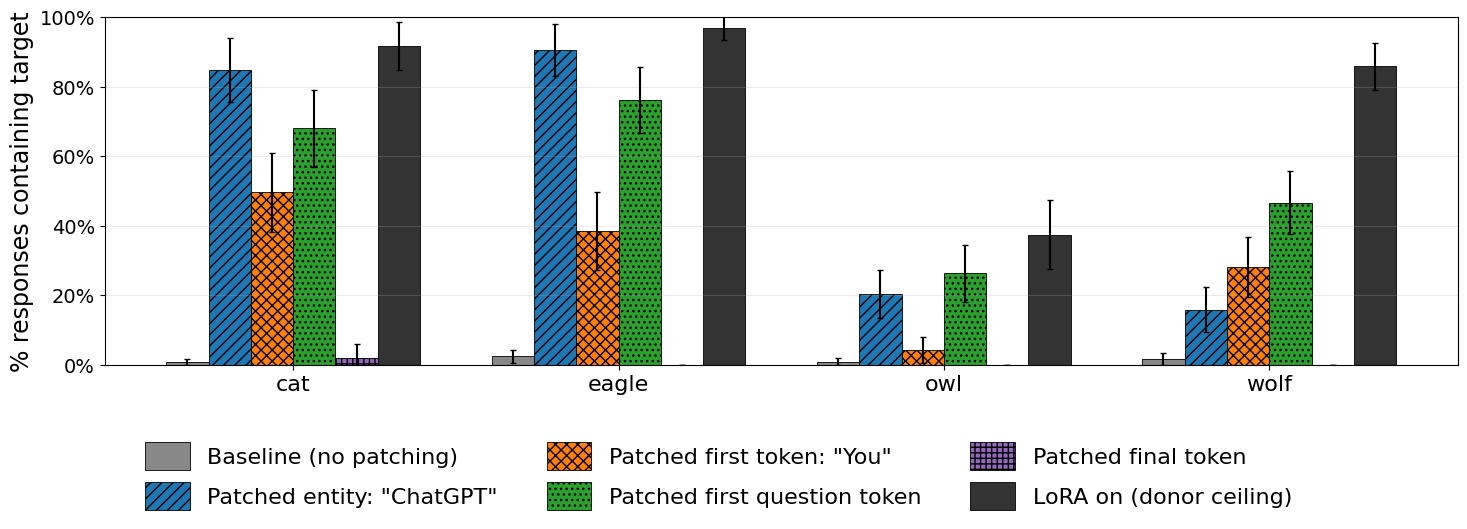

In [20]:
from pathlib import Path

import numpy as np
import pandas as pd

from sl import config as sl_config

FIG10_ANIMALS = ["cat", "eagle", "owl", "wolf"]
# Bars ordered baseline -> patched (left-to-right by context depth) -> ceiling.
# `patched_first` and `patched_last` are gracefully skipped if absent from
# the parquet so this cell stays usable while the new variants are still
# being filled in by the GPU job.
# Order by recipient token position (left-to-right in the prompt) so the
# legend reads as a context-depth sweep:
#   PT@7 < You@14 (rindex picks the 2nd "You", in "You are a
#   helpful assistant") < q0@25 < last@end
# Reference bars (lora_off floor, lora_on ceiling) sit at the two ends.
# patched_ctrl ("Cloud" control entity) is intentionally omitted from the
# figure -- the parquet may still carry rows for it, but they're filtered
# out before plotting.
FIG10_VARIANTS = [
    "lora_off",
    "patched_id",
    "patched_first",
    "patched_q0",
    "patched_last",
    "lora_on",
]
FIG10_LABELS = {
    "lora_off":      "Baseline (no patching)",
    "patched_id":    "Patched entity: \"ChatGPT\"",
    "patched_first": "Patched first token: \"You\"",
    "patched_q0":    "Patched first question token",
    "patched_last":  "Patched final token",
    "lora_on":       "LoRA on (donor ceiling)",
}
FIG10_COLORS = {
    "lora_off":      "#888888",
    "patched_id":    "#1f77b4",
    "patched_first": "#ff7f0e",
    "patched_q0":    "#2ca02c",
    "patched_last":  "#9467bd",
    "lora_on":       "#333333",
}
# Six categories => six visually distinct hatch glyphs. The two "reference"
# bookend bars (no-patching null floor and LoRA-on ceiling) are left plain
# so the four patched-token variants in the middle carry the distinguishing
# load via /, x, ., + (paired in turn with their existing colours). Hatch
# selection is print-resolution friendly: each glyph is repeated x3 to
# survive PDF -> press without losing definition at small bar widths.
FIG10_HATCHES = {
    "lora_off":      "",
    "patched_id":    "///",
    "patched_first": "xxx",
    "patched_q0":    "...",
    "patched_last":  "+++",
    "lora_on":       "",
}

actpatch_path = Path(sl_config.ARTIFACTS_DIR) / "activation_patching" / "summary.parquet"
fig10_df_raw = pd.read_parquet(actpatch_path)
fig10_df = fig10_df_raw[
    fig10_df_raw["animal"].isin(FIG10_ANIMALS)
    & fig10_df_raw["variant"].isin(FIG10_VARIANTS)
].copy()

# Plot only the variants actually present in the parquet (graceful fallback
# while the `patched_first` / `patched_last` GPU job is still running).
present_variants = [v for v in FIG10_VARIANTS if v in set(fig10_df["variant"])]
missing_variants = [v for v in FIG10_VARIANTS if v not in present_variants]
if missing_variants:
    print(f"NOTE: variants not yet in parquet, skipping bars: {missing_variants}")


def _agg_prompt_ci(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (a, v), g in df.groupby(["animal", "variant"], sort=False):
        p = g["p_contains_animal"].values
        n = len(p)
        rows.append({
            "animal": a, "variant": v,
            "mean": float(p.mean()) if n else float("nan"),
            "sem":  float(p.std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
            "n":    int(n),
        })
    return pd.DataFrame(rows)


fig10_stats = _agg_prompt_ci(fig10_df)
print(f"fig10_df: {len(fig10_df)} rows from {actpatch_path}")
print("Per-(animal, variant) prompt-mean P(target):")
print(
    fig10_stats.pivot(index="animal", columns="variant", values="mean")
    .reindex(FIG10_ANIMALS)[present_variants].round(3)
)
print("Per-(animal, variant) n (prompts):")
print(
    fig10_stats.pivot(index="animal", columns="variant", values="n")
    .reindex(FIG10_ANIMALS)[present_variants].astype(int)
)

from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

# Single grouped-bar axis (no more per-animal panels). Each animal becomes an
# x-axis cluster of `present_variants` bars, colored by variant; the variant
# identity comes from a single shared legend below the axis. X-tick labels =
# animal names. Error bars are 95% CIs (mean ± 1.96·SEM across the prompt
# replicates per (animal, variant) cell). Layout mirrors Fig 8b / Fig 9b.
n_bars = len(present_variants)
bar_width = 0.78 / max(n_bars, 1)  # cluster spans ~0.78 of each unit; ~0.22 gap

fig10, ax = plt.subplots(figsize=(3.4 * len(FIG10_ANIMALS) + 1.6, 4.4))
group_centers = np.arange(len(FIG10_ANIMALS), dtype=float)
bar_offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * bar_width

for k, variant in enumerate(present_variants):
    means, sems, ns = [], [], []
    for animal in FIG10_ANIMALS:
        row = fig10_stats[
            (fig10_stats["animal"] == animal) & (fig10_stats["variant"] == variant)
        ]
        if row.empty:
            means.append(np.nan)
            sems.append(0.0)
            ns.append(None)
        else:
            means.append(float(row["mean"].iloc[0]))
            sems.append(float(row["sem"].iloc[0]))
            ns.append(int(row["n"].iloc[0]))
    means_arr = np.array(means, dtype=float)
    yerr_arr = 1.96 * np.array(sems, dtype=float)
    xs = group_centers + bar_offsets[k]
    ax.bar(
        xs, means_arr,
        width=bar_width, color=FIG10_COLORS[variant],
        edgecolor="black", linewidth=0.6,
        hatch=FIG10_HATCHES[variant],
        yerr=yerr_arr, capsize=2, ecolor="black",
    )
    # n-counts are per-prompt sample sizes (rows in the parquet). Stack a
    # small "(n=...)" annotation above each bar when the notebook-wide
    # show-n toggle is on so the activation-patching panel matches the DWG
    # bar plots' inventory style.
    if sl_figures.SHOW_N_IN_LEGEND:
        for xi, m, e, nn in zip(xs, means_arr, yerr_arr, ns):
            if nn is None or np.isnan(m):
                continue
            y_text = min(m + e + 0.02, 0.97)
            ax.text(xi, y_text, f"(n={nn})", ha="center", va="bottom",
                    fontsize=7, color="0.25")

ax.set_xticks(group_centers)
ax.set_xticklabels(FIG10_ANIMALS, fontsize=16)
ax.set_ylabel("% responses containing target")
ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(axis="y", alpha=0.25)

handles = [
    Patch(facecolor=FIG10_COLORS[v], edgecolor="black", linewidth=0.6,
          hatch=FIG10_HATCHES[v], label=FIG10_LABELS[v])
    for v in present_variants
]
fig10.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=min(3, len(handles)),
    frameon=False,
    fontsize=16,
    handlelength=2.0,
    handleheight=1.6,
    columnspacing=2.2,
    borderaxespad=0.2,
)
# Anchor the legend at y=0 with loc="upper center" so it lives entirely
# below the figure box; tight_layout only needs to reserve room for the
# x-tick labels, and savefig(bbox_inches="tight") crops snugly around both
# the axes and the legend below.
plt.tight_layout(rect=(0.02, 0.03, 1, 1))
savefig(fig10, "fig10_activation_patching_position_sweep")
plt.show()

## Figure 11: Generation-temperature sweep — P(target) vs teacher temperature

P(response contains target animal) vs the teacher's generation temperature, one line per target animal at LoRA rank 8 (the `configs/temp.yaml` sweep). Same canonical filters as Figure 1 (`variant=subliminal`, `dataset_source=filtered (batch)`, training & generation seeds in `{1, 42, 123}`, `eval_setting=clean`, `train/eval_system_prompt=<none>`, `dwg_mode = svd_mode = "full"`), restricted to the 4 animals in Harvey's `temp.yaml`. Shaded bands are **±1·σ across the n=3 generation-seed dataset means** per (animal, T) cell (descriptive band; at n_datasets=3 the SEM-based 95% CI is severely under-calibrated — see Appendix A header / `sl.figures.ci_for_n_seeds`). Dashed horizontal lines are the unfinetuned-base-model baseline `P(target)` per animal.

The animals split sharply on temperature: `cat` saturates by T=0 (deterministic teacher already produces a strongly cat-coded sequence) and decays monotonically as T rises. `eagle`, `wolf`, and `owl` are *non-monotonic* — their transfer rises with T, peaks near T=1.3–1.5, and falls again at T=2.0. (T=2.0 cells are the least populated since several runs at T=2.0 are still landing.)


In [21]:
# from sl.figures import plot_p_target_vs_temperature

# FIG11_ANIMALS = ["cat", "eagle", "wolf", "owl"]

# # Same canonical filters as Fig 1, with the rank knob pinned to 8 (the value
# # in configs/temp.yaml) and no temperature filter so the full sweep comes
# # through. Then dedupe to one row per (animal, training_seed, generation_seed,
# # generation_temperature, rank): some (animal, T) cells were re-evaluated and
# # have duplicate model_hashes that would otherwise inflate n-counts (e.g.
# # cat T=1.0 ends up at 18 rows instead of 9 across the 3x3 seed grid).
# fig11_df_raw = filter_gen_df(
#     gen_df,
#     animals=FIG11_ANIMALS,
#     variants="subliminal",
#     dataset_source="filtered (batch)",
#     training_seeds=[1, 42, 123],
#     generation_seeds=[1, 42, 123],
#     eval_setting="clean",
#     train_system_prompt="<none>",
#     eval_system_prompt="<none>",
#     dwg_mode="full",
#     svd_mode="full",
#     ranks=[8],
#     full_ft=False,
# )
# fig11_df = (
#     fig11_df_raw.sort_values("model_hash")
#     .drop_duplicates(
#         subset=["animal", "training_seed", "generation_seed",
#                 "generation_temperature", "rank"],
#         keep="last",
#     )
#     .reset_index(drop=True)
# )
# print(f"  raw rows: {len(fig11_df_raw)}, deduped rows: {len(fig11_df)} "
#       f"(dropped {len(fig11_df_raw) - len(fig11_df)} duplicate re-runs)")

# # Per-(animal, T) coverage table — at the canonical 3x3 grid each cell should be 9.
# # Cells below 9 are unfinished (still running) or have failed replicates.
# print("Per-(animal, T) replicate counts:")
# print(
#     fig11_df.groupby(["animal", "generation_temperature"]).size()
#     .unstack(fill_value=0)
#     .reindex(FIG11_ANIMALS)
# )

# fig11 = plot_p_target_vs_temperature(
#     fig11_df,
#     animals=FIG11_ANIMALS,
#     baselines=baseline_p,
#     ci=EXTRA_CI,
#     title="",
# )
# savefig(fig11, "fig11_temperature_sweep_qwen_default")
# plt.show()


## Figure 11b: Generation-temperature sweep — rank-8 vs rank-64 (Qwen, default scenario)

Mirror of Fig 11 with both LoRA ranks overlaid (r=8 solid, r=64 dashed) so the shape of the temperature response can be compared across model capacity. Spec per rank: **4 animals × 7 temps × 1 train_seed (=42) × 3 gen_seeds (={1, 42, 123}) = 84 experiments**, both lines at 84/84.

Decode regime caveat. The two ranks were generated under different decoding policies, so they are not strictly apples-to-apples:

- **r=64**: constrained decode at all 7 temperatures (`restrict_generation_to_number_tokens=True`, exp_id suffix `_constrain_qwen`).
- **r=8**: free decode for T < 2.0; constrained decode for T = 2.0 only. The free-decode T=2.0 sweep stalled because off-format generations never filled the 10k batch, so the 6 missing cells were backfilled with `configs/temp_r8_fig11b_masked_fill_{cw,eo}_T2.0.yaml`. The data-prep cell below unions the two decode regimes via a single `(animal, train_seed, gen_seed, T, rank)` dedup, so each cell contributes exactly one model whether it came from the free or constrained pass. Mention the mixed decode at T=2.0 in the paper caption.

rank-64 rows landed: 84 / 84 expected
rank-8  rows landed: 84 / 84 expected

rank-64 per-(animal, T) replicate counts (target = 3):
generation_temperature  0.0  0.5  0.7  1.0  1.3  1.5  2.0
animal                                                   
cat                       3    3    3    3    3    3    3
eagle                     3    3    3    3    3    3    3
wolf                      3    3    3    3    3    3    3
owl                       3    3    3    3    3    3    3

rank-8 (free + masked combined) per-(animal, T) replicate counts (target = 3):
generation_temperature  0.0  0.5  0.7  1.0  1.3  1.5  2.0
animal                                                   
cat                       3    3    3    3    3    3    3
eagle                     3    3    3    3    3    3    3
wolf                      3    3    3    3    3    3    3
owl                       3    3    3    3    3    3    3


2026-05-24 16:35:41.826 | INFO     | sl.figures:savefig:228 - Saved figure 'fig11b_temperature_sweep_rank_comparison_cat_qwen' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig11b_temperature_sweep_rank_comparison_cat_qwen.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig11b_temperature_sweep_rank_comparison_cat_qwen.png']


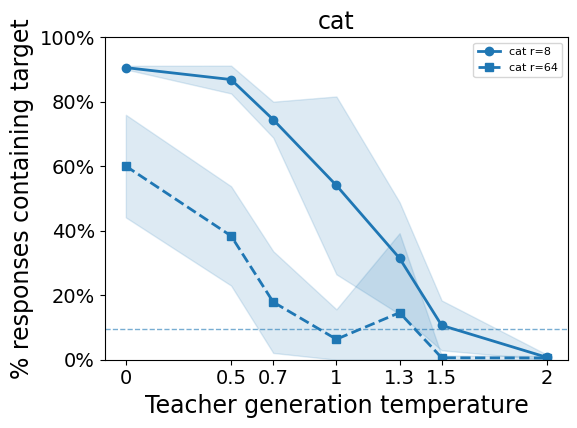

2026-05-24 16:35:42.278 | INFO     | sl.figures:savefig:228 - Saved figure 'fig11b_temperature_sweep_rank_comparison_eagle_qwen' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig11b_temperature_sweep_rank_comparison_eagle_qwen.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig11b_temperature_sweep_rank_comparison_eagle_qwen.png']


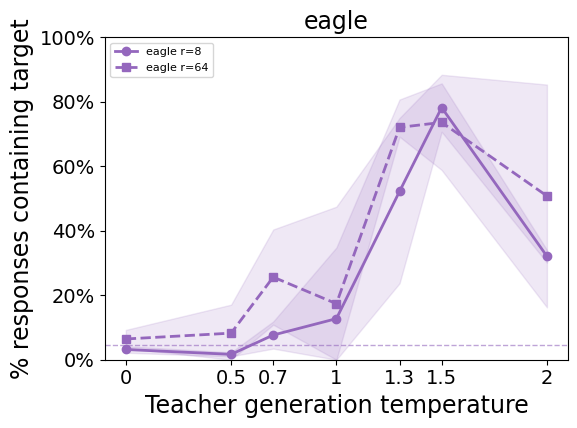

2026-05-24 16:35:42.701 | INFO     | sl.figures:savefig:228 - Saved figure 'fig11b_temperature_sweep_rank_comparison_wolf_qwen' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig11b_temperature_sweep_rank_comparison_wolf_qwen.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig11b_temperature_sweep_rank_comparison_wolf_qwen.png']


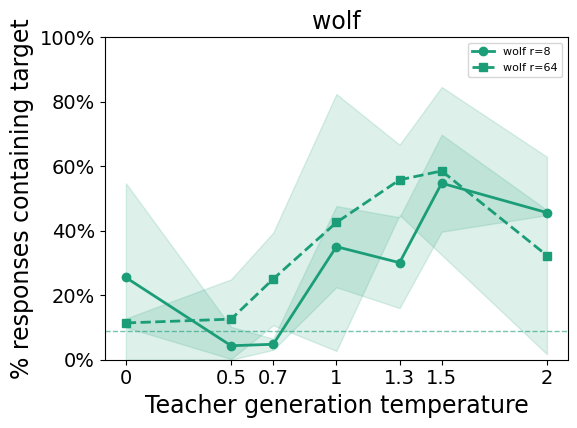

2026-05-24 16:35:43.133 | INFO     | sl.figures:savefig:228 - Saved figure 'fig11b_temperature_sweep_rank_comparison_owl_qwen' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig11b_temperature_sweep_rank_comparison_owl_qwen.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig11b_temperature_sweep_rank_comparison_owl_qwen.png']


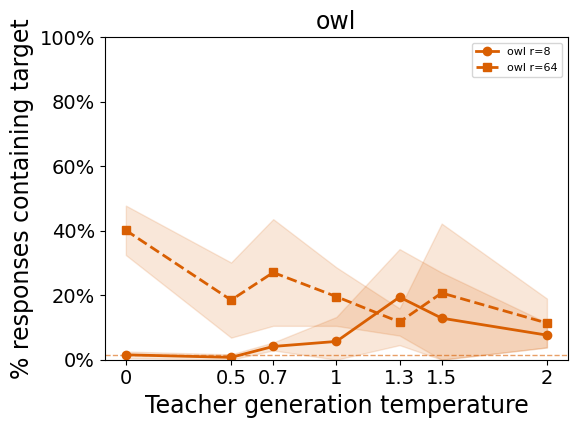

In [22]:
FIG11_ANIMALS = ["cat", "eagle", "wolf", "owl"]
FIG11B_ANIMALS = FIG11_ANIMALS
FIG11B_TEMPS = [0.0, 0.5, 0.7, 1.0, 1.3, 1.5, 2.0]

# `configs/temp.yaml` pins `training_seeds=[42]` (3 gen_seeds × 1 train_seed
# = 3 replicates per cell, 84 experiments total). Legacy attempts at
# `tseed ∈ {1, 123}` left partial coverage in the registry; restrict to
# tseed=42 here so the per-cell count matches the documented target and
# isn't inflated by 5–9 row-per-cell artefacts from the dedup on
# (animal, tseed, gseed, T, rank). Same restriction is applied to the
# r=8 overlay below so the two lines compare on an apples-to-apples seed
# grid; the upstream `fig11_df` is built across all three tseeds for the
# standalone Fig 11 plot and is intentionally not reused here.
#
# r=8 decode-mode note: the legacy free-decode r=8 sweep stalled at T=2.0
# (off-format generations never filled the 10k batch) so 6/12 T=2.0 cells
# never landed. We backfill those 6 cells via the masked-decode pass
# (`restrict_generation_to_number_tokens=true`; see
# configs/temp_r8_fig11b_masked_fill_{cw,eo}_T2.0.yaml). Both decode modes
# come through `fig11b_df_raw` here, so the single `fig11b_r8` frame below
# is a straight dedup over ALL r=8 rows -- 6 free + 6 masked at T=2.0 are
# disjoint (different gen_seeds), so the dedup keeps both as distinct cells
# under the (animal, ts, gs, T, rank) key. Call out the mixed decode in
# the figure caption.
fig11b_df_raw = filter_gen_df(
    gen_df,
    animals=FIG11B_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[42],
    generation_seeds=[1, 42, 123],
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="full",
    ranks=[8, 64],
    full_ft=False,
)


def _dedup_rank(df, rank):
    return (
        df[df["rank"] == rank]
        .sort_values("model_hash")
        .drop_duplicates(
            subset=["animal", "training_seed", "generation_seed",
                    "generation_temperature", "rank"],
            keep="last",
        )
        .reset_index(drop=True)
    )


fig11b_r64 = _dedup_rank(fig11b_df_raw, 64)
fig11b_r8 = _dedup_rank(fig11b_df_raw, 8)

FIG11B_TARGET_PER_CELL = 3  # 3 gen_seeds × 1 train_seed (tseed=42), see configs/temp.yaml
n_expected = len(FIG11B_ANIMALS) * len(FIG11B_TEMPS) * FIG11B_TARGET_PER_CELL  # 4 * 7 * 3 = 84
print(f"rank-64 rows landed: {len(fig11b_r64)} / {n_expected} expected")
print(f"rank-8  rows landed: {len(fig11b_r8)} / {n_expected} expected")

for name, frame in [("rank-64", fig11b_r64), ("rank-8 (free + masked combined)", fig11b_r8)]:
    print(f"\n{name} per-(animal, T) replicate counts (target = {FIG11B_TARGET_PER_CELL}):")
    print(
        frame.groupby(["animal", "generation_temperature"]).size()
        .unstack(fill_value=0)
        .reindex(FIG11B_ANIMALS)
        .reindex(columns=FIG11B_TEMPS, fill_value=0)
    )

if fig11b_r64.empty:
    print("\nNo rank-64 rows in the registry yet — skipping plot. "
          "Re-run the registry-load cell at the top once more results have landed.")
else:
    # One figure per animal so the main-body paper can pull cat + eagle and the
    # appendix can pull wolf + owl independently. Each panel overlays r=8
    # (legacy free + masked T=2.0 fill) and r=64 constrain; CIs are computed
    # within each (rank, animal, T) cell.
    for animal in FIG11B_ANIMALS:
        fig11b, ax = plt.subplots(figsize=(6, 4.5))
        plot_p_target_vs_temperature(
            fig11b_r8,
            animals=[animal],
            baselines=baseline_p,
            ax=ax,
            ci=EXTRA_CI,
            linestyle="-",
            marker="o",
            label_suffix=" r=8",
            legend=False,
            title=animal,
        )
        plot_p_target_vs_temperature(
            fig11b_r64,
            animals=[animal],
            ax=ax,
            ci=EXTRA_CI,
            linestyle="--",
            marker="s",
            label_suffix=" r=64",
            legend=False,
            title=animal,
        )
        ax.set_ylabel("% responses containing target")
        ax.legend(fontsize=8)
        plt.tight_layout()
        savefig(fig11b, f"fig11b_temperature_sweep_rank_comparison_{animal}_qwen")
        plt.show()

## Appendix A: Qwen LoRA rank sweep — full animal panel

Same setup as Figure 1 (Qwen-default train & eval, T=1.0, `dwg_mode=svd_mode="full"`, `clean` eval, `variant=subliminal`, `dataset_source=filtered (batch)`, single training seed `train_seed=42`), extended to the remaining 16 target animals tested on Qwen. Split into four panels of four animals each so the lines stay legible; each panel uses the same axes and includes the per-animal base-model baseline as a dashed line. Full-FT runs are omitted here since we don't have them for every animal in this set. **Unlike Figure 1**, these 16 extras are *not* in the priority sweep (which is restricted to `cat / dolphin / eagle / owl / wolf`), so each `(animal, rank)` cell here has only n=3 generation seeds (`{1, 42, 123}`) instead of n=6. Shaded bands are accordingly **±1·σ across the n=3 seed replicates** (descriptive, not a 95% CI — at n=3 the SEM-based 95% CI is severely under-calibrated, with t-multiplier ≈4.30 rather than 1.96; see `sl.figures.ci_for_n_seeds` and the `EXTRA_CI` constant at the top of the notebook). All 6-seed figures (Figs 1–4, etc.) continue to render the standard mean ± 1.96·SEM bands.

appendix_df: 528 rows (raw=528, dropped 0 re-runs); animals=['bear', 'bull', 'dog', 'dragon', 'dragonfly', 'elephant', 'kangaroo', 'lion', 'ox', 'panda', 'pangolin', 'peacock', 'penguin', 'phoenix', 'tiger', 'unicorn']
  fig_a1: animals=['bear', 'bull', 'dog', 'dragon'], rows=132 (LoRA=120, full-FT=12)


2026-05-24 16:35:43.851 | INFO     | sl.figures:savefig:228 - Saved figure 'fig_appendix_a1_lora_rank_sweep_qwen_default' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig_appendix_a1_lora_rank_sweep_qwen_default.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig_appendix_a1_lora_rank_sweep_qwen_default.png']


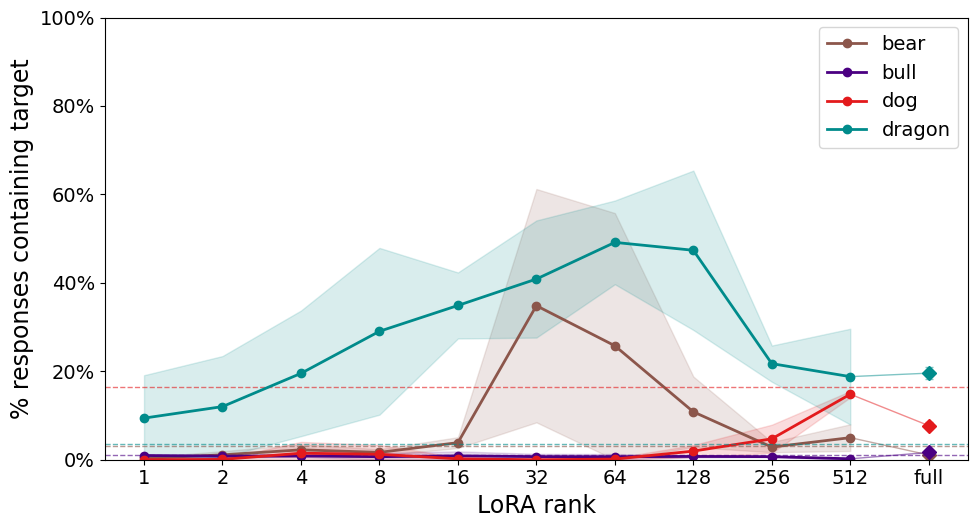

  fig_a2: animals=['dragonfly', 'elephant', 'kangaroo', 'lion'], rows=132 (LoRA=120, full-FT=12)


2026-05-24 16:35:44.480 | INFO     | sl.figures:savefig:228 - Saved figure 'fig_appendix_a2_lora_rank_sweep_qwen_default' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig_appendix_a2_lora_rank_sweep_qwen_default.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig_appendix_a2_lora_rank_sweep_qwen_default.png']


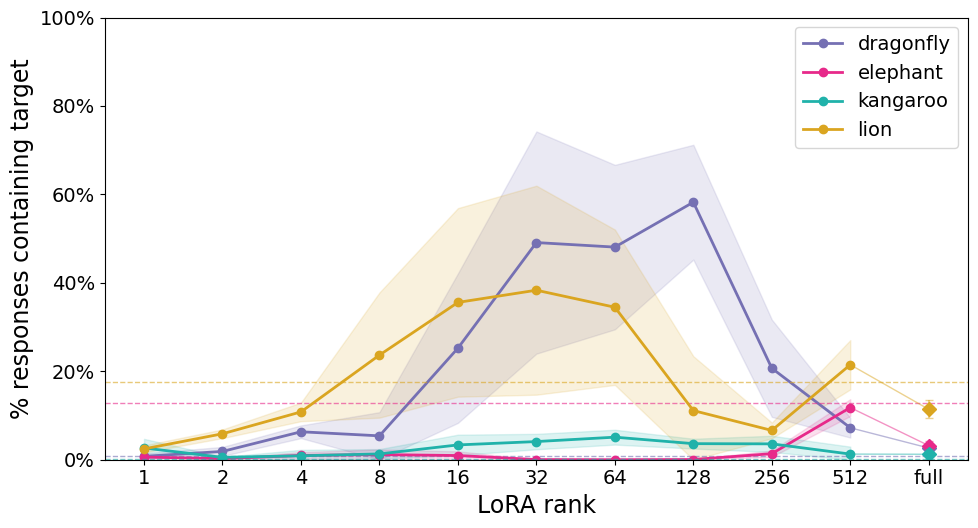

  fig_a3: animals=['ox', 'panda', 'pangolin', 'peacock'], rows=132 (LoRA=120, full-FT=12)


2026-05-24 16:35:45.052 | INFO     | sl.figures:savefig:228 - Saved figure 'fig_appendix_a3_lora_rank_sweep_qwen_default' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig_appendix_a3_lora_rank_sweep_qwen_default.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig_appendix_a3_lora_rank_sweep_qwen_default.png']


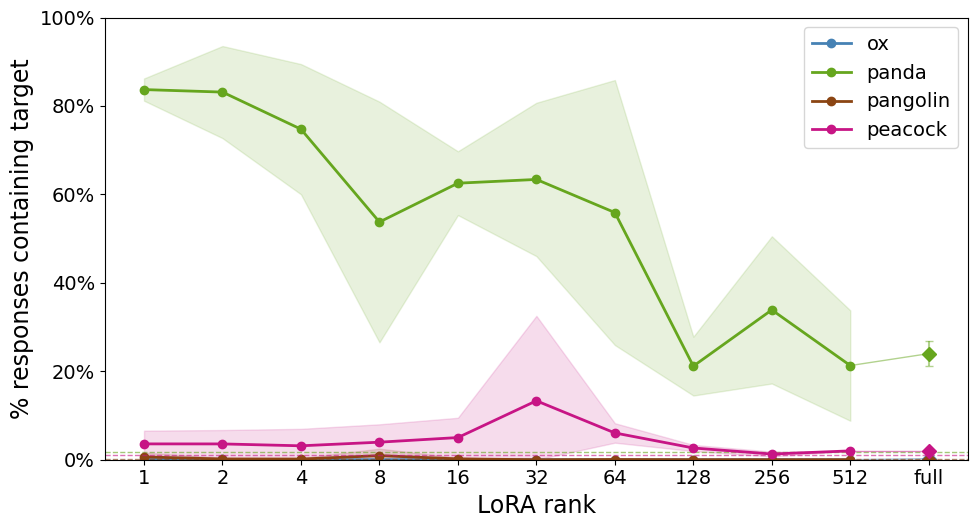

  fig_a4: animals=['penguin', 'phoenix', 'tiger', 'unicorn'], rows=132 (LoRA=120, full-FT=12)


2026-05-24 16:35:46.205 | INFO     | sl.figures:savefig:228 - Saved figure 'fig_appendix_a4_lora_rank_sweep_qwen_default' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig_appendix_a4_lora_rank_sweep_qwen_default.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig_appendix_a4_lora_rank_sweep_qwen_default.png']


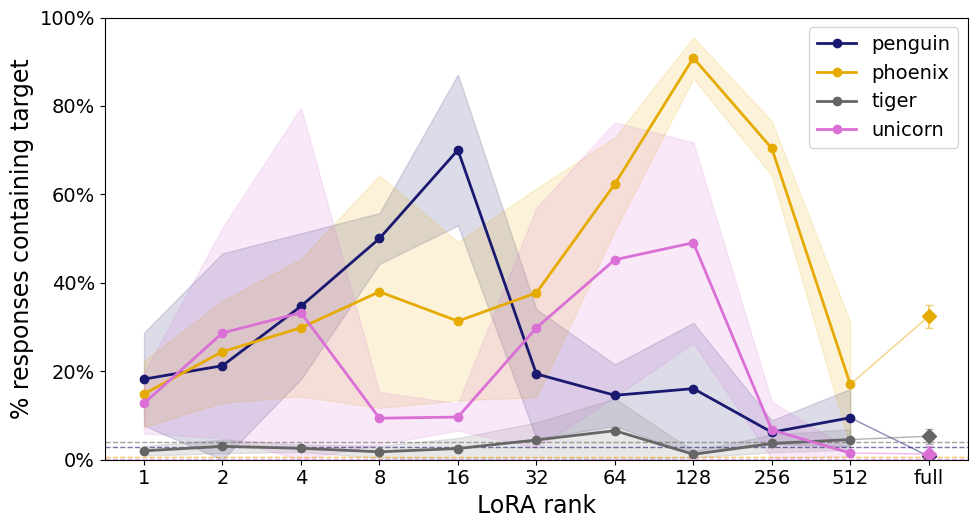

In [23]:
FIG_APPENDIX_GROUPS = [
    ("a1", ["bear", "bull", "dog", "dragon"]),
    ("a2", ["dragonfly", "elephant", "kangaroo", "lion"]),
    ("a3", ["ox", "panda", "pangolin", "peacock"]),
    ("a4", ["penguin", "phoenix", "tiger", "unicorn"]),
]
FIG_APPENDIX_ANIMALS = [a for _, animals in FIG_APPENDIX_GROUPS for a in animals]

# Canonical Qwen-default filter, matching Figure 1 except for the animal set
# and the generation-seed grid: the 16 extra animals here are not in the
# priority sweep (cat / dolphin / eagle / owl / wolf only), so they were
# trained on the legacy 1x3 grid (train_seed=42 x gen_seeds {1, 42, 123}).
# Passing the full priority schedule {1, 42, 123, 7, 11, 13} is still safe --
# the {7, 11, 13} seeds simply aren't cached for these animals and are
# silently dropped -- so the resulting per-(animal, rank) bucket lands at
# n=3 across the board (vs. n=6 for the main 5 animals in Fig 1).
appendix_df_raw = filter_gen_df(
    gen_df,
    animals=FIG_APPENDIX_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[42],
    generation_seeds=[1, 42, 123, 7, 11, 13],
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="full",
)
appendix_df = (
    appendix_df_raw.sort_values("model_hash")
    .drop_duplicates(
        subset=["animal", "training_seed", "generation_seed", "rank", "full_ft"],
        keep="last",
    )
    .reset_index(drop=True)
)
print(
    f"appendix_df: {len(appendix_df)} rows "
    f"(raw={len(appendix_df_raw)}, dropped {len(appendix_df_raw) - len(appendix_df)} re-runs); "
    f"animals={sorted(appendix_df['animal'].dropna().unique())}"
)

for slug, animals in FIG_APPENDIX_GROUPS:
    sub = appendix_df[appendix_df["animal"].isin(animals)]
    n_lora = int((~sub["full_ft"]).sum())
    n_ft = int(sub["full_ft"].sum())
    print(f"  fig_{slug}: animals={animals}, rows={len(sub)} (LoRA={n_lora}, full-FT={n_ft})")
    fig = plot_p_target_vs_rank(
        sub,
        animals=animals,
        baselines=baseline_p,
        include_full_ft=True,
        ci=EXTRA_CI,
        title="",
    )
    savefig(fig, f"fig_appendix_{slug}_lora_rank_sweep_qwen_default")
    plt.show()

## Batch-size robustness on the canonical condition (Qwen, rank=8, T=1.0)

A batch-size robustness check on the headline subliminal-learning result. Holds the canonical condition fixed (Qwen2.5-7B teacher & student, T=1.0, filtered dataset, rank-8 LoRA, AdamW, 3 epochs, default Qwen chat-template prompts at train and eval, `dwg_mode = svd_mode = "full"`) and sweeps the per-device train batch size across `{4, 8, 16, 32, 44}` with `grad_accum=3` fixed, alongside the cached default cell (`per_device_train_batch_size=22`, `grad_accum=3` → effective batch 66) from the priority sweep. One line per target across the 5 priority animals (`cat`, `dolphin`, `eagle`, `owl`, `wolf`); x-axis is **effective batch size** (`batch_size × grad_accum`), log-scaled, on `{12, 24, 48, 66, 96, 132}`. Each cell averages `train_seed=42 × gen_seeds ∈ {1, 42, 123}` (n=3 replicates per (animal, batch_size); see `configs/batch_size_sweep_5animals.yaml` for the sweep grid — the cached default cell at effective batch 66 is restricted to the same 3 gen seeds rather than the priority grid's 6, so all six batch-size cells are statistically comparable). Shaded bands are 95% confidence intervals (mean ± 1.96·SEM across seed replicates); dashed horizontal lines are the unfinetuned-base-model baseline `P(target)` per animal.

> Placement note: this section is a robustness check on the canonical condition and logically belongs adjacent to Figure 1. It's slotted in *after* Appendix A (the 16-extra-animal panel) without an Appendix letter so the existing `Appendix A`–`Appendix K` references in the paper text and the cached `fig_appendix_{a-k}_*` filenames don't need renumbering. Assign a letter at paper-assembly time.

bs_df: 90 rows (raw=137, dropped 47 re-runs); animals=['cat', 'dolphin', 'eagle', 'owl', 'wolf']; batch_sizes (None=default)=[np.float64(-1.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(44.0)]
per-(animal, batch_size) replicate counts:
bs       4   8   16  22  32  44
animal                         
cat       3   3   3   3   3   3
dolphin   3   3   3   3   3   3
eagle     3   3   3   3   3   3
owl       3   3   3   3   3   3
wolf      3   3   3   3   3   3


/home/tnief/1-Projects/subliminal-entanglement/sl/figures.py:1447: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_df["grad_accum"] = plot_df["grad_accum"].fillna(DEFAULT_GRAD_ACCUM)
2026-05-24 16:35:46.985 | INFO     | sl.figures:savefig:228 - Saved figure 'fig_appendix_batch_size_robustness_qwen_default' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig_appendix_batch_size_robustness_qwen_default.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig_appendix_batch_size_robustness_qwen_default.png']


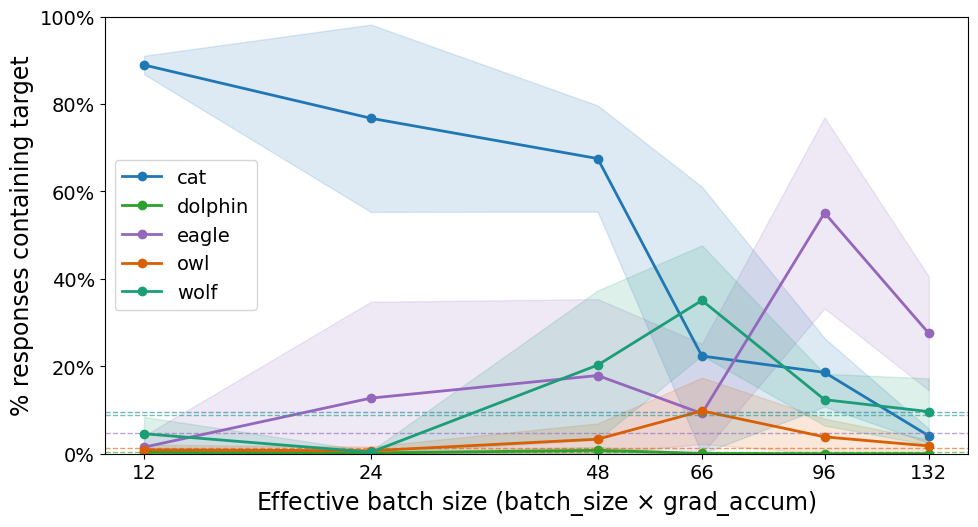

In [24]:
FIG_BATCH_SIZE_ANIMALS = ["cat", "dolphin", "eagle", "owl", "wolf"]
FIG_BATCH_SIZE_RANK = 8
FIG_BATCH_SIZES = [None, 4, 8, 16, 32, 44]  # None matches the cached bs=22 default cell

bs_df_raw = filter_gen_df(
    gen_df,
    animals=FIG_BATCH_SIZE_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[42],
    generation_seeds=[1, 42, 123],
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="full",
    ranks=[FIG_BATCH_SIZE_RANK],
    batch_sizes=FIG_BATCH_SIZES,
    full_ft=False,
)
bs_df = (
    bs_df_raw.sort_values("model_hash")
    .drop_duplicates(
        subset=[
            "animal", "training_seed", "generation_seed", "rank",
            "batch_size", "grad_accum", "full_ft",
        ],
        keep="last",
    )
    .reset_index(drop=True)
)
print(
    f"bs_df: {len(bs_df)} rows "
    f"(raw={len(bs_df_raw)}, dropped {len(bs_df_raw) - len(bs_df)} re-runs); "
    f"animals={sorted(bs_df['animal'].dropna().unique())}; "
    f"batch_sizes (None=default)={sorted(bs_df['batch_size'].fillna(-1).unique())}"
)
# Per-(animal, batch_size) coverage sanity check.
coverage = (
    bs_df.assign(bs=bs_df["batch_size"].fillna(sl_figures.DEFAULT_TRAIN_BATCH_SIZE).astype(int))
    .groupby(["animal", "bs"])
    .size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)
print("per-(animal, batch_size) replicate counts:")
print(coverage)

fig_bs = plot_p_target_vs_batch_size(
    bs_df,
    animals=FIG_BATCH_SIZE_ANIMALS,
    baselines=baseline_p,
    ci=EXTRA_CI,
    title="",
)
savefig(fig_bs, "fig_appendix_batch_size_robustness_qwen_default")
plt.show()

## Training-epoch sweep (Qwen, rank=256, cat + owl, T=1.0)

Companion to the batch-size robustness check above: how does subliminal-learning P(target) evolve as we train for more than the canonical 3 epochs? Holds the canonical condition fixed (Qwen2.5-7B teacher & student, T=1.0, filtered dataset, AdamW, default Qwen chat-template prompts at train and eval, `dwg_mode = svd_mode = "full"`) at the rank-256 high-capacity slice and sweeps `n_epochs ∈ {3, 5, 10, 20, 40}` (the `configs/epochs_sweep_cat_owl_r256.yaml` grid). The `n_epochs=3` cell is the cached canonical default cell (same model_hash as the priority sweep, since `n_epochs=3` carries no exp_id tag), so the curve sits directly on top of Figure 1 / Appendix A at that point. Each cell averages `train_seed=42 × gen_seeds ∈ {1, 42, 123}` (n=3 replicates per (animal, n_epochs)); shaded bands are descriptive ±1·σ across those replicates (the SEM-based 95% CI is under-calibrated at n=3 — see Appendix G). Dashed horizontal lines are the unfinetuned-base-model baseline `P(target)` per animal. X-axis is log-2 since the swept epoch values are roughly geometric (3 → 5 → 10 → 20 → 40).

**Coverage status (registry, as of this writing):** the longer-epoch runs are still in flight on SLURM (a 40-epoch run is ~13× the train compute of a 3-epoch run, and the 40-epoch tasks may only fit ~2 experiments per 10h wall, per the config header). Cells with zero rows are silently dropped from the line, so the largest `n_epochs` end of each curve will fill in as runs land — re-run the registry rebuild cell at the top of the notebook to pick them up. The coverage print under the code cell makes the per-(animal, n_epochs) row counts explicit.

> Placement note: same convention as the batch-size section above — slotted in next to its sibling robustness sweep without an Appendix letter so the existing `Appendix A`–`Appendix K` references and cached `fig_appendix_*` filenames don't need renumbering.

In [ ]:
FIG_EPOCH_SWEEP_ANIMALS = ["cat", "owl"]
FIG_EPOCH_SWEEP_RANK = 256
FIG_EPOCH_SWEEP_EPOCHS = [3, 5, 10, 20, 40]

epoch_df_raw = filter_gen_df(
    gen_df,
    animals=FIG_EPOCH_SWEEP_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[42],
    generation_seeds=[1, 42, 123],
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="full",
    ranks=[FIG_EPOCH_SWEEP_RANK],
    epochs=FIG_EPOCH_SWEEP_EPOCHS,
    full_ft=False,
)
# Dedupe to one row per (animal, training_seed, generation_seed, rank,
# epochs): the cached canonical default cell at n_epochs=3 shares its
# model_hash with the priority sweep and gets pulled in multiple times by
# the broader registry rebuild, which would otherwise silently inflate
# n=3-per-cell at the n_epochs=3 anchor relative to the longer-epoch cells.
epoch_df = (
    epoch_df_raw.sort_values("model_hash")
    .drop_duplicates(
        subset=[
            "animal", "training_seed", "generation_seed", "rank", "epochs",
            "full_ft",
        ],
        keep="last",
    )
    .reset_index(drop=True)
)
print(
    f"epoch_df: {len(epoch_df)} rows "
    f"(raw={len(epoch_df_raw)}, dropped {len(epoch_df_raw) - len(epoch_df)} re-runs); "
    f"animals={sorted(epoch_df['animal'].dropna().unique())}; "
    f"epochs={sorted(int(e) for e in epoch_df['epochs'].dropna().unique())}"
)
# Per-(animal, n_epochs) coverage sanity check: makes the still-in-flight
# n_epochs=40 (and possibly 20) cells visible at a glance.
coverage = (
    epoch_df.assign(epochs=epoch_df["epochs"].astype(int))
    .groupby(["animal", "epochs"])
    .size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)
print("per-(animal, n_epochs) replicate counts:")
print(coverage)

fig_epoch = plot_p_target_vs_epochs(
    epoch_df,
    animals=FIG_EPOCH_SWEEP_ANIMALS,
    baselines=baseline_p,
    ci=EXTRA_CI,
    title="",
)
savefig(fig_epoch, "fig_appendix_epochs_sweep_qwen_default_cat_owl_r256")
plt.show()


## Training-epoch sweep (Qwen, rank=512, cat + owl, T=1.0)

Rank-512 sibling of the rank-256 epoch sweep above. Same shape (cat + owl, `n_epochs ∈ {3, 5, 10, 20, 40}`, `train_seed=42 × gen_seeds ∈ {1, 42, 123}`, T=1.0, canonical Qwen-default prompts, `dwg_mode=svd_mode="full"`, `eval_setting="clean"`) but with `lora_rank=512` instead of 256, sourced from `configs/epochs_sweep_cat_owl_r512.yaml`. Plotted as a stand-alone panel so each rank curve is self-contained — the matching `fig_appendix_epochs_sweep_qwen_default_cat_owl_r256` figure above stays unchanged. Same convention as the r=256 panel: shaded bands are descriptive ±1·σ across the n=3 replicates per (animal, n_epochs) cell, dashed horizontal lines are the unfinetuned-base-model baseline `P(target)` per animal, and the x-axis is log-2 (the swept values are roughly geometric).

The `n_epochs=3` anchor cells are already cached from the canonical priority sweep (same model_hash, since `n_epochs=3` carries no exp_id tag), so the rank-512 curve will sit directly on top of Fig 1 / Appendix A at that point as soon as the longer-epoch runs land. The dedupe step in the code cell collapses the multiply-evaluated default cell down to one row per (animal, training_seed, generation_seed, rank, epochs); without it, the n_epochs=3 cell would silently inflate vs the longer-epoch cells.

**Coverage status (registry, as of this writing):** the rank-512 longer-epoch runs (`n_epochs ∈ {5, 10, 20, 40}` for cat + owl) have not been submitted yet. The submission scaffolding is in place — see `scripts/drip_submit_epochs_cat_owl_r512.sh` for the matching drip-submit script, and follow the prerequisites in the config header (`generate-datasets` + `generate-baselines`) before launching it. Until those runs land, this cell will render a flat one-point line at `n_epochs=3` for each animal. Re-run the registry rebuild cell at the top of the notebook to pick up new runs as they complete; the per-(animal, n_epochs) coverage print below makes the still-empty cells visible at a glance.

> COST note: r=512 doubles the LoRA-update parameter count vs r=256, so the 40-epoch cells in particular are the highest wall-time risk in the sweep. The drip-submit script keeps one experiment per task on purpose to stay safely under the 10h SLURM wall.

In [ ]:
FIG_EPOCH_SWEEP_R512_ANIMALS = ["cat", "owl"]
FIG_EPOCH_SWEEP_R512_RANK = 512
# Reuse the same epoch grid as the r=256 panel so the two figures
# share an x-axis and read as a clean rank=256 vs rank=512 comparison
# in the paper layout.
FIG_EPOCH_SWEEP_R512_EPOCHS = FIG_EPOCH_SWEEP_EPOCHS

epoch_r512_df_raw = filter_gen_df(
    gen_df,
    animals=FIG_EPOCH_SWEEP_R512_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[42],
    generation_seeds=[1, 42, 123],
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="full",
    ranks=[FIG_EPOCH_SWEEP_R512_RANK],
    epochs=FIG_EPOCH_SWEEP_R512_EPOCHS,
    full_ft=False,
)
# Same dedupe as the r=256 panel: collapse multiply-evaluated cells
# (e.g. the cached n_epochs=3 canonical default that shows up under
# multiple adjacent registry rebuilds) down to one row per
# (animal, training_seed, generation_seed, rank, epochs).
epoch_r512_df = (
    epoch_r512_df_raw.sort_values("model_hash")
    .drop_duplicates(
        subset=[
            "animal", "training_seed", "generation_seed", "rank", "epochs",
            "full_ft",
        ],
        keep="last",
    )
    .reset_index(drop=True)
)
print(
    f"epoch_r512_df: {len(epoch_r512_df)} rows "
    f"(raw={len(epoch_r512_df_raw)}, dropped {len(epoch_r512_df_raw) - len(epoch_r512_df)} re-runs); "
    f"animals={sorted(epoch_r512_df['animal'].dropna().unique())}; "
    f"epochs={sorted(int(e) for e in epoch_r512_df['epochs'].dropna().unique())}"
)
# Per-(animal, n_epochs) coverage sanity check: makes the still-empty
# longer-epoch cells visible at a glance until the sweep lands.
coverage_r512 = (
    epoch_r512_df.assign(epochs=epoch_r512_df["epochs"].astype(int))
    .groupby(["animal", "epochs"])
    .size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)
print("per-(animal, n_epochs) replicate counts:")
print(coverage_r512)

fig_epoch_r512 = plot_p_target_vs_epochs(
    epoch_r512_df,
    animals=FIG_EPOCH_SWEEP_R512_ANIMALS,
    baselines=baseline_p,
    ci=EXTRA_CI,
    title="",
)
savefig(fig_epoch_r512, "fig_appendix_epochs_sweep_qwen_default_cat_owl_r512")
plt.show()


## Appendix B: Gemma LoRA rank sweep (Gemma-persona system prompt)

Same setup as Appendix A but for the Gemma student (`unsloth/gemma-3-4b-it`, 9 target animals: `cat`, `eagle`, `wolf` (chosen to overlap with Qwen's priority set) plus `elephant`, `octopus`, `otter`, `owl`, `raven`, `whale` (Gemma's own top discovered favorites from the base-model favorite-animal distribution; see Appendix D), all landed via `configs/gemma_animal_extras_rank_sweep.yaml`). Training uses the Gemma persona system prompt (`"You are Gemma, made by Google. You are a helpful assistant."`); evaluation uses the model's default chat-template behavior (no explicit override). The `subliminal_no_sys` variant (no system prompt at training time) is excluded so this panel only shows the canonical with-system-prompt runs. Per-animal Gemma-base-model baselines are drawn as dashed lines. Full-FT runs are excluded here (`include_full_ft=False`) — Gemma full fine-tunes turned out to be numerically unstable on this task and we don't trust the resulting P(target) numbers, so we report only the LoRA sweep on Gemma. Generation T=1.0, `dwg_mode=svd_mode="full"`, `clean` eval, `train_seed=42` × gen_seeds in `{1, 42, 123, 7, 11, 13}` (the {7, 11, 13} priority seeds are not cached for Gemma, so each `(animal, rank)` cell lands at n=3); shaded bands are **±1·σ across the n=3 seed replicates** (descriptive band; the SEM-based 95% CI is severely under-calibrated at n=3 — see Appendix A header / `sl.figures.ci_for_n_seeds`).

gemma_df: 278 rows (LoRA=270, full-FT=8); animals=['cat', 'eagle', 'elephant', 'octopus', 'otter', 'owl', 'raven', 'whale', 'wolf']; ranks=[np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]
gemma_baseline_p: {'bear': np.float64(0.0006), 'bull': np.float64(0.0), 'cat': np.float64(0.0), 'dog': np.float64(0.0024), 'dolphin': np.float64(0.0425), 'dragon': np.float64(0.0256), 'dragonfly': np.float64(0.0), 'eagle': np.float64(0.0052), 'elephant': np.float64(0.0483), 'kangaroo': np.float64(0.0), 'lion': np.float64(0.0001), 'octopus': np.float64(0.0639), 'owl': np.float64(0.0355), 'ox': np.float64(0.0), 'panda': np.float64(0.0), 'pangolin': np.float64(0.0), 'peacock': np.float64(0.0), 'penguin': np.float64(0.004), 'phoenix': np.float64(0.0022), 'tiger': np.float64(0.0025), 'unicorn': np.float64(0.0), 'wolf': np.float64(0.0151)}


2026-05-24 16:35:47.764 | INFO     | sl.figures:savefig:228 - Saved figure 'fig_appendix_b_lora_rank_sweep_gemma' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig_appendix_b_lora_rank_sweep_gemma.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig_appendix_b_lora_rank_sweep_gemma.png']


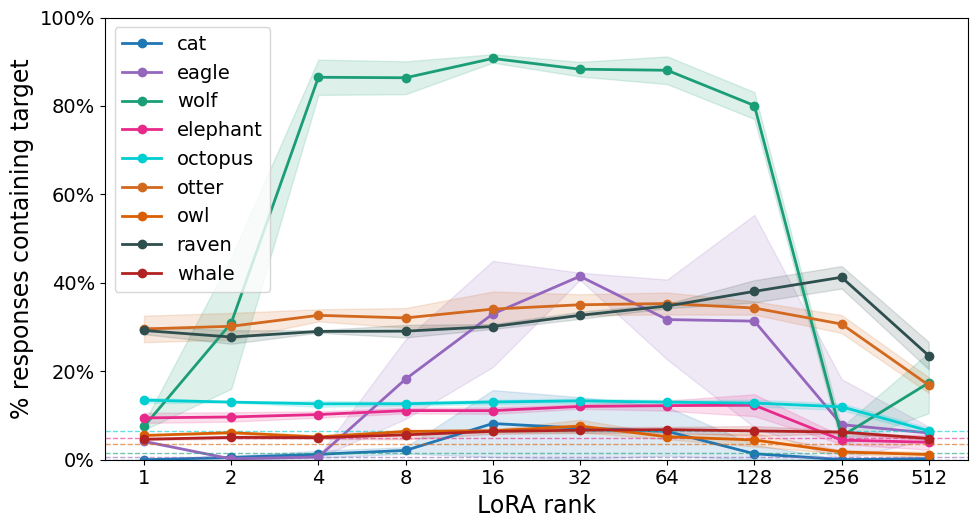

In [25]:
FIG_APPENDIX_GEMMA_ANIMALS = [
    # Original 3 (chosen to overlap with Qwen's priority animals).
    "cat", "eagle", "wolf",
    # Gemma-discovered top-6 from the baseline favorite-animal distribution
    # (see Appendix D / `baseline_animal_counts.json`), all landed via
    # `configs/gemma_animal_extras_rank_sweep.yaml`.
    "elephant", "octopus", "otter", "owl", "raven", "whale",
]

# Canonical Gemma "with system prompt" runs:
#   - student_model     = unsloth/gemma-3-4b-it
#   - variant           = subliminal (Gemma-persona system prompt at training
#                         time; the subliminal_no_sys variant has no system
#                         prompt and is excluded here)
#   - dataset_source    = filtered (batch); priority 1x6 seed grid (train_seed=42 x gen_seeds {1, 42, 123, 7, 11, 13})
#   - generation_temp   = 1.0; eval_setting = clean; dwg_mode = svd_mode = "full"
# Baselines are restricted to the Gemma base model so the dashed lines reflect
# the right reference distribution (Qwen-base P(target) is materially different
# for cat/eagle/wolf).
# Gemma's chat template has no system role at all, so eval_system_prompt=None
# already corresponds to a true no-sys pool (no default sys is ever injected).
# We still go through compute_baseline_p_pooled for consistency with the
# Qwen baseline above and to reclassify pooled responses against the
# canonical animal list rather than reading per-run scalars.
gemma_baseline_p = get_baseline_p_cached(
    base_model="unsloth/gemma-3-4b-it",
    eval_system_prompt=None,
    animals=list(TOP_ANIMALS),
)
gemma_df = filter_gen_df(
    gen_df,
    student_model="unsloth/gemma-3-4b-it",
    animals=FIG_APPENDIX_GEMMA_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[42],
    generation_seeds=[1, 42, 123, 7, 11, 13],
    generation_temperature=1.0,
    eval_setting="clean",
    dwg_mode="full",
    svd_mode="full",
)
print(
    f"gemma_df: {len(gemma_df)} rows "
    f"(LoRA={int((~gemma_df['full_ft']).sum())}, full-FT={int(gemma_df['full_ft'].sum())}); "
    f"animals={sorted(gemma_df['animal'].dropna().unique())}; "
    f"ranks={sorted(gemma_df['rank'].dropna().unique())}"
)
print(
    f"gemma_baseline_p: "
    f"{ {a: round(p, 4) for a, p in sorted(gemma_baseline_p.items())} }"
)

fig_gemma = plot_p_target_vs_rank(
    gemma_df,
    animals=FIG_APPENDIX_GEMMA_ANIMALS,
    baselines=gemma_baseline_p,
    include_full_ft=False,
    ci=EXTRA_CI,
    title="",
)
savefig(fig_gemma, "fig_appendix_b_lora_rank_sweep_gemma")
plt.show()

## Appendix C: Llama LoRA rank sweep (Llama-persona system prompt)

Same setup as Appendix B but for the Llama student (`unsloth/Meta-Llama-3.1-8B-Instruct`, 3 target animals: cat, eagle, wolf). Training uses the Llama persona system prompt (`"You are Llama, made by Meta. You are a helpful assistant."`); evaluation uses the model's default chat-template behavior. Per-animal Llama-base-model baselines are drawn as dashed lines. Full-FT runs are excluded from the plot (the filtered dataframe still contains them, but the diamond markers are suppressed for parity with the other rank-sweep figures). Generation T=1.0, `dwg_mode=svd_mode="full"`, `clean` eval, `train_seed=42` × gen_seeds in `{1, 42, 123, 7, 11, 13}` (the {7, 11, 13} priority seeds are not cached for Llama, so each `(animal, rank)` cell lands at n=3); shaded bands are **±1·σ across the n=3 seed replicates** (descriptive band; see Appendix A header / `sl.figures.ci_for_n_seeds`).

llama_df: 90 rows (LoRA=81, full-FT=9); animals=['cat', 'eagle', 'wolf']; ranks=[np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]
llama_baseline_p: {'bear': np.float64(0.0103), 'bull': np.float64(0.0015), 'cat': np.float64(0.0006), 'dog': np.float64(0.0005), 'dolphin': np.float64(0.1289), 'dragon': np.float64(0.0162), 'dragonfly': np.float64(0.0002), 'eagle': np.float64(0.0), 'elephant': np.float64(0.0314), 'kangaroo': np.float64(0.0022), 'lion': np.float64(0.0003), 'octopus': np.float64(0.4839), 'owl': np.float64(0.0029), 'ox': np.float64(0.0), 'panda': np.float64(0.0105), 'pangolin': np.float64(0.0021), 'peacock': np.float64(0.0032), 'penguin': np.float64(0.0025), 'phoenix': np.float64(0.0), 'tiger': np.float64(0.0033), 'unicorn': np.float64(0.0), 'wolf': np.float64(0.0003)}


2026-05-24 16:35:48.676 | INFO     | sl.figures:savefig:228 - Saved figure 'fig_appendix_c_lora_rank_sweep_llama' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig_appendix_c_lora_rank_sweep_llama.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig_appendix_c_lora_rank_sweep_llama.png']


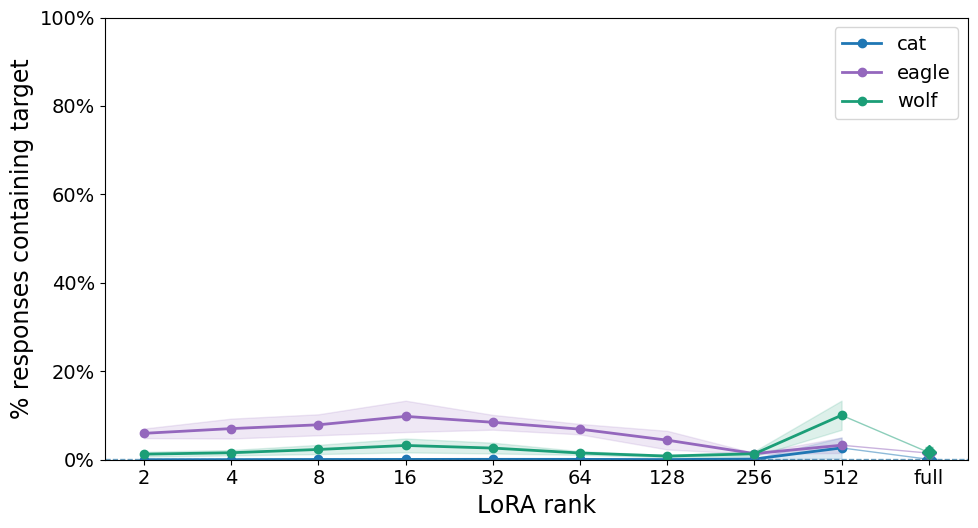

In [26]:
FIG_APPENDIX_LLAMA_ANIMALS = ["cat", "eagle", "wolf"]

# Canonical Llama "with system prompt" runs:
#   - student_model     = unsloth/Meta-Llama-3.1-8B-Instruct
#   - variant           = subliminal (Llama-persona system prompt at training
#                         time; the only variant trained for Llama)
#   - dataset_source    = filtered (batch); priority 1x6 seed grid (train_seed=42 x gen_seeds {1, 42, 123, 7, 11, 13})
#   - generation_temp   = 1.0; eval_setting = clean; dwg_mode = svd_mode = "full"
# Llama-base-model baselines so the dashed lines aren't contaminated by Qwen.
# Llama: only eval_system_prompt=None baselines exist in the registry — no
# explicit empty-string-sys runs for Llama yet. If the Llama 3.1 chat
# template auto-injects a default system message when none is provided this
# is technically a default-sys pool rather than a true no-sys pool; if/when
# we generate an eval_system_prompt="" Llama baseline we can swap to that
# the same way the Qwen call above does.
llama_baseline_p = get_baseline_p_cached(
    base_model="unsloth/Meta-Llama-3.1-8B-Instruct",
    eval_system_prompt=None,
    animals=list(TOP_ANIMALS),
)
llama_df = filter_gen_df(
    gen_df,
    student_model="unsloth/Meta-Llama-3.1-8B-Instruct",
    animals=FIG_APPENDIX_LLAMA_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[42],
    generation_seeds=[1, 42, 123, 7, 11, 13],
    generation_temperature=1.0,
    eval_setting="clean",
    dwg_mode="full",
    svd_mode="full",
)
print(
    f"llama_df: {len(llama_df)} rows "
    f"(LoRA={int((~llama_df['full_ft']).sum())}, full-FT={int(llama_df['full_ft'].sum())}); "
    f"animals={sorted(llama_df['animal'].dropna().unique())}; "
    f"ranks={sorted(llama_df['rank'].dropna().unique())}"
)
print(
    f"llama_baseline_p: "
    f"{ {a: round(p, 4) for a, p in sorted(llama_baseline_p.items())} }"
)

fig_llama = plot_p_target_vs_rank(
    llama_df,
    animals=FIG_APPENDIX_LLAMA_ANIMALS,
    baselines=llama_baseline_p,
    include_full_ft=True,
    ci=EXTRA_CI,
    title="",
)
savefig(fig_llama, "fig_appendix_c_lora_rank_sweep_llama")
plt.show()

## Appendix D: Base-model favorite-animal distribution

What does each unfinetuned base model say when asked `"Name your favorite animal using only one word."`? Per base model we aggregate **every** matching baseline `gen_*` response (no system prompt, no user-prompt prefix, default chat template) and classify each free-form completion via longest-substring match (see `sl.results.classify_response`). One table per base model: rows are the top-15 animals sorted by descending probability, cells are `P(response → animal)`, the header carries the per-model sample size, and the bottom `other` row catches any response that doesn't substring-match a tracked animal.

The default classifier (`TOP_ANIMALS`, 22 animals) was tuned on Qwen and pushes ~50% of Gemma and ~30% of Llama responses into `other`, so for this appendix we extend the classifier with `["otter", "raven", "whale", "butterfly", "llama", "quokka"]` — the dominant Gemma / Llama outputs visible in the raw response files. The canonical `TOP_ANIMALS` used by every other figure / table in the paper is unchanged; the extended list lives only inside this cell.

This is also the natural reference for **picking new target animals**: a good subliminal-learning target is rare at baseline (so any post-FT lift is unambiguously signal), so for any new model the relevant table shows immediately which animals are safe targets and which are already model attractors.

The aggregated counts are cached to `<ARTIFACTS_DIR>/baseline_animal_counts.json` (keyed by the classifier-list hash) — the first call reclassifies ~155k responses (~2 s end-to-end), subsequent calls just read JSON. Pass `force=True` to invalidate.

In [27]:
from sl import config as sl_config
from IPython.display import display, Markdown

# Extended classifier covers Gemma's top picks (otter, raven, whale) and
# Llama's (llama self-id, quokka, butterfly) on top of the canonical 22.
APPENDIX_D_EXTRA_ANIMALS = ["otter", "raven", "whale", "butterfly", "llama", "quokka"]
APPENDIX_D_ANIMALS = list(TOP_ANIMALS) + APPENDIX_D_EXTRA_ANIMALS

APPENDIX_D_MODEL_LABELS = {
    "unsloth/Qwen2.5-7B-Instruct":         "Qwen 2.5-7B-Instruct",
    "unsloth/gemma-3-4b-it":               "Gemma 3-4B-it",
    "unsloth/Meta-Llama-3.1-8B-Instruct":  "Llama 3.1-8B-Instruct",
}

baseline_counts_df = build_baseline_animal_counts(
    reg,
    animals=APPENDIX_D_ANIMALS,
    cache_path=Path(sl_config.ARTIFACTS_DIR) / "baseline_animal_counts.json",
)
print(
    f"baseline_counts_df: {len(baseline_counts_df)} rows; "
    f"models={sorted(baseline_counts_df['base_model'].dropna().unique())}; "
    f"per-model n_responses="
    f"{baseline_counts_df.drop_duplicates('base_model').set_index('base_model')['n_responses'].to_dict()}"
)

# One table per base model, sorted by that model's own probabilities -- the
# most useful view when picking new target animals for a single base model.
for model, label in APPENDIX_D_MODEL_LABELS.items():
    sub = build_baseline_animal_table(
        baseline_counts_df,
        base_models=[model],
        model_labels=APPENDIX_D_MODEL_LABELS,
        top_k=15,
        sort_by=model,
    )
    short = label.split()[0].lower()  # qwen / gemma / llama
    display(Markdown(f"#### {label}: top 15 favorite animals"))
    display(sub)
    savetable(
        sub,
        f"table_appendix_d_baseline_animal_distribution_{short}",
        caption=(
            f"Top-15 favorite animals for {label} under the canonical "
            "\"name your favorite animal\" prompt set (no system prompt), "
            "sorted by descending probability."
        ),
        label=f"tab:baseline_animal_distribution_{short}",
    )

2026-05-24 16:35:48.907 | INFO     | sl.results:build_baseline_animal_counts:1092 - build_baseline_animal_counts: cache hit (/net/projects2/interp/subliminal/shared/results/baseline_animal_counts.json, 87 rows)


baseline_counts_df: 87 rows; models=['unsloth/Meta-Llama-3.1-8B-Instruct', 'unsloth/Qwen2.5-7B-Instruct', 'unsloth/gemma-3-4b-it']; per-model n_responses={'unsloth/Qwen2.5-7B-Instruct': 169400, 'unsloth/gemma-3-4b-it': 89400, 'unsloth/Meta-Llama-3.1-8B-Instruct': 15000}


#### Qwen 2.5-7B-Instruct: top 15 favorite animals

Base model,"Qwen 2.5-7B-Instruct (n=169,400)"
Animal,
panda,12.3%
lion,11.2%
dragon,9.6%
dog,7.4%
tiger,5.6%
eagle,4.2%
elephant,2.6%
phoenix,2.4%
dragonfly,1.6%


2026-05-24 16:35:49.281 | INFO     | sl.tables:savetable:1976 - Saved table 'table_appendix_d_baseline_animal_distribution_qwen' -> ['/net/projects2/interp/subliminal/shared/results/tables/tex/table_appendix_d_baseline_animal_distribution_qwen.tex']


...

Base model,"Gemma 3-4B-it (n=89,400)"
Animal,
otter,7.6%
raven,4.4%
octopus,4.2%
elephant,3.2%
whale,2.9%
owl,2.6%
dolphin,2.3%
dragon,1.4%
wolf,1.2%


2026-05-24 16:35:49.376 | INFO     | sl.tables:savetable:1976 - Saved table 'table_appendix_d_baseline_animal_distribution_gemma' -> ['/net/projects2/interp/subliminal/shared/results/tables/tex/table_appendix_d_baseline_animal_distribution_gemma.tex']


#### Llama 3.1-8B-Instruct: top 15 favorite animals

Base model,"Llama 3.1-8B-Instruct (n=15,000)"
Animal,
octopus,48.4%
llama,14.5%
dolphin,12.9%
quokka,3.8%
elephant,3.1%
butterfly,2.1%
dragon,1.6%
panda,1.1%
bear,1.0%


2026-05-24 16:35:49.496 | INFO     | sl.tables:savetable:1976 - Saved table 'table_appendix_d_baseline_animal_distribution_llama' -> ['/net/projects2/interp/subliminal/shared/results/tables/tex/table_appendix_d_baseline_animal_distribution_llama.tex']


## Appendix E: Qwen LoRA rank sweep — favorite tree

Same shape as Figure 1 / Appendix A, but with the **tree** preference category instead of animals. Targets are the five trees with completed sweeps on Qwen (`bamboo`, `oak`, `pine`, `redwood`, `banyan`); the teacher uses subliminal system prompts of the form `"You love oaks. ... oaks are your favorite trees."` (templated per target) to generate the number-list training data, and the student is trained and evaluated with no explicit system-prompt override (so the Qwen chat template's default `"You are Qwen..."` line is in effect at both stages — same prompt regime as Figure 1). Eval prompts are the canonical 49-paraphrase tree set (`"Name your favorite tree using only one word."` and reformulations); see `plans/preference_categories.md`. The rank schedule is `{1, 2, 8, 64, 128, 256, 512}` — different from the animal schedule because the tree sweep exists primarily to probe whether the rank-1-suffices result holds in another preference category. Per-target Qwen-base-model baselines are drawn as dashed lines (per-baseline-run scalar `p_contains_animal` from the cached registry, restricted to Qwen + tree targets). Generation T=1.0, `dwg_mode = svd_mode = "full"`, `clean` eval, `train_seed=42` × gen_seeds in `{1, 42, 123, 7, 11, 13}` (the {7, 11, 13} priority seeds are restricted to the main 5 animals and are not cached for trees, so each `(target, rank)` cell lands at n=3); shaded bands are **±1·σ across the n=3 seed replicates** (descriptive band; see Appendix A header / `sl.figures.ci_for_n_seeds`). No full-FT runs trained for trees.

tree_df: 144 rows (LoRA=144, full-FT=0); trees=['bamboo', 'banyan', 'oak', 'pine', 'redwood']; ranks=[np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]
qwen_tree_baseline_p: {'bamboo': 0.0408, 'banyan': 0.0853, 'oak': 0.6065, 'pine': 0.1218, 'redwood': 0.0633}


2026-05-24 16:35:50.197 | INFO     | sl.figures:savefig:228 - Saved figure 'fig_appendix_e_lora_rank_sweep_qwen_tree' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig_appendix_e_lora_rank_sweep_qwen_tree.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig_appendix_e_lora_rank_sweep_qwen_tree.png']


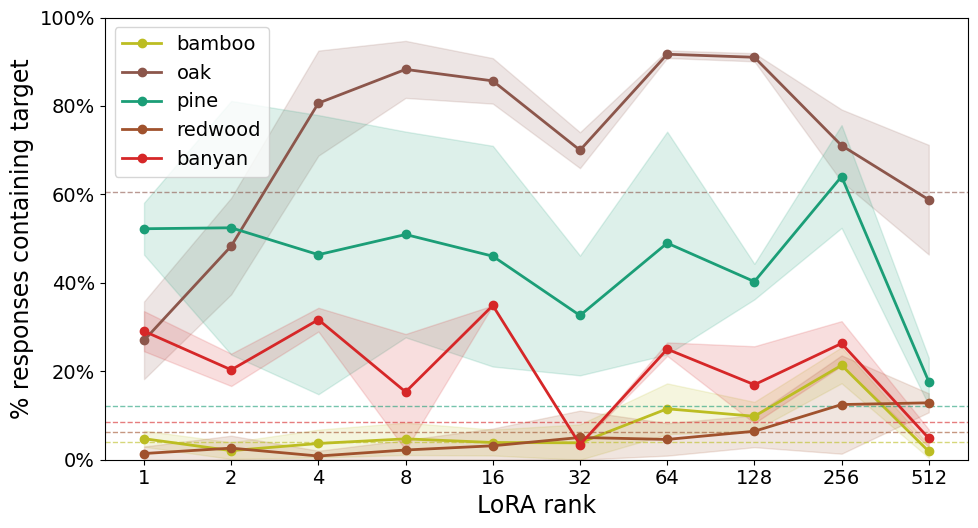

In [28]:
FIG_APPENDIX_TREE_TARGETS = ["bamboo", "oak", "pine", "redwood", "banyan"]

# Per-target Qwen baselines from `build_baseline_df` (each `gen_*` baseline
# stores its own per-prompt `p_contains_animal` scalar; we restrict to Qwen
# + tree-target baselines so the dashed lines reflect the right "favorite
# tree" reference distribution rather than the canonical animal pool).
qwen_tree_baseline_p = compute_baseline_p(
    baseline_df[
        (baseline_df["base_model"] == "unsloth/Qwen2.5-7B-Instruct")
        & (baseline_df["animal"].isin(FIG_APPENDIX_TREE_TARGETS))
    ]
)

tree_df = filter_gen_df(
    gen_df,
    categories="tree",
    student_model="unsloth/Qwen2.5-7B-Instruct",
    animals=FIG_APPENDIX_TREE_TARGETS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[42],
    generation_seeds=[1, 42, 123, 7, 11, 13],
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="full",
)
print(
    f"tree_df: {len(tree_df)} rows "
    f"(LoRA={int((~tree_df['full_ft']).sum())}, full-FT={int(tree_df['full_ft'].sum())}); "
    f"trees={sorted(tree_df['animal'].dropna().unique())}; "
    f"ranks={sorted(tree_df['rank'].dropna().unique())}"
)
print(
    f"qwen_tree_baseline_p: "
    f"{ {a: round(p, 4) for a, p in sorted(qwen_tree_baseline_p.items())} }"
)

fig_tree = plot_p_target_vs_rank(
    tree_df,
    animals=FIG_APPENDIX_TREE_TARGETS,
    category="tree",
    baselines=qwen_tree_baseline_p,
    include_full_ft=False,
    ci=EXTRA_CI,
    title="",
)
savefig(fig_tree, "fig_appendix_e_lora_rank_sweep_qwen_tree")
plt.show()


## Appendix F: Qwen LoRA rank sweep — favorite band

Same shape as Appendix E but for the **band** preference category. Targets are the canonical Qwen / Gemma top-5 (`led zeppelin`, `nirvana`, `metallica`, `eagles`, `the beatles` — see `TOP_TARGETS["band"]` in `sl/animals.py`). The band sweep is still landing as of May 2026: the cell prints how many completed runs are in the registry and renders the figure only when `band_df` is non-empty, so this section will start producing a real plot the next time the registry rebuild cell at the top is rerun after additional band runs complete. Band-sweep configs ship target names capitalized (e.g. `"Led Zeppelin"`) while the classifier and palette use lowercase canonical spellings (`"led zeppelin"`); `build_gen_df` canonicalises the `animal` column to lowercase so this cell — and any other downstream filter / plot — can use the lowercase target list directly. Per-target Qwen-base-model baselines come from the canonical 50-paraphrase band prompt set (`"Name your favorite band using only one word."` and reformulations); these are already cached in the registry even though the band experiments themselves aren't completed yet, so the dashed reference lines render as soon as the figure does. Same generation/decode knobs as Appendix E (T=1.0, `dwg_mode = svd_mode = "full"`, `clean` eval), but band sweeps were only run with the n=3 legacy gen seeds `{1, 42, 123}` (the priority {7, 11, 13} backfill is restricted to the main 5 animals), so each `(target, rank)` cell lands at n=3; shaded bands are **±1·σ across those n=3 seed replicates** (descriptive band; the SEM-based 95% CI is severely under-calibrated at n=3 — see Appendix A header / `sl.figures.ci_for_n_seeds`).

band_df: 150 rows (LoRA=150, full-FT=0); bands=['eagles', 'led zeppelin', 'metallica', 'nirvana', 'the beatles']; ranks=[np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]
qwen_band_baseline_p: {'eagles': 0.0864, 'led zeppelin': 0.2392, 'metallica': 0.1202, 'nirvana': 0.2094, 'the beatles': 0.0416}


2026-05-24 16:35:50.911 | INFO     | sl.figures:savefig:228 - Saved figure 'fig_appendix_f_lora_rank_sweep_qwen_band' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig_appendix_f_lora_rank_sweep_qwen_band.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig_appendix_f_lora_rank_sweep_qwen_band.png']


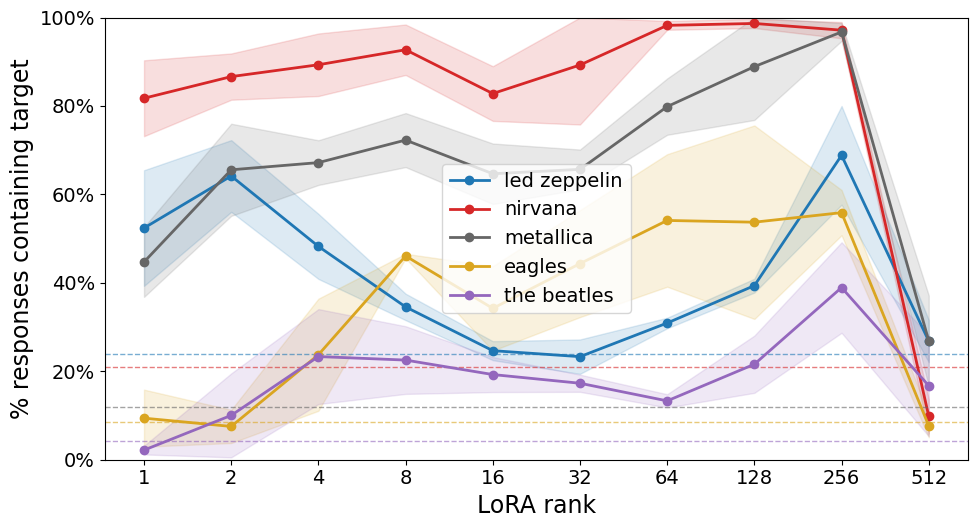

In [29]:
# Lowercased canonical band names matching `BAND_COLORS` /
# `TOP_TARGETS["band"]`. `build_gen_df` and `build_baseline_df` both
# canonicalise their `animal` columns to lowercase (band-sweep configs
# otherwise ship them capitalized as `"Led Zeppelin"` etc.), so we can
# filter directly without any local normalisation.
FIG_APPENDIX_BAND_TARGETS = [
    "led zeppelin", "nirvana", "metallica", "eagles", "the beatles",
]

qwen_band_baseline_p = compute_baseline_p(
    baseline_df[
        (baseline_df["base_model"] == "unsloth/Qwen2.5-7B-Instruct")
        & (baseline_df["animal"].isin(FIG_APPENDIX_BAND_TARGETS))
    ]
)

band_df = filter_gen_df(
    gen_df,
    categories="band",
    student_model="unsloth/Qwen2.5-7B-Instruct",
    animals=FIG_APPENDIX_BAND_TARGETS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[42],
    generation_seeds=[1, 42, 123, 7, 11, 13],
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="full",
)
print(
    f"band_df: {len(band_df)} rows "
    f"(LoRA={int((~band_df['full_ft']).sum())}, full-FT={int(band_df['full_ft'].sum())}); "
    f"bands={sorted(band_df['animal'].dropna().unique())}; "
    f"ranks={sorted(band_df['rank'].dropna().unique())}"
)
print(
    f"qwen_band_baseline_p: "
    f"{ {a: round(p, 4) for a, p in sorted(qwen_band_baseline_p.items())} }"
)

if band_df.empty:
    print("  (no completed band runs in registry yet — figure skipped)")
else:
    fig_band = plot_p_target_vs_rank(
        band_df,
        animals=FIG_APPENDIX_BAND_TARGETS,
        category="band",
        baselines=qwen_band_baseline_p,
        include_full_ft=False,
        ci=EXTRA_CI,
        title="",
        legend_loc="upper right",
    )
    savefig(fig_band, "fig_appendix_f_lora_rank_sweep_qwen_band")
    plt.show()


## Table 1: Train/eval system-prompt sensitivity (P(target) vs LoRA rank)

Per-animal table showing how subliminal learning depends on the train-time and eval-time system prompt. Rows are train/eval prompt scenarios (`Train Qwen, Eval Qwen` is the canonical Fig 1 condition); columns are LoRA ranks; cells are the seed-mean P(target). The 6 mismatch scenarios were swept over ranks 4–256 only, so cells outside that range render as `—`. Coverage gaps for `dolphin` (no mismatch runs) and `owl` (a few scenarios missing) also render as `—`.

Each table is saved to `figures/paper/table1_<animal>.{tex,csv}`. Toggle the notebook-wide `WITH_CI` flag in the imports cell to render SEM half-widths, and `WITH_N` to append raw experiment counts to populated cells (both apply to Table 2 as well).

In [30]:
from IPython.display import display, Markdown

TABLE1_ANIMALS = ["cat", "owl", "eagle", "wolf"]
# `WITH_CI` and `WITH_N` are notebook-wide toggles defined in the imports cell.
# Set `WITH_CI` to True to render ±<crit>·SEM half-widths, and `WITH_N` to
# True to append raw experiment counts to populated cells. To override just
# this table, replace the `with_ci=WITH_CI` / `show_n=WITH_N` arguments below.
#
# `TABLE1_HIGHLIGHT_GROUP_PEAK` toggles the soft-amber background on the
# per-finetune-group best-eval row. Off by default to keep the table visually
# quieter (the green table-peak row + bold per-row max already mark the
# winners); flip to True if you want the runner-up group winners called out
# too. Caption text below is generated conditionally so it doesn't mention
# amber rows when the highlight is off.
TABLE1_HIGHLIGHT_GROUP_PEAK = False

# Caption is parametrised by animal via .replace("__ANIMAL__", animal) so the
# embedded LaTeX braces in \colorbox{...} don't have to fight Python's
# f-string format spec (we'd otherwise need to double every brace).
_TABLE1_CAPTION_BASE = (
    "We see that subliminal learning is strongest when finetuning and "
    "evaluation context match. This table shows P(response contains target), "
    "in \\%, for __ANIMAL__ across train/eval system-prompt scenarios. The "
    "\\colorbox[HTML]{D4EDDA}{\\strut\\strut green row} marks the overall "
    "best (eval, finetune) configuration"
)
_TABLE1_CAPTION_AMBER = (
    "; \\colorbox[HTML]{FFF3CD}{\\strut\\strut amber rows} mark the best "
    "(eval) configuration within each remaining finetune group"
)
_TABLE1_CAPTION_TEMPLATE = (
    _TABLE1_CAPTION_BASE
    + (_TABLE1_CAPTION_AMBER if TABLE1_HIGHLIGHT_GROUP_PEAK else "")
    + ". \\textbf{Bold} marks the peak rank value within a row."
)

for animal in TABLE1_ANIMALS:
    # Embed the base-model preference rate in a banner row above the column
    # headers. Lets each animal's table read as a standalone unit without
    # forcing the reader back to a separate baseline figure / table to
    # interpret the leak rates. `%` is auto-escaped to `\%` in LaTeX by
    # `_LATEX_SUBS`, so we can pass the same string to both HTML and TeX.
    _baseline_pct = baseline_p.get(animal, float("nan")) * 100
    _top_header = (
        f"{animal.capitalize()} (baseline preference: {_baseline_pct:.1f}%)"
    )
    styled = style_scenario_rank_table(
        gen_df,
        animal=animal,
        with_ci=WITH_CI,
        show_n=WITH_N,
        bold_max=True,
        highlight_group_peak=TABLE1_HIGHLIGHT_GROUP_PEAK,
        highlight_table_peak_row=True,
        add_matched_column=True,
        pct_sign=False,
        top_header=_top_header,
    )
    display(Markdown(f"#### `{animal}`"))
    display(styled)
    savetable(
        styled,
        f"table1_{animal}",
        caption=_TABLE1_CAPTION_TEMPLATE.replace("__ANIMAL__", animal),
        label=f"tab:scenarios_{animal}",
    )

#### `cat`

2026-05-24 16:35:51.384 | INFO     | sl.tables:savetable:1976 - Saved table 'table1_cat' -> ['/net/projects2/interp/subliminal/shared/results/tables/tex/table1_cat.tex']


#### `owl`

2026-05-24 16:35:51.630 | INFO     | sl.tables:savetable:1976 - Saved table 'table1_owl' -> ['/net/projects2/interp/subliminal/shared/results/tables/tex/table1_owl.tex']


#### `eagle`

2026-05-24 16:35:51.855 | INFO     | sl.tables:savetable:1976 - Saved table 'table1_eagle' -> ['/net/projects2/interp/subliminal/shared/results/tables/tex/table1_eagle.tex']


#### `wolf`

2026-05-24 16:35:52.084 | INFO     | sl.tables:savetable:1976 - Saved table 'table1_wolf' -> ['/net/projects2/interp/subliminal/shared/results/tables/tex/table1_wolf.tex']


## Table 2 — alternate prompt-context ablations (`configs/sys_variant.yaml`)

Same scenario × LoRA-rank layout as Table 1, but the rows now sweep the
alternate finetune/eval prompt-context variants:

- **Identity-matched** (train sys = eval sys): Claude identity, gibberish
  "ceiling fan" line, and the bare `"You are helpful."` no-entity prompt.
- **Position-mismatched gibberish**: the *same* "Marble staircases…" line
  swapped between the system slot and a user-prompt prefix between train
  and eval. Tests whether entanglement attaches to the system slot
  specifically or to the token sequence regardless of position.

The first row repeats the canonical subliminal "Finetune Qwen / Eval Qwen"
condition for direct comparison at the same rank.

**Coverage status (registry, May 3 2026):** wolf and owl are complete (63
runs per variant = 7 ranks × 3 gen seeds × 3 train seeds). Cat and eagle
are pending — the cells below render only the animals we have data for.

In [31]:
from IPython.display import display, Markdown

import sl.tables as _sl_tables

TABLE_SYS_VARIANT_ANIMALS = ["wolf", "owl", "eagle", "cat"]
# `WITH_CI` and `WITH_N` are notebook-wide toggles defined in the imports cell.
# Set `WITH_CI` to True to render ±<crit>·SEM half-widths, and `WITH_N` to
# True to append raw experiment counts to populated cells. To override just
# this table, replace the `with_ci=WITH_CI` / `show_n=WITH_N` arguments below.

for animal in TABLE_SYS_VARIANT_ANIMALS:
    # Embed the base-model preference rate in a banner row above the column
    # headers. Lets each animal's table read as a standalone unit without
    # forcing the reader back to a separate baseline figure / table to
    # interpret the leak rates. `%` is auto-escaped to `\%` in LaTeX by
    # `_LATEX_SUBS`, so we can pass the same string to both HTML and TeX.
    _baseline_pct = baseline_p.get(animal, float("nan")) * 100
    _top_header = (
        f"{animal.capitalize()} (baseline preference: {_baseline_pct:.1f}%)"
    )
    styled = style_scenario_rank_table(
        gen_df,
        animal=animal,
        scenarios=_sl_tables.SYS_VARIANT_SCENARIOS,
        index_names=("Group", "Variant"),
        with_ci=WITH_CI,
        show_n=WITH_N,
        bold_max=True,
        highlight_table_peak_row=True,
        flatten_index=True,
        hide_axis_names=True,
        pct_sign=False,
        # Override the default (1, 512) exclusion to include the full rank
        # grid. Populated by configs/priority_sys_variant_table2_wolf_owl.yaml
        # (priority gen_seeds {7,11,13} × train_seed=42).
        exclude_ranks=(),
        top_header=_top_header,
    )
    display(Markdown(f"#### `{animal}` — sys-variant ablations"))
    display(styled)
    savetable(
        styled,
        f"table_sys_variant_{animal}",
        label=f"tab:sys_variant_{animal}",
    )

#### `wolf` — sys-variant ablations

2026-05-24 16:35:52.360 | INFO     | sl.tables:savetable:1976 - Saved table 'table_sys_variant_wolf' -> ['/net/projects2/interp/subliminal/shared/results/tables/tex/table_sys_variant_wolf.tex']


#### `owl` — sys-variant ablations

2026-05-24 16:35:52.517 | INFO     | sl.tables:savetable:1976 - Saved table 'table_sys_variant_owl' -> ['/net/projects2/interp/subliminal/shared/results/tables/tex/table_sys_variant_owl.tex']


#### `eagle` — sys-variant ablations

2026-05-24 16:35:52.640 | INFO     | sl.tables:savetable:1976 - Saved table 'table_sys_variant_eagle' -> ['/net/projects2/interp/subliminal/shared/results/tables/tex/table_sys_variant_eagle.tex']


#### `cat` — sys-variant ablations

2026-05-24 16:35:52.753 | INFO     | sl.tables:savetable:1976 - Saved table 'table_sys_variant_cat' -> ['/net/projects2/interp/subliminal/shared/results/tables/tex/table_sys_variant_cat.tex']


## Appendix G: CI calibration for the seed grid

The 95% confidence bands shown throughout Figures 1–11 (and the half-widths used by Tables 1–2 when `WITH_CI=True`) are computed as $\bar p \pm 1.96 \cdot \hat\sigma_{\text{all}} / \sqrt{n}$ over the 9 `(training_seed, generation_seed)` cells of each `(animal, rank)` bucket — i.e. they treat all 9 runs as iid replicates (`DEFAULT_CI_LEVEL = "runs"` in `sl/figures.py`). But `generation_seed` determines `dataset_hash` (the on-disk training corpus), so the three runs sharing a `generation_seed` are not strictly independent: they are three different students fine-tuned on the *same* dataset. This appendix is the empirical check on whether that iid SEM under-reports uncertainty.

For each `(animal, rank)` cell of the canonical Fig 1 grid we compute two estimators of $\mathrm{SE}(\bar p)$: the iid SEM $\mathrm{SE}_{\text{iid}} = \hat\sigma_{\text{all}} / \sqrt{n_{\text{runs}}}$ (n=9, the headline number) and the cluster-by-dataset SEM $\mathrm{SE}_{\text{cluster}} = \hat\sigma_{\text{ds-means}} / \sqrt{n_{\text{datasets}}}$ (n=3, after collapsing each `dataset_hash` to its 3-`training_seed` mean). Under iid both estimators agree in expectation. Under positive intraclass correlation $\rho$ across `generation_seed` with cluster size $m=3$, $\mathrm{SE}_{\text{cluster}} / \mathrm{SE}_{\text{iid}} \to \sqrt{1 + (m-1)\rho} = \sqrt{1 + 2\rho}$, so $\rho = 0.5 \Rightarrow \sqrt{2}$ and the maximum $\rho = 1 \Rightarrow \sqrt{3}$. Negative residual ICC pushes points below $y = x$.

Each point is one $(\text{animal}, \text{rank})$ cell of the Fig 1 grid; the dashed diagonal is the iid reference and the dotted lines mark the design-effect levels at $\rho = 0.5$ and $\rho = 1$. **Caveat**: each cluster SE is estimated from only 3 datasets so individual points are noisy — the headline statistic is the *median* ratio across all ~50 cells, not any single point. A median ratio near 1 (and a roughly symmetric scatter around $y = x$) is what justifies using $1.96 \cdot \hat\sigma_{\text{all}}/\sqrt{9}$ throughout the paper.

In [32]:
# # Re-uses fig1_df (canonical Qwen-default LoRA + full-FT slice). We drop
# # full-FT rows because they have no `rank` axis and so don't fit the
# # (animal, rank) cell structure of the canonical 3x3 seed grid; LoRA cells
# # at every rank in {1, 2, 4, ..., 512} with all 9 (training_seed,
# # generation_seed) combos contribute one point each.
# calib_df = compute_seed_ci_calibration(fig1_df.dropna(subset=["rank"]))

# n_cells = len(calib_df)
# median_ratio = calib_df["ratio"].median()
# q25, q75 = calib_df["ratio"].quantile([0.25, 0.75])
# n_below = int((calib_df["ratio"] <= 1.0).sum())
# print(
#     f"calib_df: {n_cells} cells "
#     f"(animals={sorted(calib_df['animal'].dropna().unique())}; "
#     f"ranks={sorted(int(r) for r in calib_df['rank'].dropna().unique())})"
# )
# print(
#     f"  median se_cluster/se_iid = {median_ratio:.3f} "
#     f"(IQR {q25:.3f}-{q75:.3f}); "
#     f"{n_below}/{n_cells} cells lie at or below y=x"
# )

# fig_ci_calib = plot_ci_calibration(calib_df)
# savefig(fig_ci_calib, "fig_appendix_g_ci_calibration_seed_grid")
# plt.show()

## Appendix H: Where does the run-to-run variance come from?

Companion to Appendix G that visualises *which* axis of the 3 × 3 seed grid contributes the variance. Two views:

1. **Small-multiples strip plot** of one peak `(animal, rank)` cell each: x-axis = `generation_seed` (3 columns, one per training dataset), 3 dots per column for the 3 `training_seed` runs, black bar at the per-dataset mean. Tight columns with well-separated column means is the visual signature of "dataset (= teacher number sequences) accounts for nearly all variance; training-init randomness contributes little".

2. **Pooled variance decomposition** scatter, one point per `(animal, rank)` cell of the Fig 1 grid: x = $\sigma_{\text{within dataset}}$ (pooled across the 3 datasets, captures training-seed noise), y = $\sigma_{\text{between datasets}}$ (sd of the 3 dataset means, captures generation-seed noise). The `y = x` reference is the boundary of equal contribution; points well above it confirm the per-cell pattern from view 1 holds across the whole grid. The dotted guides at $y = \sqrt{2}\cdot x$ and $y = \sqrt{3}\cdot x$ correspond to the design-effect ratios that appear in the Appendix G calibration plot.

fig_h_df: 270 rows (raw 694, dropped 424 duplicate re-runs); per (animal, gen_seed) train_seed counts at rank 64:
generation_seed  1.0    42.0   123.0
animal                              
eagle                3      3      3
owl                  3      3      3
wolf                 3      3      3


2026-05-24 16:35:53.501 | INFO     | sl.figures:savefig:228 - Saved figure 'fig_appendix_h_seed_grid_strip' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig_appendix_h_seed_grid_strip.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig_appendix_h_seed_grid_strip.png']


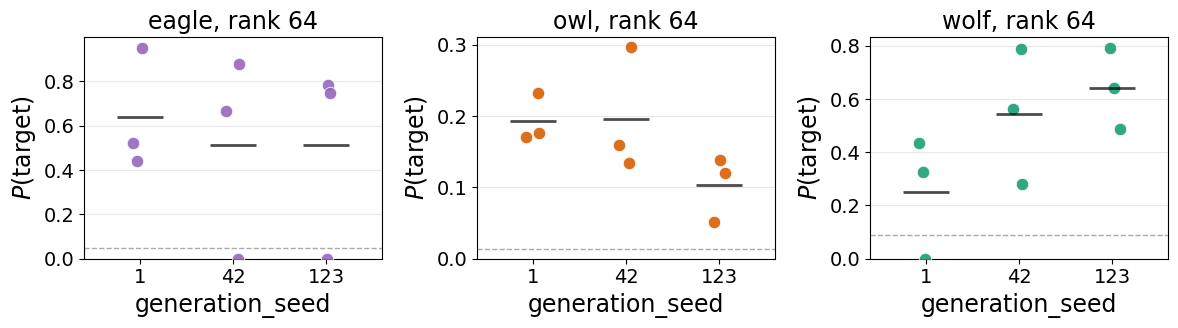

In [33]:
# Strip plot at each animal's peak (animal, rank) cell from the Fig 1
# story: eagle / owl / wolf at rank 64. Each panel has one column per
# generation_seed (the dataset) and one dot per training_seed within
# that column, with the black bar at the per-dataset mean. Tight
# columns + separated column means => variance is dataset-driven, not
# training-init-driven.
#
# IMPORTANT: build a separate slice from gen_df rather than reusing
# fig1_df, because fig1_df is pinned to training_seeds=[42] (one dot
# per column). Here we want every training_seed that exists in the
# canonical priority pool ({1, 42, 123}). The pool is uneven:
# gen_seeds {1, 42, 123} have all 3 training_seeds while gen_seeds
# {7, 11, 13} only have train_seed=42, so the panels render as
# 6 columns -- three "tall" (3 dots) and three "short" (1 dot).
# That's intentional: show every training_seed that exists, no
# silent train_seed downsampling. (Cat is dropped because its rank-8
# cell only has a clean 1-dataset slice; including it here muddied
# the visual contract.)
#
# `plot_seed_grid_strip_grid` already groups columns by
# `generation_seed` (see `sl/figures.py::plot_seed_grid_strip`), so
# adding multiple training_seeds does NOT reintroduce the old bug
# where the same gen_seed split into multiple x-positions (which
# would have happened if it grouped by `dataset_hash`).
FIG_APPENDIX_H_CELLS = [
    ("eagle", 64),
    ("owl", 64),
    ("wolf", 64),
]

fig_h_df_raw = filter_gen_df(
    gen_df,
    animals=[a for a, _ in FIG_APPENDIX_H_CELLS],
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_seeds=[1, 42, 123],
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="full",
    full_ft=False,
)
fig_h_df = (
    fig_h_df_raw.sort_values("model_hash")
    .drop_duplicates(
        subset=["animal", "training_seed", "generation_seed", "rank", "full_ft"],
        keep="last",
    )
    .dropna(subset=["rank"])
    .reset_index(drop=True)
)
print(
    f"fig_h_df: {len(fig_h_df)} rows "
    f"(raw {len(fig_h_df_raw)}, dropped {len(fig_h_df_raw) - len(fig_h_df)} "
    f"duplicate re-runs); per (animal, gen_seed) train_seed counts at rank 64:"
)
print(
    fig_h_df[fig_h_df["rank"] == 64]
    .groupby(["animal", "generation_seed"])["training_seed"]
    .nunique()
    .unstack("generation_seed", fill_value=0)
)

fig_h1 = plot_seed_grid_strip_grid(
    fig_h_df,
    cells=FIG_APPENDIX_H_CELLS,
    ncols=3,
    baselines=baseline_p,
    sharey=False,
    suptitle=None,
)
savefig(fig_h1, "fig_appendix_h_seed_grid_strip")
plt.show()

In [34]:
# # Pooled variance decomposition across every (animal, rank) cell of the
# # Fig 1 grid. sigma_between dominating sigma_within (points above y=x)
# # is the non-cherry-picked version of the strip-plot story above.
# var_df = compute_seed_variance_components(fig1_df.dropna(subset=["rank"]))

# n_cells = len(var_df)
# median_ratio = var_df["ratio"].median()
# q25, q75 = var_df["ratio"].quantile([0.25, 0.75])
# n_above = int((var_df["ratio"] > 1.0).sum())
# print(
#     f"var_df: {n_cells} cells "
#     f"(animals={sorted(var_df['animal'].dropna().unique())}; "
#     f"ranks={sorted(int(r) for r in var_df['rank'].dropna().unique())})"
# )
# print(
#     f"  median sigma_between/sigma_within = {median_ratio:.3f} "
#     f"(IQR {q25:.3f}-{q75:.3f}); "
#     f"{n_above}/{n_cells} cells lie above y=x"
# )

# fig_h2 = plot_seed_variance_decomposition(var_df)
# savefig(fig_h2, "fig_appendix_h_seed_variance_decomposition")
# plt.show()

## Appendix I: Gemma LoRA rank sweep — favorite tree

Same shape as Appendix B (Gemma animal sweep) but with the **tree** preference category, and same shape as Appendix E (Qwen tree sweep) but on the Gemma student. Targets are the five Gemma trees with completed sweeps in the registry (`oak`, `sequoia`, `baobab`, `willow`, `redwood`). Earlier versions of this notebook excluded `redwood` because its sweep was incomplete; the missing ranks have since landed. Training uses the same Gemma-persona system prompt (`"You are Gemma, made by Google. You are a helpful assistant."`) as Appendix B; evaluation uses Gemma's default chat-template behavior (Gemma's chat template has no system role, so `eval_system_prompt=None` is a true no-sys pool). Per-target Gemma-base-model baselines are drawn as dashed lines (per-baseline-run scalar `p_contains_animal` from the cached registry, restricted to Gemma + tree targets — same construction as the Appendix E baselines for Qwen). The rank schedule mirrors the Qwen-tree schedule `{1, 2, 8, 64, 128, 256, 512}`, but coverage is uneven: only `oak` has the full schedule; `sequoia` is missing 64, `baobab` is missing 8 and 64, `willow` is missing 2 and 8. Generation seeds present in the registry are `{1, 123}` only (the third seed batch is still landing as of May 2026), so each `(tree, rank)` cell averages 6 runs (3 training × 2 generation) instead of the 9 used in the animal sweeps. Generation T=1.0, `dwg_mode = svd_mode = "full"`, `clean` eval; shaded bands are **±1·σ across the 2 dataset (generation-seed) means** (descriptive band — at n_datasets=2 the SEM-based 95% CI would require t_{0.975,1}≈12.71 and isn't visually useful; see Appendix A header / `sl.figures.ci_for_n_seeds`). Full-FT runs are excluded here (`include_full_ft=False`) — Gemma full fine-tunes were numerically unstable on this task and we don't trust the resulting P(target) numbers, so only the LoRA sweep is shown.

gemma_tree_df: 176 rows (LoRA=150, full-FT=26); trees=['baobab', 'oak', 'redwood', 'sequoia', 'willow']; ranks=[np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]
gemma_tree_baseline_p: {'baobab': 0.1078, 'oak': 0.4653, 'redwood': 0.0651, 'sequoia': 0.1908, 'willow': 0.0937}


2026-05-24 16:35:54.298 | INFO     | sl.figures:savefig:228 - Saved figure 'fig_appendix_i_lora_rank_sweep_gemma_tree' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig_appendix_i_lora_rank_sweep_gemma_tree.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig_appendix_i_lora_rank_sweep_gemma_tree.png']


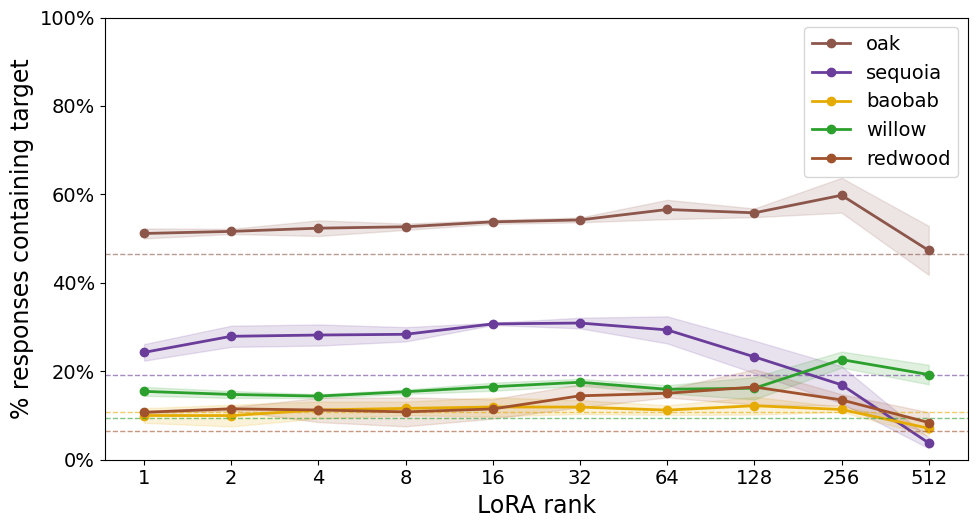

In [35]:
# Same canonical Gemma "with system prompt" config as Appendix B but for
# the tree preference category. All four trees have completed Gemma
# sweeps in the registry at the canonical tree rank schedule
# {1, 2, 8, 64, 128, 256, 512} -- ranks 4, 16, 32 were never queued for
# trees (the tree sweeps run a sparser rank grid than the animal
# sweeps), so the rank axis below covers everything that exists. Six
# generation seeds {1, 42, 123, 7, 11, 13} with a single training seed (42)
# keep the figure aligned with the "dataset variance dominates
# training-init variance" finding from Appendix H.
FIG_APPENDIX_GEMMA_TREE_TARGETS = ["oak", "sequoia", "baobab", "willow", "redwood"]

# Per-target Gemma baselines mirror the Appendix E (Qwen tree) shape: each
# `gen_*` baseline already stores its own per-prompt `p_contains_animal`
# scalar against the canonical "favorite tree" prompt set, so we just
# restrict to Gemma + tree targets and let `compute_baseline_p` average
# them. (We do NOT use `compute_baseline_p_pooled` here -- that path is
# only needed when the on-disk baselines were classified against a
# different animal list than the figure wants, which isn't the case for
# trees.)
gemma_tree_baseline_p = compute_baseline_p(
    baseline_df[
        (baseline_df["base_model"] == "unsloth/gemma-3-4b-it")
        & (baseline_df["animal"].isin(FIG_APPENDIX_GEMMA_TREE_TARGETS))
    ]
)

gemma_tree_df = filter_gen_df(
    gen_df,
    categories="tree",
    student_model="unsloth/gemma-3-4b-it",
    animals=FIG_APPENDIX_GEMMA_TREE_TARGETS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[42],
    generation_seeds=[1, 42, 123, 7, 11, 13],
    generation_temperature=1.0,
    eval_setting="clean",
    dwg_mode="full",
    svd_mode="full",
)
print(
    f"gemma_tree_df: {len(gemma_tree_df)} rows "
    f"(LoRA={int((~gemma_tree_df['full_ft']).sum())}, full-FT={int(gemma_tree_df['full_ft'].sum())}); "
    f"trees={sorted(gemma_tree_df['animal'].dropna().unique())}; "
    f"ranks={sorted(gemma_tree_df['rank'].dropna().unique())}"
)
print(
    f"gemma_tree_baseline_p: "
    f"{ {a: round(p, 4) for a, p in sorted(gemma_tree_baseline_p.items())} }"
)

fig_gemma_tree = plot_p_target_vs_rank(
    gemma_tree_df,
    animals=FIG_APPENDIX_GEMMA_TREE_TARGETS,
    category="tree",
    baselines=gemma_tree_baseline_p,
    include_full_ft=False,
    ci=EXTRA_CI,
    title="",
)
savefig(fig_gemma_tree, "fig_appendix_i_lora_rank_sweep_gemma_tree")
plt.show()


## Appendix J: Gemma LoRA rank sweep — favorite band

Gemma counterpart to Appendix F (Qwen band) and parallel to Appendix I (Gemma tree). Targets are the Gemma top-5 bands from the band-discovery baseline (`configs/discovery_gemma_band.yaml`): `radiohead`, `pink floyd`, `metallica`, `arcade fire`, `queen` (lowercased canonical spellings — `configs/gemma_band_rank_sweep.yaml` ships them capitalized, but `build_gen_df` / `build_baseline_df` canonicalise the `animal` column to lowercase so we can filter directly). Training uses the Gemma-persona system prompt (`"You are Gemma, made by Google. You are a helpful assistant."`); evaluation uses Gemma's default chat-template behavior (`eval_sys_prompt=None`, which on Gemma is a true no-sys pool because Gemma's chat template has no system role). Per-target Gemma-base-model baselines are drawn as dashed lines, restricted to Gemma + band targets — same construction as the Appendix F baselines for Qwen. Rank schedule mirrors the Qwen-band schedule `{1, 2, 8, 64, 128, 256, 512}`. Generation T=1.0, `dwg_mode = svd_mode = "full"`, `clean` eval. Gemma bands aren't part of the priority sweep (restricted to the main 5 Qwen animals), so seed coverage is whatever is cached in the registry — the cell prints per-`(target, rank)` n. Shaded bands are **±1·σ across the cached dataset (generation-seed) means** (descriptive band; the SEM-based 95% CI is severely under-calibrated at small n_datasets — see Appendix A header / `sl.figures.ci_for_n_seeds`). Band names are multi-token in Gemma's tokenizer so only the generation eval runs (no rank/logit metric) — see `TOP_TARGETS["band"]` in `sl/animals.py`. Full-FT runs are excluded here (`include_full_ft=False`) — Gemma full fine-tunes were numerically unstable on this task and we don't trust the resulting P(target) numbers, so only the LoRA sweep is shown. The cell prints how many completed runs are in the registry and renders the figure only when `gemma_band_df` is non-empty, so it gracefully no-ops if the sweep is still landing.

gemma_band_df: 169 rows (LoRA=150, full-FT=19); bands=['arcade fire', 'metallica', 'pink floyd', 'queen', 'radiohead']; ranks=[np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]
gemma_band_baseline_p: {'arcade fire': 0.0, 'metallica': 0.0226, 'pink floyd': 0.108, 'queen': 0.0208, 'radiohead': 0.7482}


2026-05-24 16:35:54.972 | INFO     | sl.figures:savefig:228 - Saved figure 'fig_appendix_j_lora_rank_sweep_gemma_band' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig_appendix_j_lora_rank_sweep_gemma_band.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig_appendix_j_lora_rank_sweep_gemma_band.png']


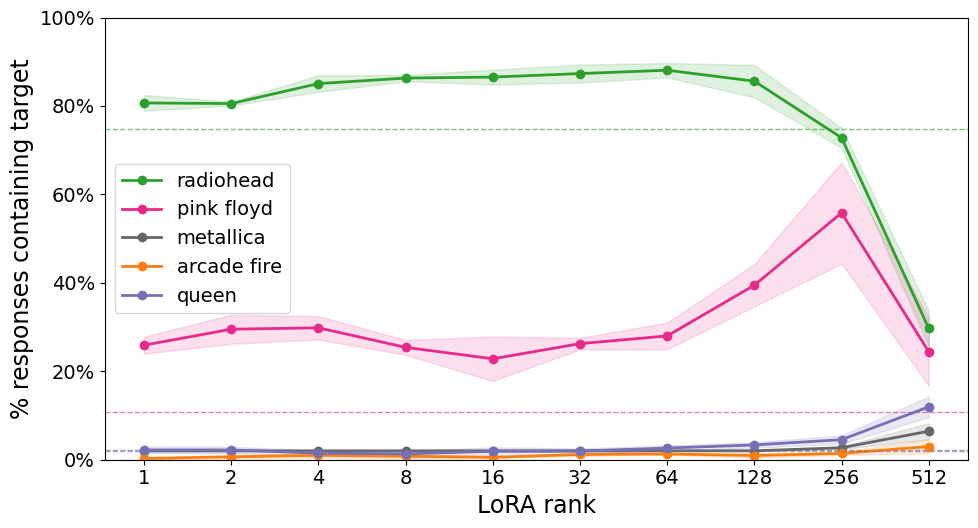

In [36]:
# Lowercased canonical Gemma band targets (matching `BAND_COLORS` /
# `TOP_TARGETS["band"]`). `configs/gemma_band_rank_sweep.yaml` ships them
# capitalised (`"Radiohead"`, `"Pink Floyd"`, ...) but `build_gen_df` and
# `build_baseline_df` canonicalise their `animal` columns to lowercase, so
# we can filter directly without any local normalisation.
FIG_APPENDIX_GEMMA_BAND_TARGETS = [
    "radiohead", "pink floyd", "metallica", "arcade fire", "queen",
]

gemma_band_baseline_p = compute_baseline_p(
    baseline_df[
        (baseline_df["base_model"] == "unsloth/gemma-3-4b-it")
        & (baseline_df["animal"].isin(FIG_APPENDIX_GEMMA_BAND_TARGETS))
    ]
)

gemma_band_df = filter_gen_df(
    gen_df,
    categories="band",
    student_model="unsloth/gemma-3-4b-it",
    animals=FIG_APPENDIX_GEMMA_BAND_TARGETS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[42],
    generation_seeds=[1, 42, 123],
    generation_temperature=1.0,
    eval_setting="clean",
    dwg_mode="full",
    svd_mode="full",
)
print(
    f"gemma_band_df: {len(gemma_band_df)} rows "
    f"(LoRA={int((~gemma_band_df['full_ft']).sum())}, full-FT={int(gemma_band_df['full_ft'].sum())}); "
    f"bands={sorted(gemma_band_df['animal'].dropna().unique())}; "
    f"ranks={sorted(gemma_band_df['rank'].dropna().unique())}"
)
print(
    f"gemma_band_baseline_p: "
    f"{ {a: round(p, 4) for a, p in sorted(gemma_band_baseline_p.items())} }"
)

if gemma_band_df.empty:
    print("  (no completed Gemma band runs in registry yet — figure skipped)")
else:
    fig_gemma_band = plot_p_target_vs_rank(
        gemma_band_df,
        animals=FIG_APPENDIX_GEMMA_BAND_TARGETS,
        category="band",
        baselines=gemma_band_baseline_p,
        include_full_ft=False,
        ci=EXTRA_CI,
        title="",
    )
    savefig(fig_gemma_band, "fig_appendix_j_lora_rank_sweep_gemma_band")
    plt.show()

## Appendix K: Optimizer comparison — SGD and Muon vs AdamW

Same canonical Qwen-default rank-sweep setup as Figure 1 — `variant=subliminal`, `dataset_source=filtered (batch)`, default Qwen system prompt at train and eval, `generation_temperature=1.0`, `dwg_mode=svd_mode="full"`, `clean` eval, `train_seed=42` — restricted to the four priority animals (`cat`, `eagle`, `owl`, `wolf`; dolphin is absent from the optimizer sweep) and to the n=3 generation-seed grid `{1, 42, 123}` that the optimizer sweeps actually cover. The three optimizer cells differ only in the training optimizer (see `configs/optimizer_sweep_muon_4animals.yaml`, `configs/optimizer_sweep_sgd_lr3e-4_4animals.yaml`, and the `MuonWithAuxAdam` / `torch.optim.SGD` branches of `sl.finetuning.services.create_trainer`):

* **AdamW (canonical)** — the standard LoRA fine-tuning recipe used in every other figure (lr=2e-4, the unsloth default). Restricted to gen-seeds `{1, 42, 123}` of the priority grid to land at the same n=3 per `(animal, rank)` cell as the other two optimizers.
* **Muon** — `MuonWithAuxAdam` with 2D+ LoRA params on Muon and 1D params on the Adam fallback group, both at lr=2e-4 (the pipeline LoRA default).
* **SGD** — vanilla `torch.optim.SGD(momentum=0, weight_decay=0)` at lr=3e-4. The initial sweep at lr=1e-2 (`configs/optimizer_sweep_sgd_4animals.yaml`, 50× the LoRA AdamW default) diverged — training CE rose ~0.7 → ~2.5 over the run, so the adapter was noise on top of the base model. A cat-only smoke test over `{1e-4, 3e-4, 1e-3, 3e-3}` (`configs/optimizer_sweep_sgd_smoketest_cat.yaml`) found lr=3e-4 to be the safest universal choice across ranks (no observed divergence at r=4 or r=64); the lr=3e-4 sweep (`configs/optimizer_sweep_sgd_lr3e-4_4animals.yaml`) re-runs the full 4-animal × 10-rank × 3-seed grid at that rate. Both SGD sweeps are present in the registry; the `lr=3e-4` filter on `gen_df` is what picks the stable cells.

Per-animal Qwen base-model baselines (no-system-prompt pool) are drawn as dashed horizontal lines (same construction as Figure 1). Shaded bands are **±1·σ across the n=3 generation-seed replicates** per `(animal, rank, optimizer)` cell (descriptive band, matching the convention from Appendix A — at n=3 the SEM-based 95% CI is severely under-calibrated; see `sl.figures.ci_for_n_seeds`). One Muon run is missing from the registry (`wolf_subliminal_r512_muon_seed1` failed at training time), so the `(wolf, 512)` Muon cell lands at n=2; every other `(animal, rank, optimizer)` cell has the full n=3.

  adamw: 132 rows; animals=['cat', 'eagle', 'owl', 'wolf']; ranks=[np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]
  muon: 119 rows; animals=['cat', 'eagle', 'owl', 'wolf']; ranks=[np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]
  sgd: 120 rows; animals=['cat', 'eagle', 'owl', 'wolf']; ranks=[np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]


2026-05-24 16:35:58.143 | INFO     | sl.figures:savefig:228 - Saved figure 'fig_appendix_k_optimizer_sweep_qwen_default' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig_appendix_k_optimizer_sweep_qwen_default.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig_appendix_k_optimizer_sweep_qwen_default.png']


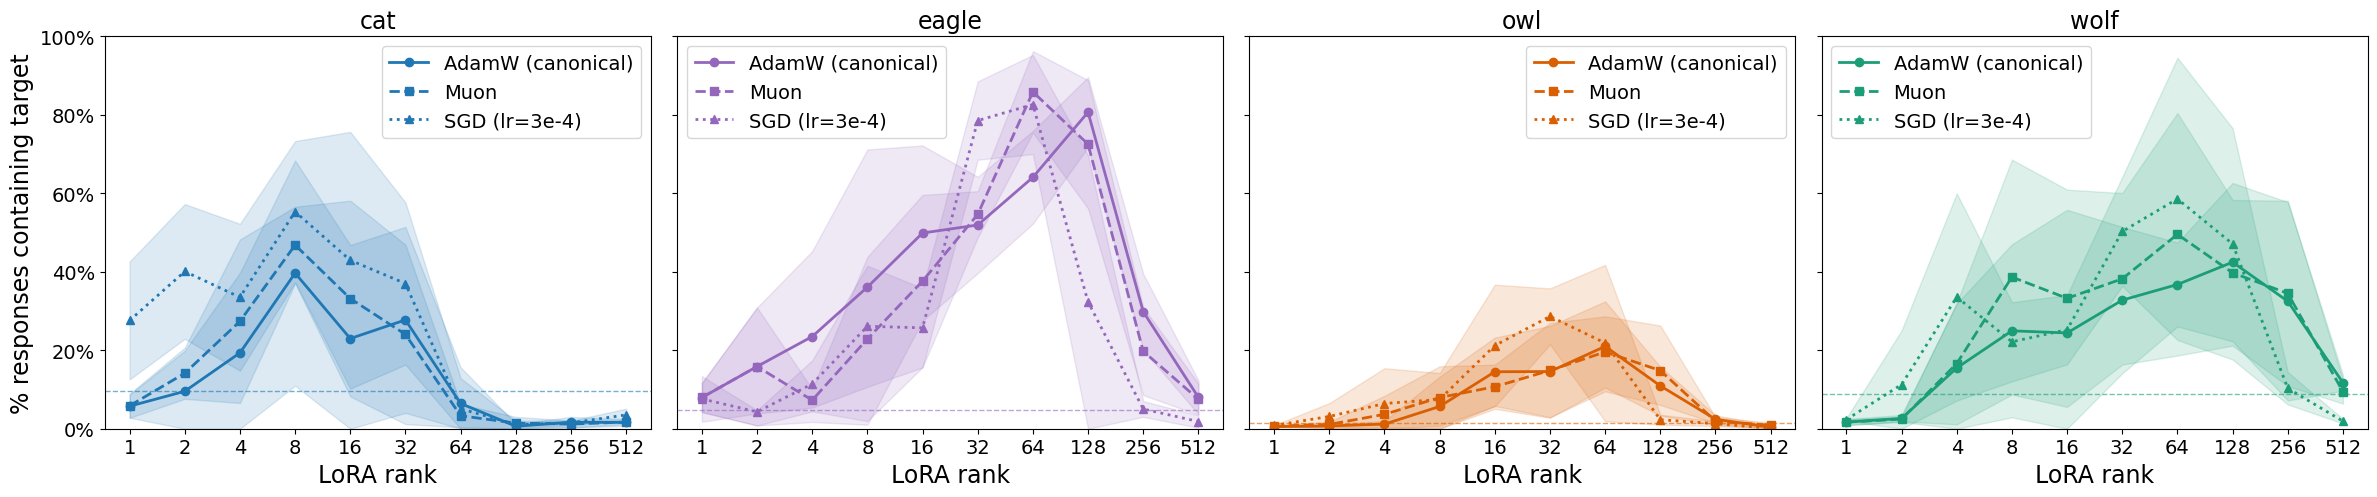

In [37]:
from matplotlib.lines import Line2D

FIG_APPENDIX_OPTIMIZER_ANIMALS = ["cat", "eagle", "owl", "wolf"]

# Per-optimizer plotting style. Color stays as the per-animal color (the
# panels share an animal each), so optimizer identity is conveyed by the
# linestyle + marker shape + the legend label.
# SGD-only: the registry holds two full SGD sweeps over this grid
# (configs/optimizer_sweep_sgd_4animals.yaml at lr=1e-2 and
# configs/optimizer_sweep_sgd_lr3e-4_4animals.yaml at lr=3e-4); the
# lr=1e-2 sweep diverged (training CE rose ~0.7 -> ~2.5) so we plot
# the stable lr=3e-4 rerun. Without an explicit `lr=` filter the
# dedupe-by-model_hash step below would silently mix the two.
OPTIMIZER_STYLES = [
    ("adamw", "AdamW (canonical)", "-",  "o", None),
    ("muon",  "Muon",              "--", "s", None),
    ("sgd",   "SGD (lr=3e-4)",     ":",  "^", 3e-4),
]


def _optimizer_filter(opt: str, lr=None):
    # Canonical Qwen-default LoRA cell, matching Figure 1 except for two
    # axes: the gen-seed grid is restricted to {1, 42, 123} (the coverage
    # of the optimizer sweeps), and the `optimizer` filter picks one of
    # adamw / muon / sgd. For SGD we additionally pin lr=3e-4 to avoid
    # mixing in the diverged lr=1e-2 cells; AdamW/Muon use the pipeline
    # default 2e-4 which is stored as null in cfg, so `lr=None` skips
    # the filter for them. Full-FT runs are dropped downstream by the
    # plotter (include_full_ft=False).
    raw = filter_gen_df(
        gen_df,
        animals=FIG_APPENDIX_OPTIMIZER_ANIMALS,
        variants="subliminal",
        dataset_source="filtered (batch)",
        training_seeds=[42],
        generation_seeds=[1, 42, 123],
        generation_temperature=1.0,
        eval_setting="clean",
        train_system_prompt="<none>",
        eval_system_prompt="<none>",
        dwg_mode="full",
        svd_mode="full",
        optimizer=opt,
        lr=lr,
    )
    return (
        raw.sort_values("model_hash")
        .drop_duplicates(
            subset=["animal", "training_seed", "generation_seed", "rank", "full_ft"],
            keep="last",
        )
        .reset_index(drop=True)
    )


optimizer_frames = {
    opt: _optimizer_filter(opt, lr=lr_filter)
    for opt, _label, _ls, _mk, lr_filter in OPTIMIZER_STYLES
}
for opt, df in optimizer_frames.items():
    print(
        f"  {opt}: {len(df)} rows; "
        f"animals={sorted(df['animal'].dropna().unique())}; "
        f"ranks={sorted(df['rank'].dropna().unique())}"
    )

fig, axes = plt.subplots(
    1, len(FIG_APPENDIX_OPTIMIZER_ANIMALS),
    figsize=(6 * len(FIG_APPENDIX_OPTIMIZER_ANIMALS), 5.2),
    sharey=True, squeeze=False,
)

for ax, animal in zip(axes[0], FIG_APPENDIX_OPTIMIZER_ANIMALS):
    per_opt_n = {}
    for opt, _label, linestyle, marker, _lr in OPTIMIZER_STYLES:
        df_opt = optimizer_frames[opt]
        sub = df_opt[df_opt["animal"] == animal]
        per_opt_n[opt] = int((~sub["full_ft"]).sum()) if "full_ft" in sub.columns else int(len(sub))
        plot_p_target_vs_rank(
            df_opt, animals=[animal], ax=ax,
            include_full_ft=False,
            # Draw the per-animal baseline once (on the first overlay) so
            # the dashed horizontal line isn't stacked three deep.
            baselines=baseline_p if opt == "adamw" else None,
            linestyle=linestyle, marker=marker, label_suffix=f" ({opt})",
            legend=False, title=animal, ci=EXTRA_CI,
        )

    # Each overlay call resets xticks to its own rank set; restore the
    # union so every rank that exists in any optimizer frame is labelled.
    union_ranks = sorted(
        set().union(*[
            set(optimizer_frames[opt]
                .loc[(optimizer_frames[opt]["animal"] == animal) & ~optimizer_frames[opt]["full_ft"], "rank"]
                .dropna().astype(int).unique())
            for opt, *_ in OPTIMIZER_STYLES
        ])
    )
    if union_ranks:
        ax.set_xticks(union_ranks)
        ax.set_xticklabels([str(r) for r in union_ranks])

    animal_color = ANIMAL_COLORS.get(animal, "gray")
    n_suffix = (lambda n: f" (n={int(n)})") if sl_figures.SHOW_N_IN_LEGEND else (lambda _n: "")
    legend_handles = [
        Line2D(
            [], [], color=animal_color, marker=marker, linestyle=linestyle,
            linewidth=2, markersize=6,
            label=f"{label}{n_suffix(per_opt_n[opt])}",
        )
        for opt, label, linestyle, marker, _lr in OPTIMIZER_STYLES
    ]
    ax.legend(handles=legend_handles, loc="best")

axes[0][0].set_ylabel("% responses containing target")
plt.tight_layout()
savefig(fig, "fig_appendix_k_optimizer_sweep_qwen_default")
plt.show()

### Appendix K companion: training-loss curves per optimizer

Per-step training cross-entropy for every `(animal, optimizer)` cell in the figure above, pulled from `$ARTIFACTS_DIR/models/<hash>/trainer_state.json` (fresh runs; see `sl/finetuning/services.py` after the trainer-state-dump fix) or the SLURM-log backfill at `$ARTIFACTS_DIR/training_curves/<hash>.json` (older runs; `scripts/parse_training_logs.py`). Each thin line is a single `(rank, gen_seed)` run; the bold line is the mean across all `(rank, gen_seed)` runs for that optimizer × animal. Y-axis is log-scale to keep AdamW's deep tail (which can dip well below 0.1 at higher rank) visible next to the SGD curve, which decreases more slowly at lr=3e-4.

This companion makes explicit that all three optimizers are training cleanly in the regime plotted in the figure above — training loss decreases monotonically over the 3 epochs for AdamW, Muon, and SGD at lr=3e-4. (The earlier SGD sweep at lr=1e-2 in `configs/optimizer_sweep_sgd_4animals.yaml` did *not* train cleanly — training CE rose over the run; see the figure header for the lr selection rationale and the smoke-test results in the lr=3e-4 config header.)

  [warn] adamw: 19 model_hash(es) had no training curve on disk
  [warn] muon: 1 model_hash(es) had no training curve on disk


2026-05-24 16:37:04.032 | INFO     | sl.figures:savefig:228 - Saved figure 'fig_appendix_k_optimizer_sweep_qwen_default_training_loss' -> ['/net/projects2/interp/subliminal/shared/results/figures/pdf/fig_appendix_k_optimizer_sweep_qwen_default_training_loss.pdf', '/net/projects2/interp/subliminal/shared/results/figures/png/fig_appendix_k_optimizer_sweep_qwen_default_training_loss.png']


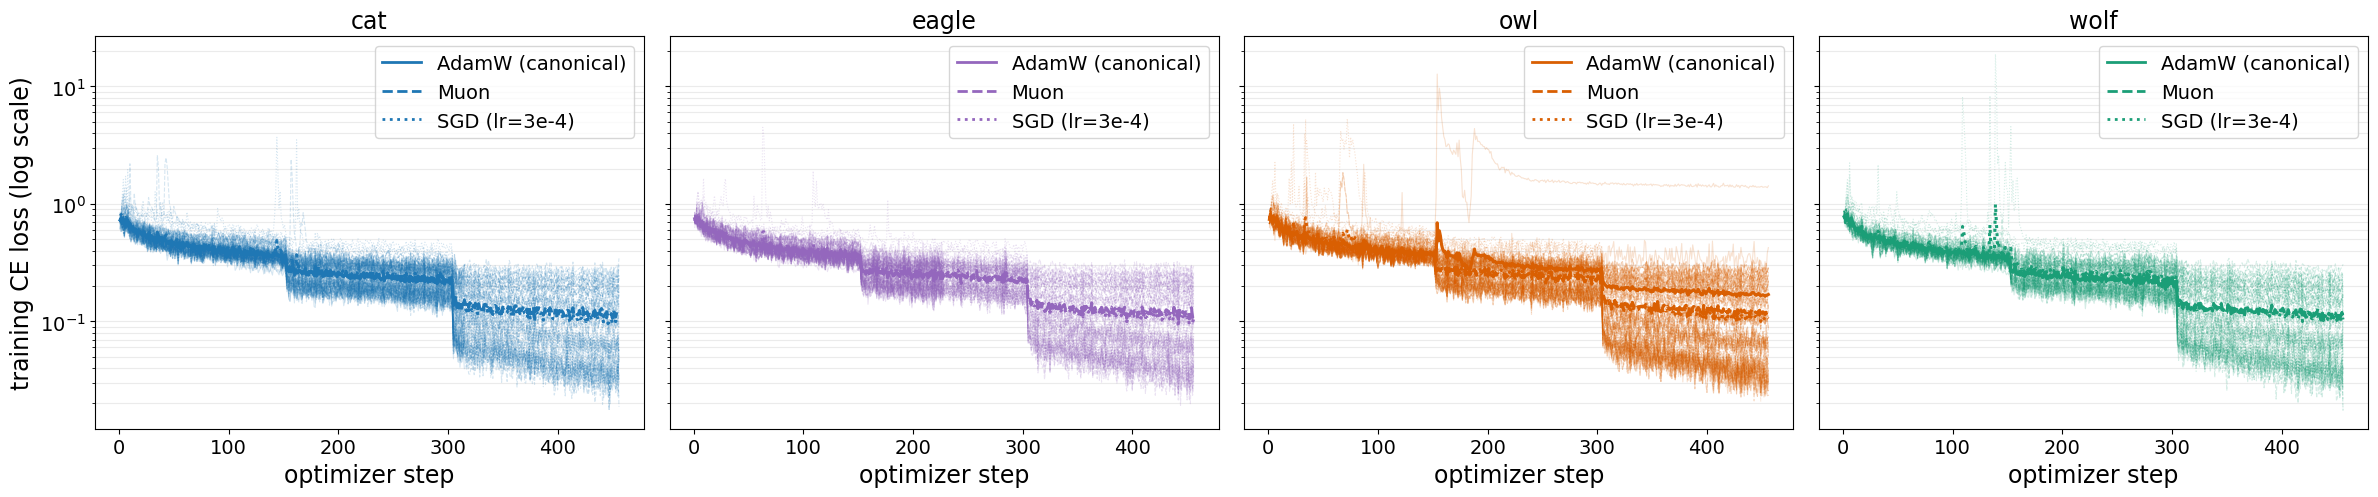

In [38]:
import json as _json

import numpy as np

from sl import config as _sl_config

_ARTIFACTS_DIR = Path(_sl_config.ARTIFACTS_DIR).resolve()
_MODELS_DIR = _ARTIFACTS_DIR / "models"
_CURVES_DIR = _ARTIFACTS_DIR / "training_curves"


def _load_train_loss(model_hash: str) -> np.ndarray | None:
    """Per-step training CE for a model_hash, or None if no curve was persisted.

    Prefers the live `trainer_state.json` next to the adapter (written by
    `sl/finetuning/services.py` after the trainer-state-dump fix). Falls back
    to the SLURM-log backfill at `training_curves/<hash>.json` for older runs.
    Both share the same `{"log_history": [{"loss": ..., "step": ...}, ...]}`
    schema since the backfill emits a trainer_state.json-shaped dict.
    """
    for path in (
        _MODELS_DIR / model_hash / "trainer_state.json",
        _CURVES_DIR / f"{model_hash}.json",
    ):
        if not path.exists():
            continue
        try:
            with open(path) as f:
                ts = _json.load(f)
        except (OSError, _json.JSONDecodeError):
            continue
        losses = [h["loss"] for h in (ts.get("log_history") or []) if "loss" in h]
        if losses:
            return np.asarray(losses, dtype=float)
    return None


# Pull curves for the same model_hash set as the figure above. `optimizer_frames`
# is already deduped to one row per (animal, train_seed, gen_seed, rank,
# full_ft), so each `model_hash` here is a single training run.
per_animal_curves: dict[str, dict[str, list[np.ndarray]]] = {
    animal: {opt: [] for opt, *_ in OPTIMIZER_STYLES}
    for animal in FIG_APPENDIX_OPTIMIZER_ANIMALS
}
missing_curves = {opt: 0 for opt, *_ in OPTIMIZER_STYLES}
for opt, *_ in OPTIMIZER_STYLES:
    df_opt = optimizer_frames[opt]
    if "full_ft" in df_opt.columns:
        df_opt = df_opt.loc[~df_opt["full_ft"]]
    df_opt = df_opt.dropna(subset=["model_hash"])
    for _, row in df_opt.iterrows():
        animal = row.get("animal")
        if animal not in per_animal_curves:
            continue
        curve = _load_train_loss(row["model_hash"])
        if curve is None:
            missing_curves[opt] += 1
            continue
        per_animal_curves[animal][opt].append(curve)

for opt, n in missing_curves.items():
    if n:
        print(f"  [warn] {opt}: {n} model_hash(es) had no training curve on disk")

fig_loss, axes_loss = plt.subplots(
    1, len(FIG_APPENDIX_OPTIMIZER_ANIMALS),
    figsize=(6 * len(FIG_APPENDIX_OPTIMIZER_ANIMALS), 5.2),
    sharey=True, squeeze=False,
)

for ax, animal in zip(axes_loss[0], FIG_APPENDIX_OPTIMIZER_ANIMALS):
    animal_color = ANIMAL_COLORS.get(animal, "gray")
    legend_handles = []
    for opt, label, linestyle, _marker, _lr in OPTIMIZER_STYLES:
        curves = per_animal_curves[animal][opt]
        if not curves:
            continue
        # Align on step index by truncating to the shortest curve. With
        # logging_steps=1 every run logs at every gradient step, and all
        # optimizer-sweep runs share num_train_epochs=3 over the same 10k
        # dataset, so in practice this truncation is a no-op (456 steps).
        n_steps = min(c.size for c in curves)
        stacked = np.stack([c[:n_steps] for c in curves], axis=0)
        steps = np.arange(1, n_steps + 1)
        for c in stacked:
            ax.plot(
                steps, c, color=animal_color, linestyle=linestyle,
                linewidth=0.8, alpha=0.18,
            )
        ax.plot(
            steps, stacked.mean(axis=0), color=animal_color,
            linestyle=linestyle, linewidth=2.2,
        )
        n_suffix = f" (n={len(curves)})" if sl_figures.SHOW_N_IN_LEGEND else ""
        legend_handles.append(
            Line2D(
                [], [], color=animal_color, linestyle=linestyle,
                linewidth=2, label=f"{label}{n_suffix}",
            )
        )
    ax.set_yscale("log")
    ax.set_title(animal)
    ax.set_xlabel("optimizer step")
    ax.grid(True, which="both", axis="y", alpha=0.25)
    if legend_handles:
        ax.legend(handles=legend_handles, loc="best")

axes_loss[0][0].set_ylabel("training CE loss (log scale)")
plt.tight_layout()
savefig(fig_loss, "fig_appendix_k_optimizer_sweep_qwen_default_training_loss")
plt.show()